In [1]:
import pandas as pd

In [2]:
ratings = pd.read_csv('/Users/sebastian/University/Master/third term/sem-proj/kg-token/data/ml-100k/u.data', header=None, sep='\t', encoding='latin1')
ratings.columns = ['user_id', 'movie_id', 'rating', 'timestamp']

In [3]:
ratings

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596
...,...,...,...,...
99995,880,476,3,880175444
99996,716,204,5,879795543
99997,276,1090,1,874795795
99998,13,225,2,882399156


In [4]:
ratings['movie_id'] -= 1

In [5]:
ratings['user_id'] -= 1

In [6]:
ratings

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596
...,...,...,...,...
99995,879,475,3,880175444
99996,715,203,5,879795543
99997,275,1089,1,874795795
99998,12,224,2,882399156


In [7]:
aggregated_df = ratings.groupby('user_id').agg(
    movies_rated=('movie_id', list),
    ratings=('rating', list)
).reset_index()

aggregated_df

,user_id,movies_rated,ratings
0,0,"[60, 188, 32, 159, 19, 201, 170, 264, 154, 116...","[4, 3, 4, 4, 4, 5, 5, 4, 2, 3, 4, 4, 5, 5, 4, ..."
1,1,"[291, 250, 49, 313, 296, 289, 311, 280, 12, 27...","[4, 5, 5, 1, 4, 3, 3, 3, 4, 3, 4, 3, 3, 4, 5, ..."
2,2,"[334, 244, 336, 342, 322, 330, 293, 331, 327, ...","[1, 1, 1, 3, 2, 4, 2, 1, 5, 3, 3, 1, 4, 2, 3, ..."
3,3,"[263, 302, 360, 356, 259, 355, 293, 287, 49, 3...","[3, 5, 5, 4, 4, 3, 5, 4, 5, 5, 4, 5, 3, 5, 3, ..."
4,4,"[1, 16, 438, 224, 109, 453, 423, 0, 362, 97, 1...","[3, 4, 1, 2, 1, 1, 1, 4, 3, 3, 3, 4, 5, 2, 4, ..."
...,...,...,...
938,938,"[930, 105, 257, 1053, 688, 475, 408, 120, 1189...","[2, 3, 4, 4, 5, 5, 4, 5, 5, 4, 5, 4, 5, 3, 2, ..."
939,939,"[192, 567, 13, 204, 271, 654, 314, 65, 872, 28...","[3, 3, 3, 3, 4, 4, 4, 4, 3, 3, 5, 5, 4, 3, 5, ..."
940,940,"[146, 123, 116, 180, 992, 257, 6, 474, 256, 14...","[4, 5, 5, 5, 4, 4, 4, 4, 4, 4, 4, 2, 2, 3, 5, ..."
941,941,"[116, 199, 603, 422, 260, 426, 486, 322, 614, ...","[4, 4, 4, 5, 4, 5, 4, 3, 3, 4, 5, 3, 3, 2, 4, ..."


In [9]:
def separate_movies_ratings(row):
    movies_1 = [movie for movie, rating in zip(row['movies_rated'], row['ratings']) if rating == 1]
    movies_2 = [movie for movie, rating in zip(row['movies_rated'], row['ratings']) if rating == 2]
    movies_3 = [movie for movie, rating in zip(row['movies_rated'], row['ratings']) if rating == 3]
    movies_4 = [movie for movie, rating in zip(row['movies_rated'], row['ratings']) if rating == 4]
    movies_5 = [movie for movie, rating in zip(row['movies_rated'], row['ratings']) if rating == 5]
    return pd.Series([movies_1, movies_2, movies_3, movies_4, movies_5])

aggregated_df[['movies_rated_1', 'movies_rated_2', 'movies_rated_3', 'movies_rated_4', 'movies_rated_5',]] = aggregated_df.apply(separate_movies_ratings, axis=1)

aggregated_df = aggregated_df.drop(columns=['movies_rated', 'ratings'])

aggregated_df

,user_id,movies_rated_1,movies_rated_2,movies_rated_3,movies_rated_4,movies_rated_5
0,0,"[265, 73, 259, 139, 119, 103, 77, 142, 258, 11...","[154, 26, 144, 224, 212, 232, 147, 263, 251, 2...","[188, 116, 16, 91, 30, 69, 158, 271, 124, 214,...","[60, 32, 159, 19, 264, 46, 221, 226, 89, 120, ...","[201, 170, 252, 112, 63, 227, 113, 220, 59, 17..."
1,1,"[313, 314, 293, 308]",[9],"[289, 311, 280, 279, 307, 306, 297, 18, 257, 3...","[291, 296, 12, 302, 256, 300, 278, 298, 276, 2...","[250, 49, 315, 312, 241, 282, 310, 99, 126, 28..."
2,2,"[334, 244, 336, 331, 340, 324, 335, 352]","[322, 293, 299, 323, 329, 271, 263, 287, 257, ...","[342, 333, 349, 344, 298, 350, 306, 353, 348, ...","[330, 317, 347, 326, 259, 341, 328, 180, 343]","[327, 320, 319, 346, 339, 345]"
3,3,[],[357],"[263, 355, 327, 209]","[356, 259, 287, 270, 10]","[302, 360, 293, 49, 353, 299, 257, 328, 326, 3..."
4,4,"[438, 109, 453, 423, 376, 452, 240, 388, 410, ...","[224, 375, 230, 393, 166, 233, 387, 396, 443, ...","[1, 362, 97, 101, 406, 383, 444, 425, 402, 153...","[16, 0, 210, 61, 23, 422, 266, 221, 172, 421, ...","[381, 435, 41, 152, 108, 99, 88, 432, 427, 208..."
...,...,...,...,...,...,...
938,938,[],"[930, 889, 265, 679]","[105, 817, 933, 423, 253, 251]","[257, 1053, 408, 992, 1022, 596, 410, 716, 840...","[688, 475, 120, 1189, 221, 325, 1050, 1276, 21..."
939,939,"[354, 609, 1400, 357, 263]","[152, 318, 548, 3, 342, 791, 115, 68, 163, 270...","[192, 567, 13, 204, 872, 288, 180, 473, 750, 7...","[271, 654, 314, 65, 171, 146, 169, 173, 316, 8...","[95, 193, 7, 55, 94, 854, 426, 299, 481, 708, ..."
940,940,[],"[221, 357]","[762, 272]","[146, 992, 257, 6, 474, 256, 14, 454, 299, 293...","[123, 116, 180, 297, 407, 918, 0]"
941,941,[],[268],"[322, 614, 538, 312, 361, 891, 321, 182, 327, ...","[116, 199, 603, 260, 486, 583, 510, 968, 478, ...","[422, 426, 346, 303, 192, 30, 130, 499, 171, 6..."


In [10]:
import torch

In [12]:
%cd ..

/Users/sebastian/University/Master/third term/sem-proj/kg-token


/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [14]:
llm_embedding = torch.load('user_embeds.pt')
llm_embedding.shape

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_85254/1158438221.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  llm_embedding = torch.load('user_embeds.pt')


torch.Size([943, 512])

In [15]:
movie_embedding = torch.load('movie_embeds.pt')
movie_embedding.shape

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_85254/3150904372.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  movie_embedding = torch.load('movie_embeds.pt

torch.Size([1682, 512])

In [20]:
!pip install umap-learn

In [24]:
from umap import UMAP

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP

def visualize_user_movie_embeddings(user_id, user_embedding, movie_embedding, dataframe):
    user_embed = user_embedding[user_id].numpy()

    rated_movies = {
        f"rated_{i}": np.array([int(movie) for movie in dataframe.loc[user_id, f"movies_rated_{i}"]])
        for i in range(1, 6)
    }

    embeddings = [user_embed]  # Start with the user embedding
    labels = ["user"]  # Label for the user embedding

    for rating, movies in rated_movies.items():
        if len(movies) > 0:
            movie_embeds = movie_embedding[movies].numpy()
            embeddings.append(movie_embeds)
            labels.extend([rating] * len(movies))

    embeddings = np.vstack(embeddings)


    transformed_embeddings = UMAP(n_components=2, random_state=42).fit_transform(embeddings)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    unique_labels = set(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_color_map = dict(zip(unique_labels, colors))

    for label in unique_labels:
        indices = [i for i, l in enumerate(labels) if l == label]
        axes[0].scatter(
            transformed_embeddings[indices, 0],
            transformed_embeddings[indices, 1],
            label=label,
            color=label_color_map.get(label, "black"),  
        )

    axes[0].set_title(f"UMAP Visualization for User {user_id} (Original Labels)")
    axes[0].set_xlabel("UMAP Component 1")
    axes[0].set_ylabel("UMAP Component 2")
    axes[0].legend()
    axes[0].grid(True)

    simplified_labels = [
        "user" if label == "user" else ("likes" if int(label.split("_")[1]) > 3 else "doesn't like")
        for label in labels
    ]

    unique_simplified_labels = set(simplified_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_simplified_labels)))
    label_color_map = dict(zip(unique_simplified_labels, colors))

    for label in unique_simplified_labels:
        indices = [i for i, l in enumerate(simplified_labels) if l == label]
        axes[1].scatter(
            transformed_embeddings[indices, 0],
            transformed_embeddings[indices, 1],
            label=label,
            color=label_color_map.get(label, "black"),
        )

    axes[1].set_title(f"UMAP Visualization for User {user_id} (Simplified Labels)")
    axes[1].set_xlabel("UMAP Component 1")
    axes[1].set_ylabel("UMAP Component 2")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


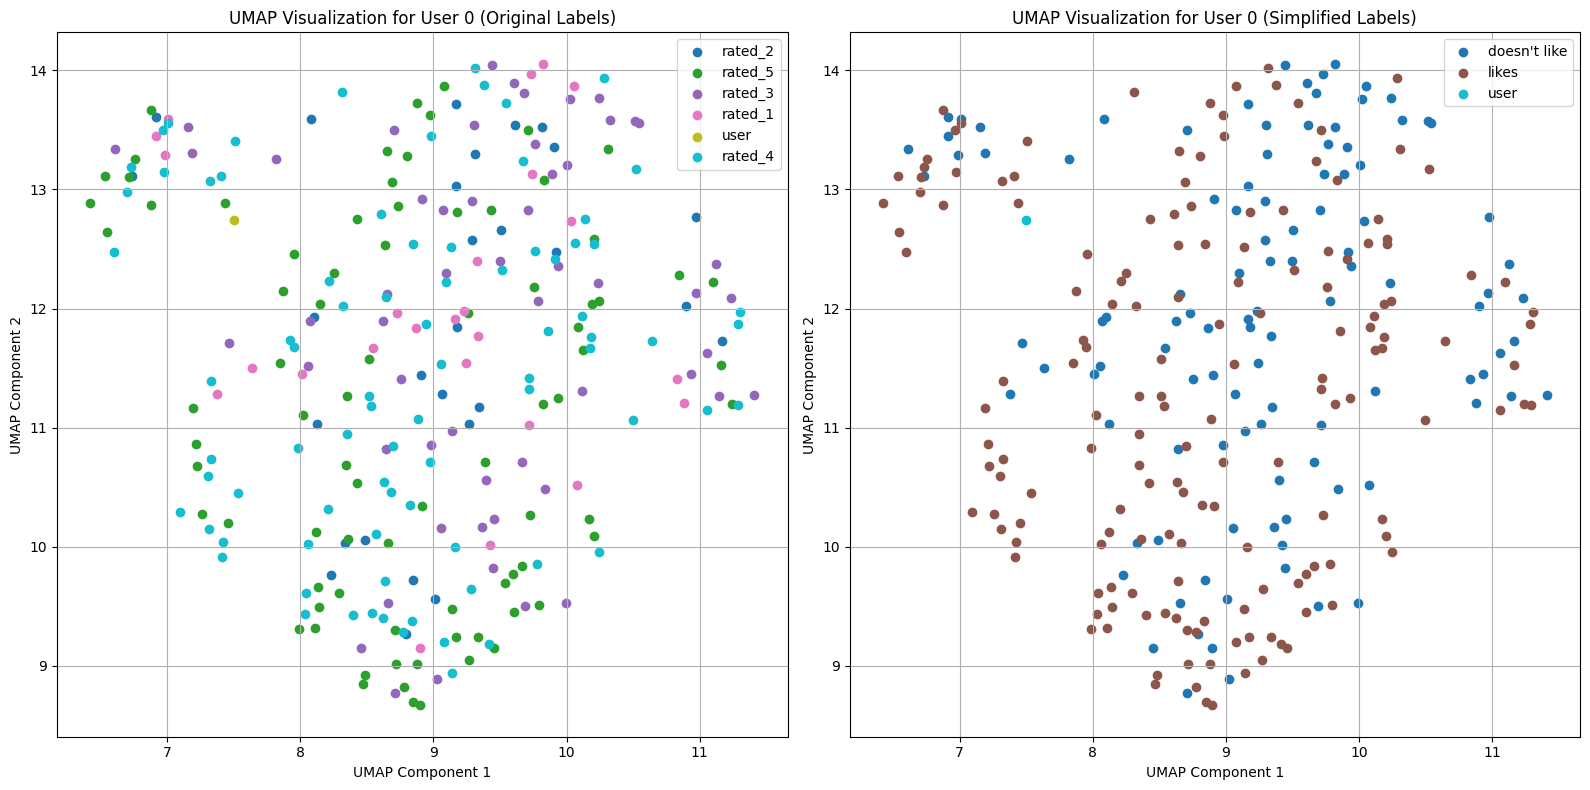

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


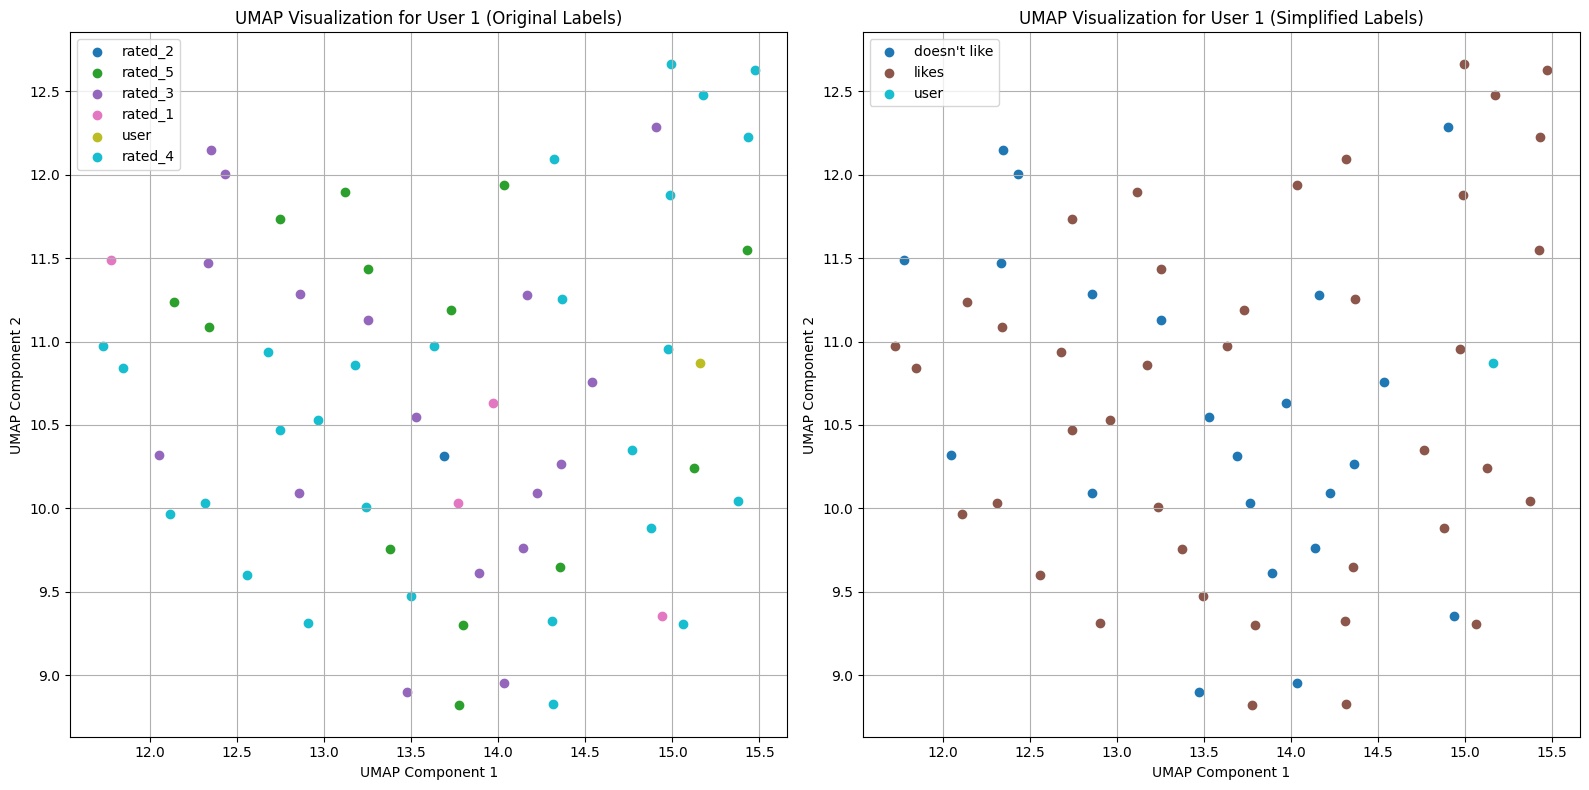

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


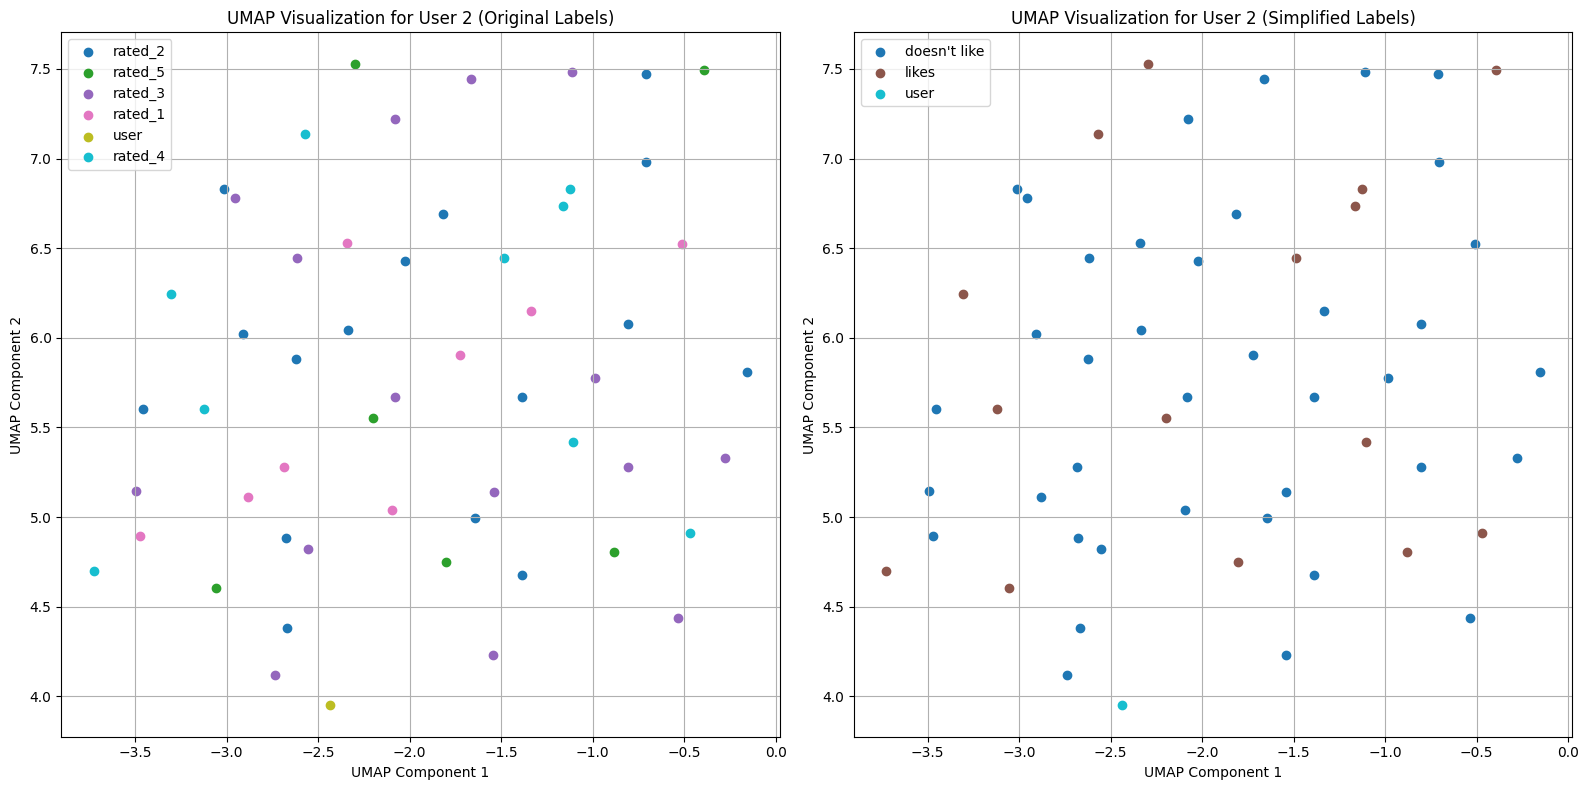

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


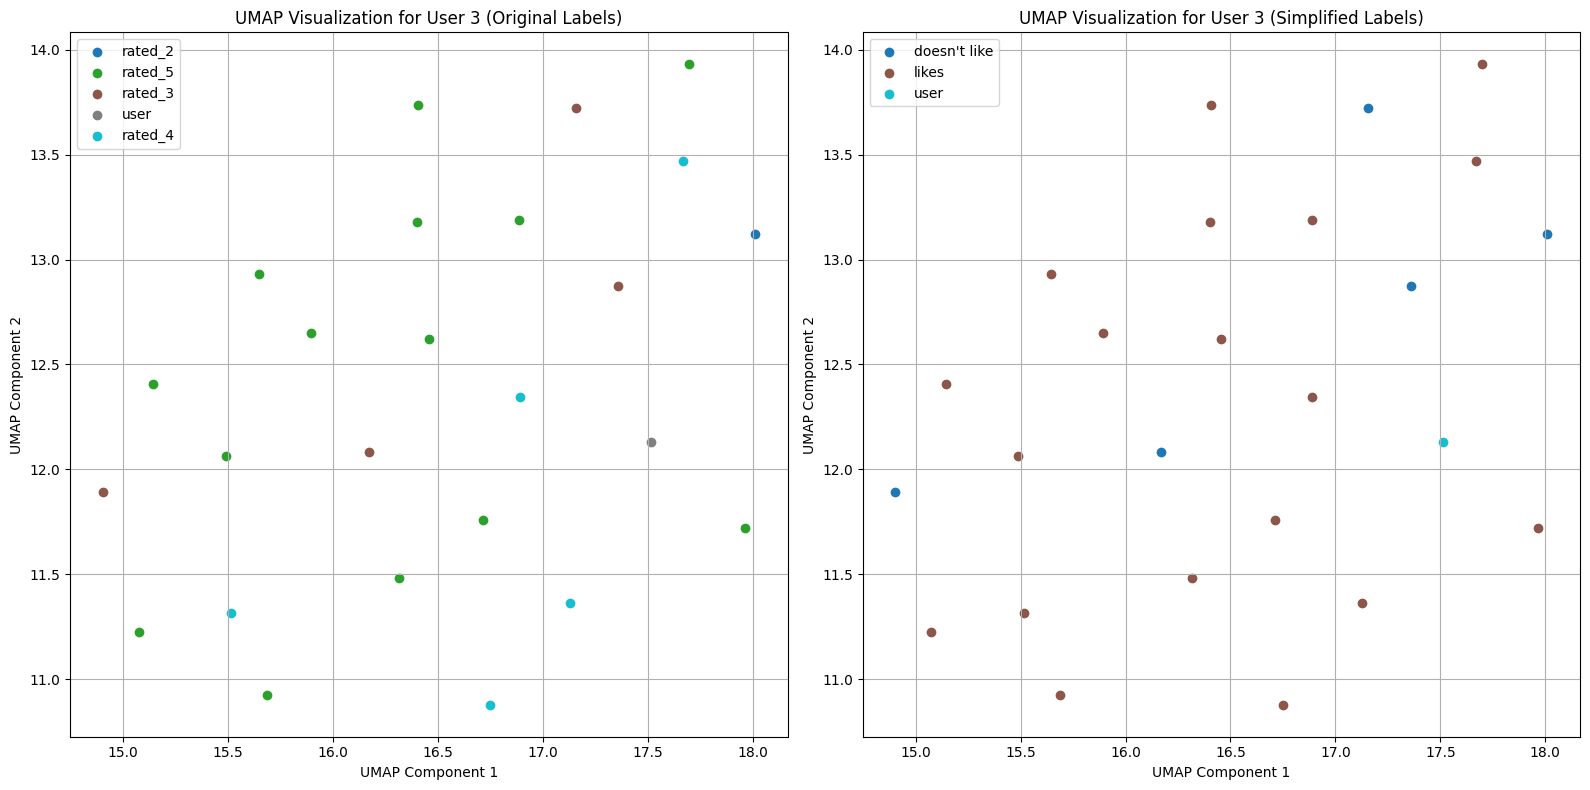

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


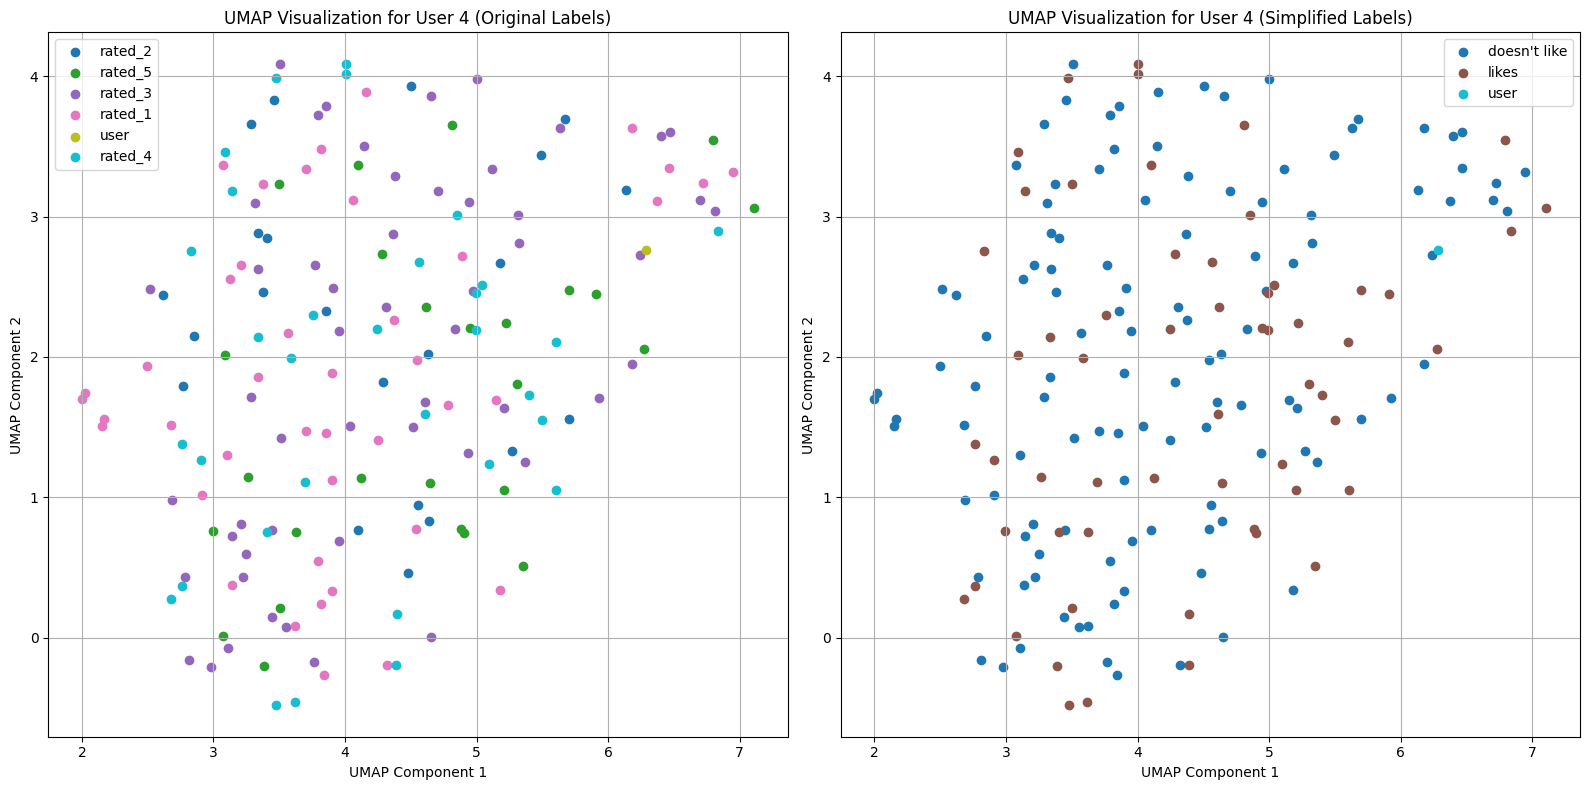

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


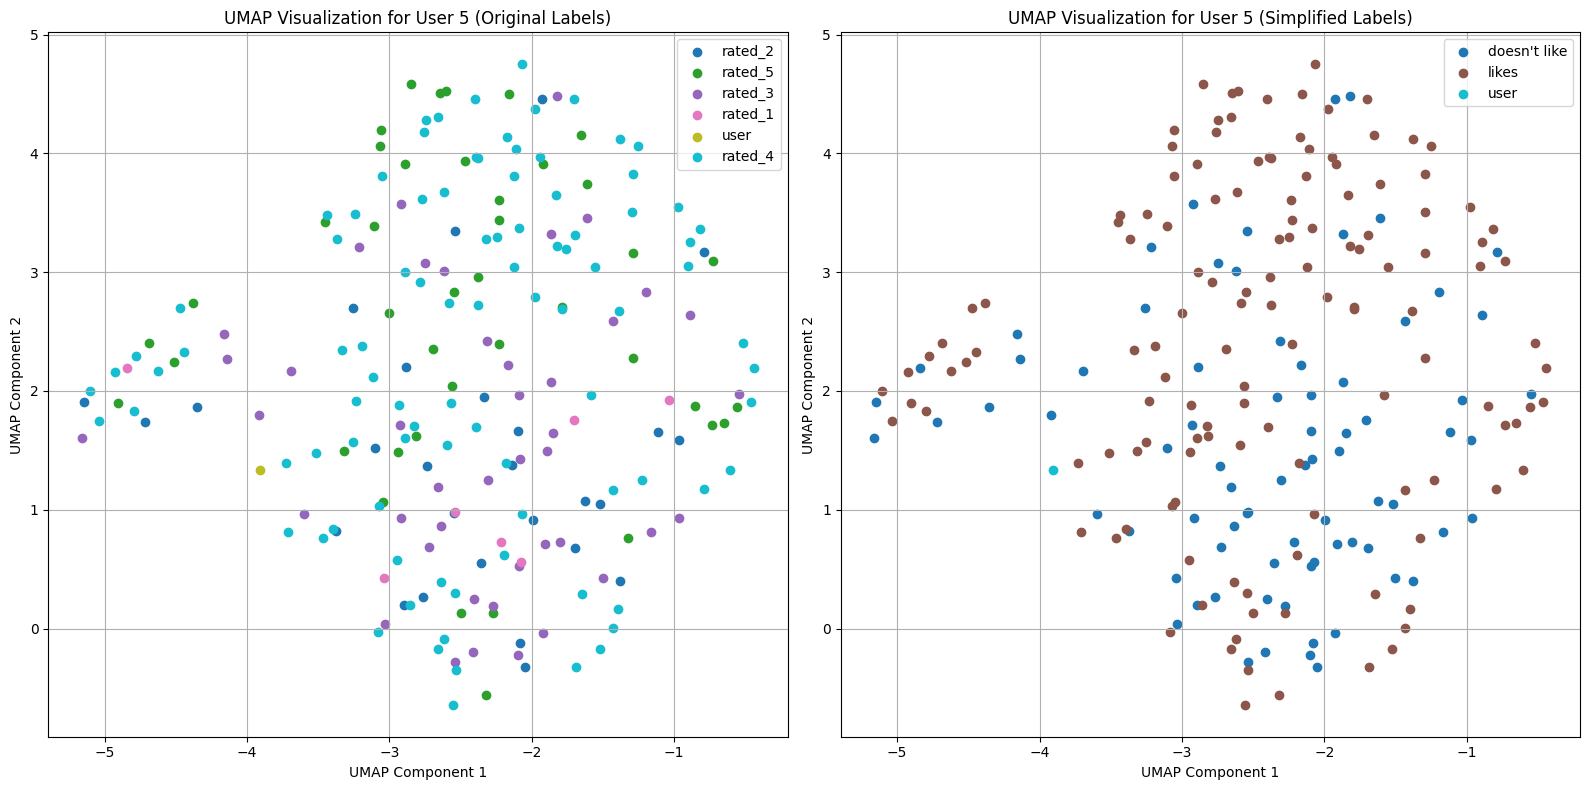

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


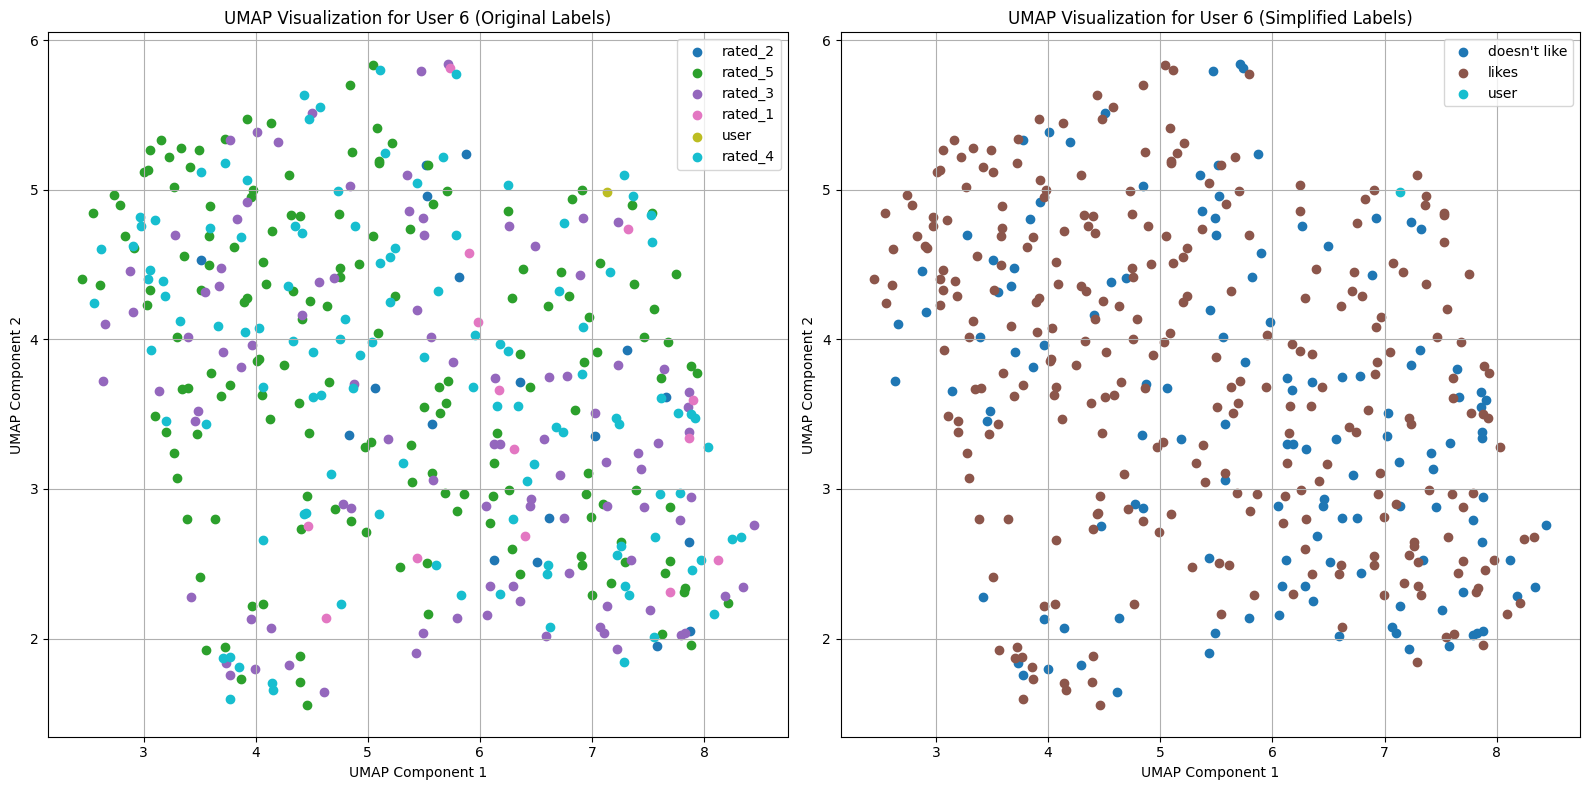

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


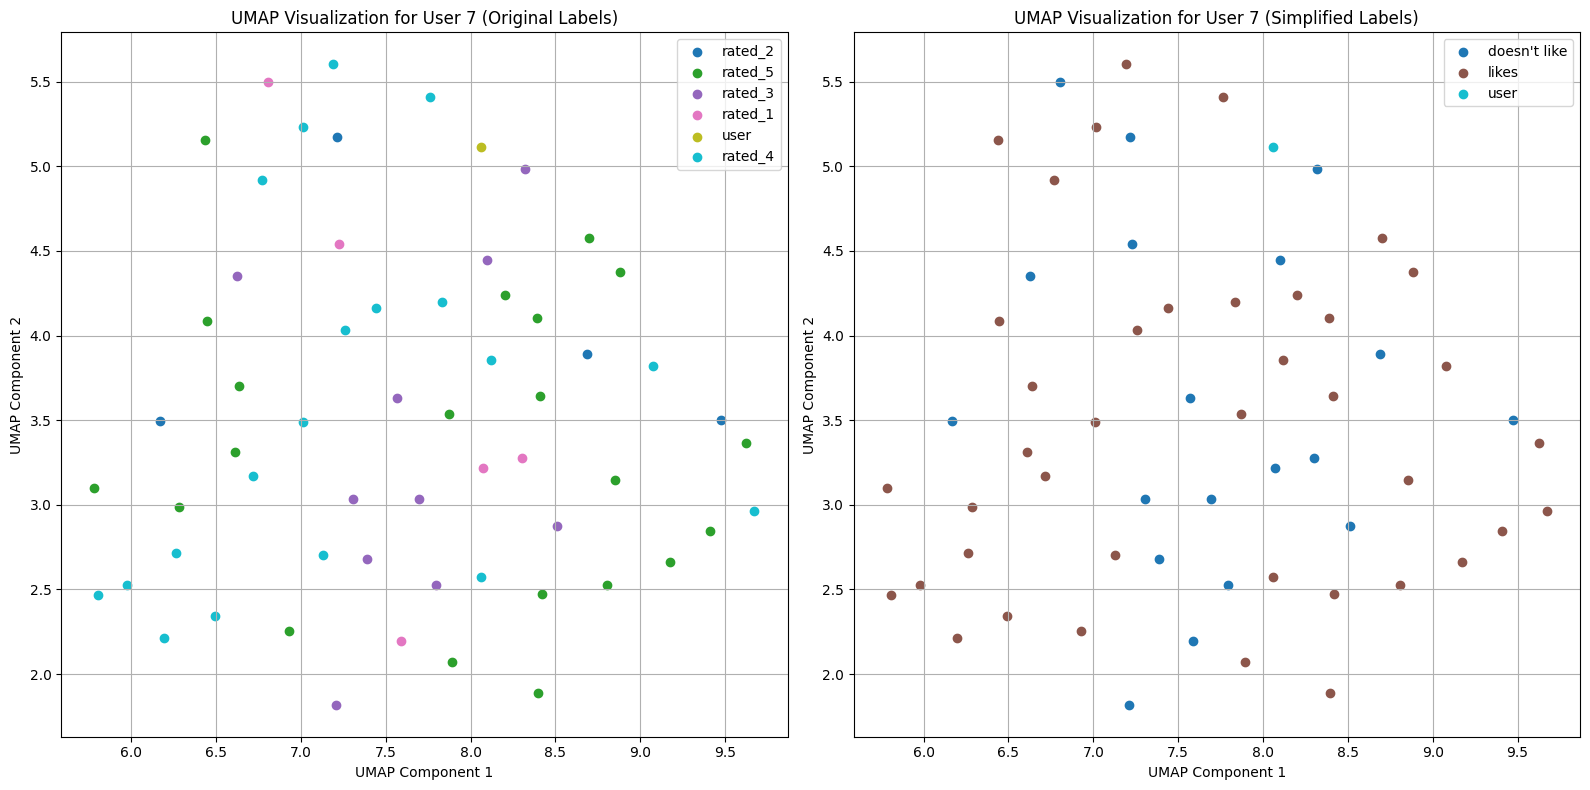

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


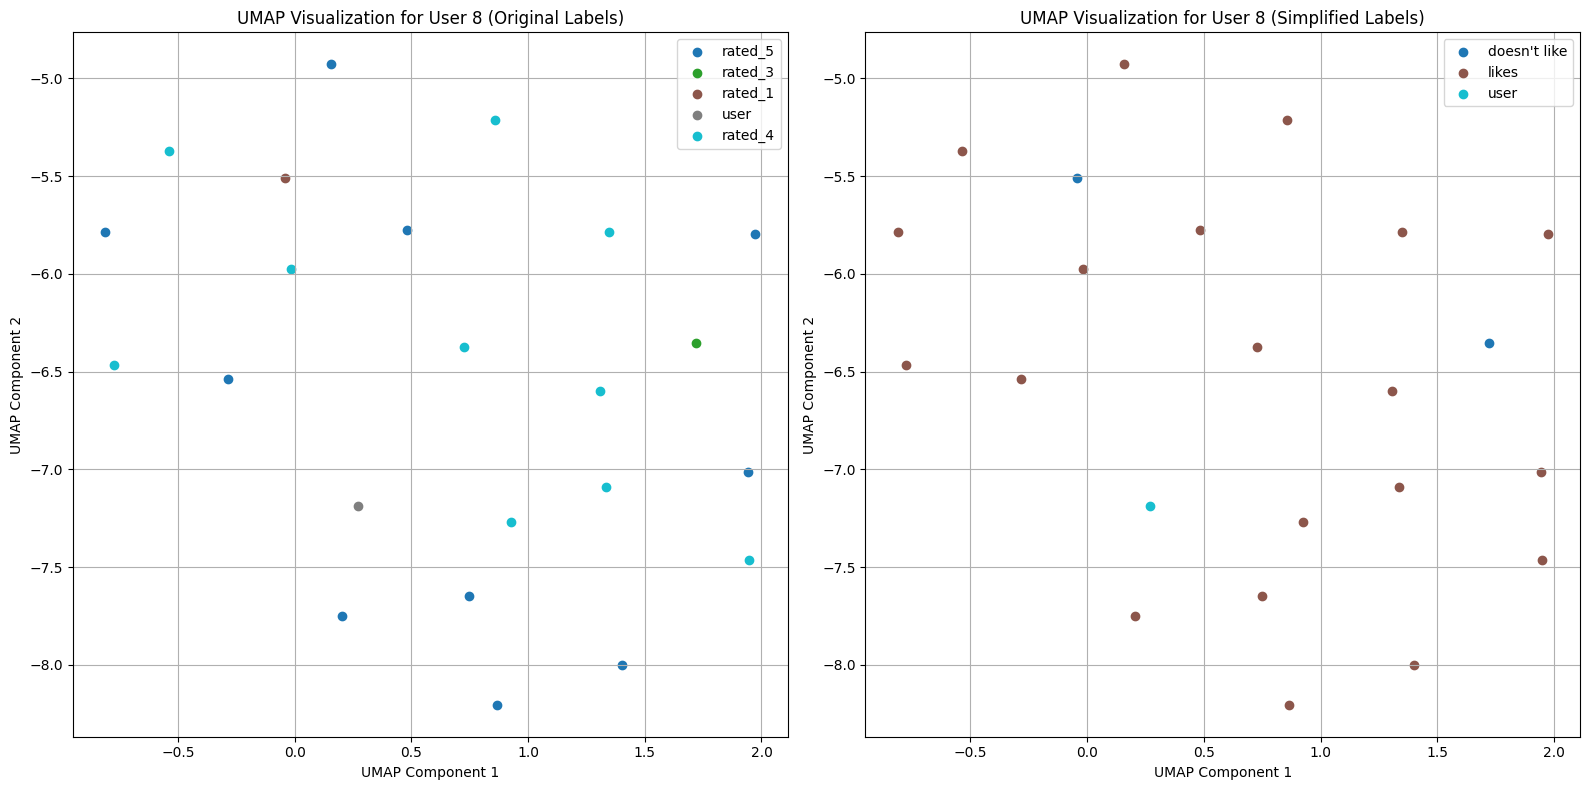

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


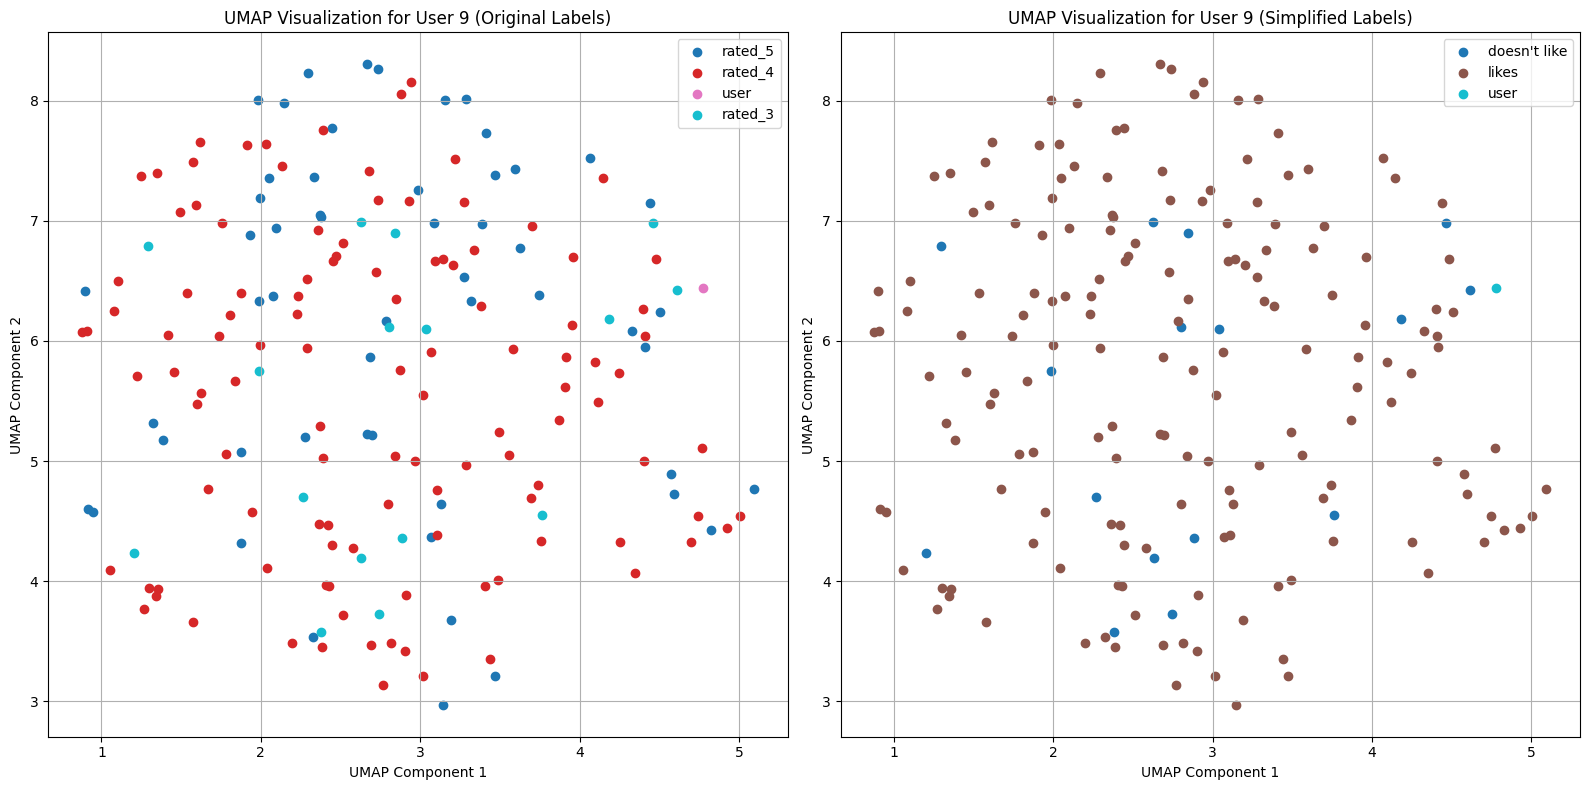

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


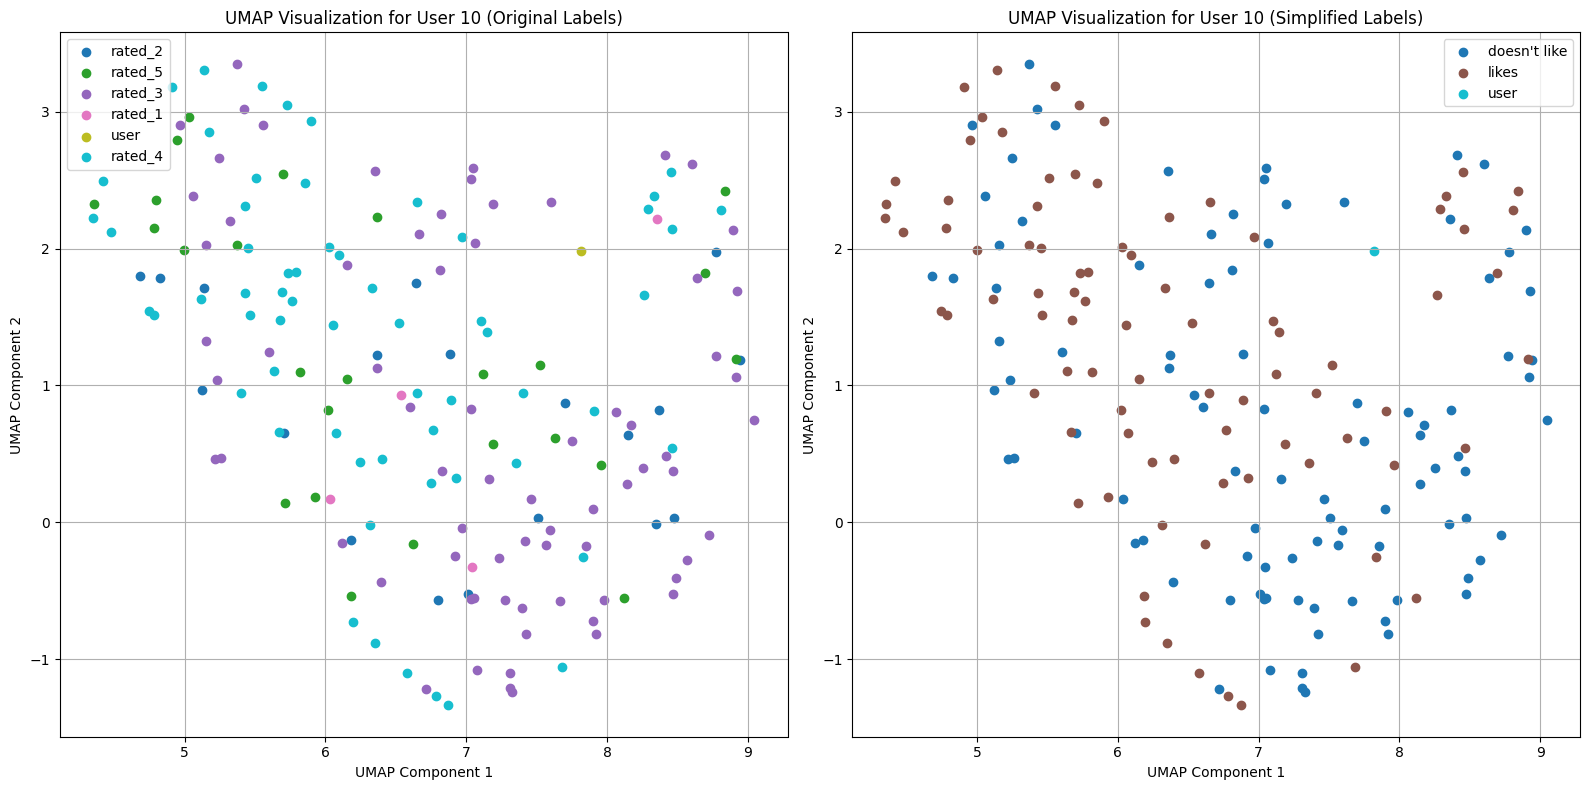

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


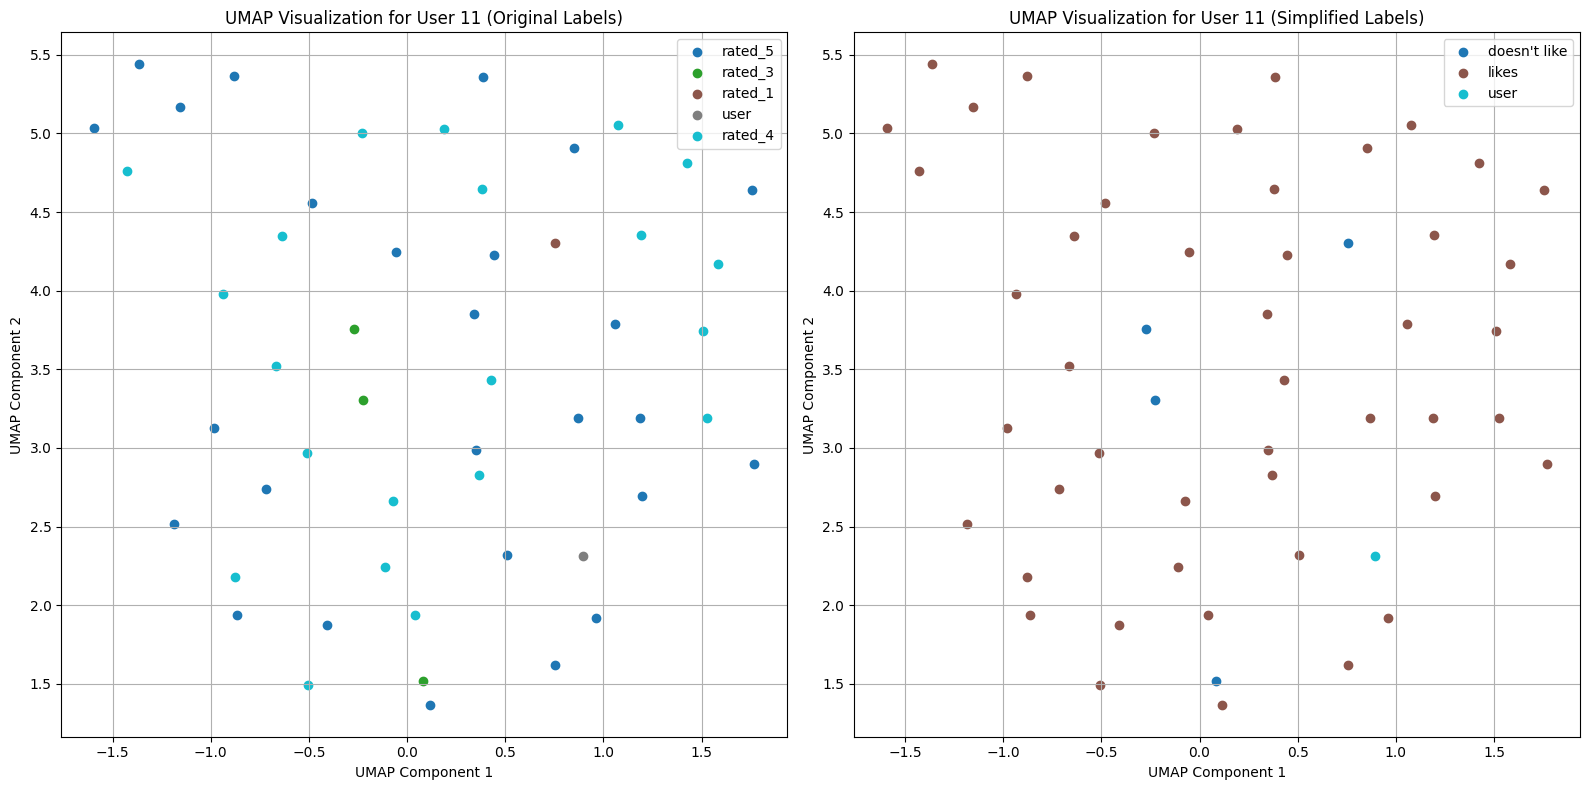

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


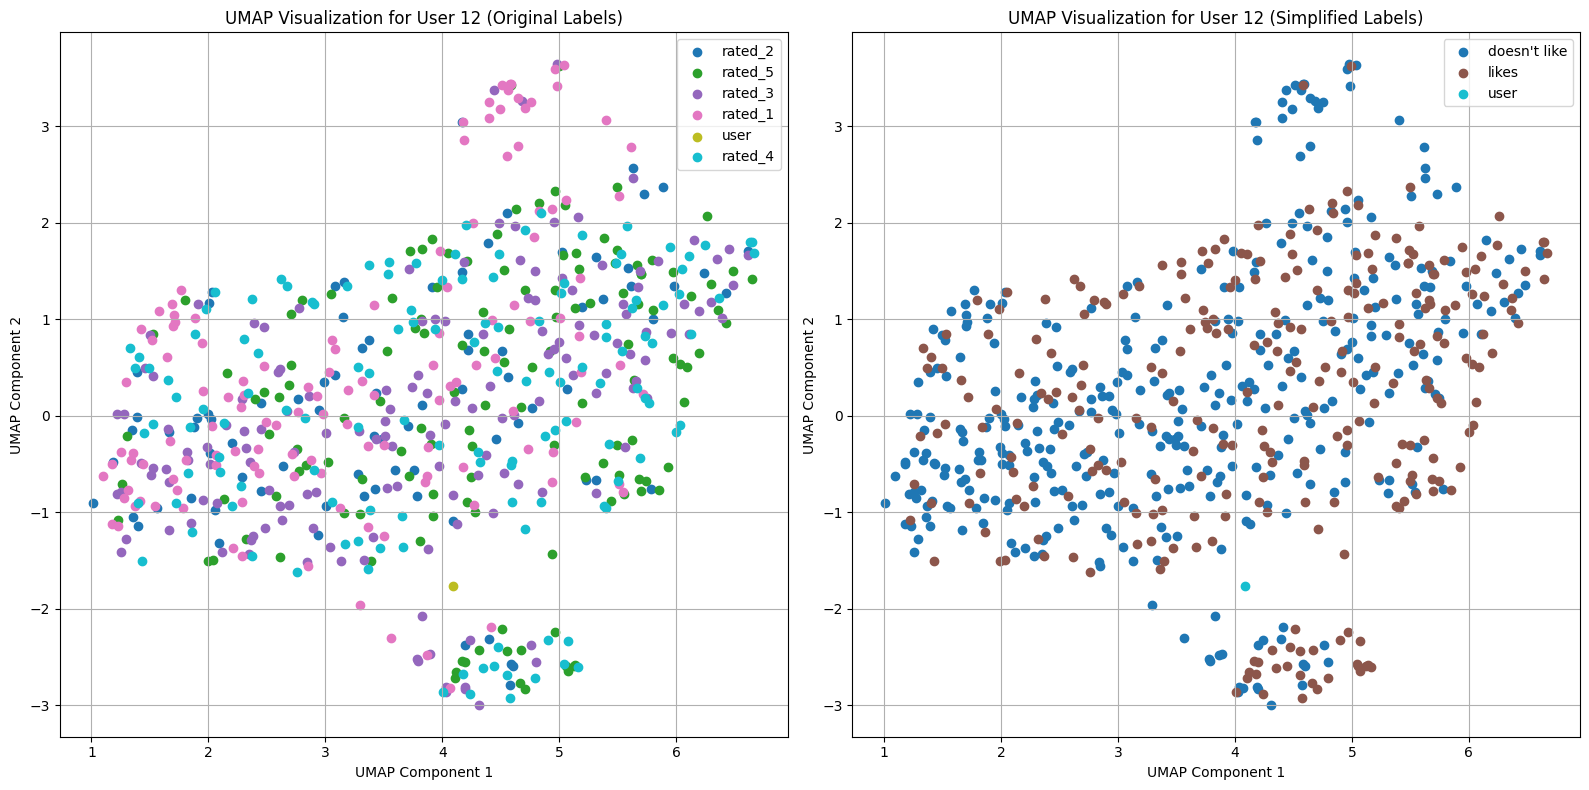

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


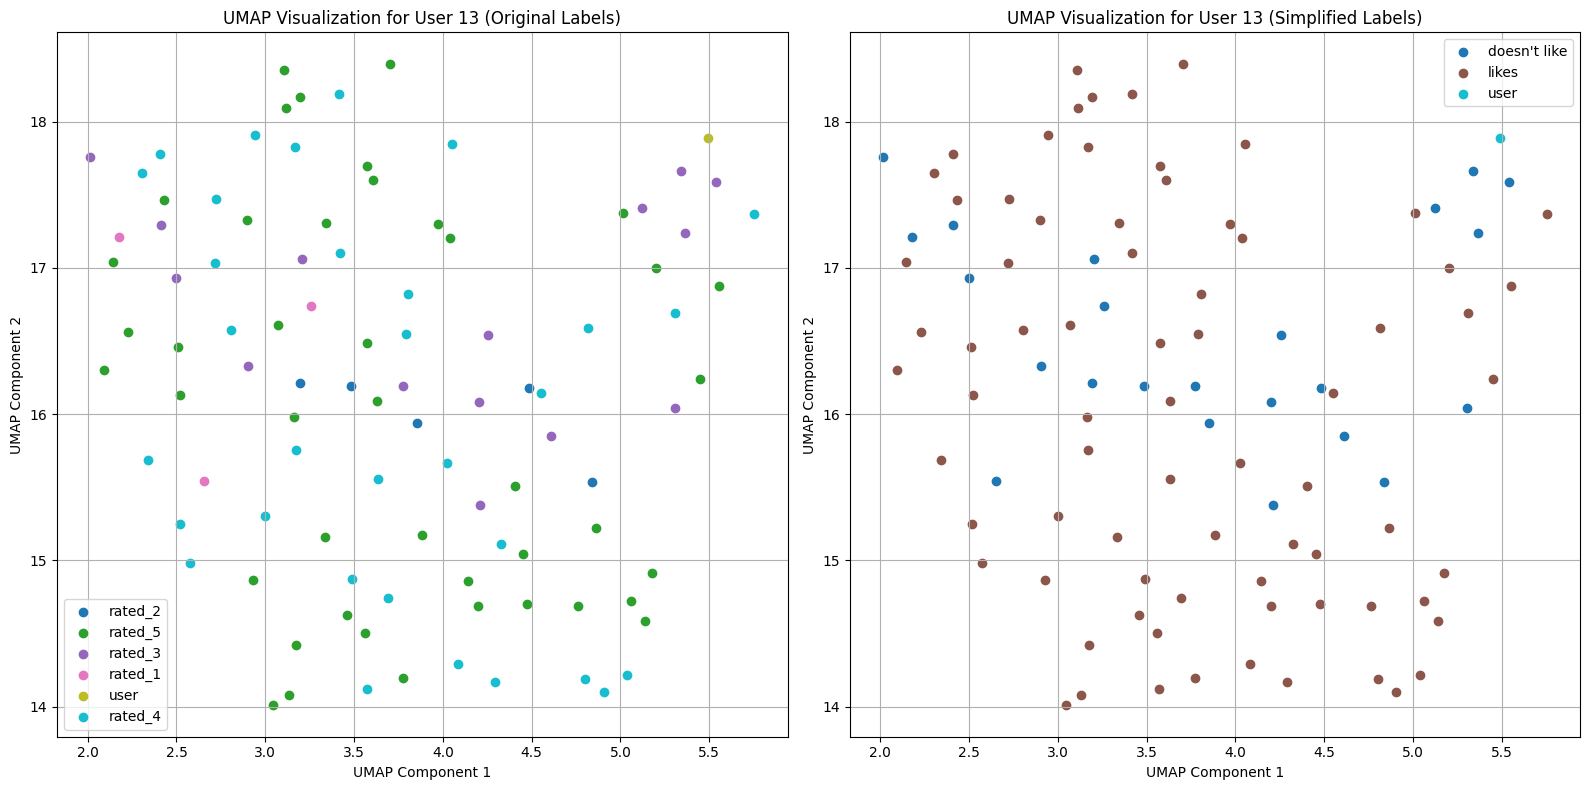

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


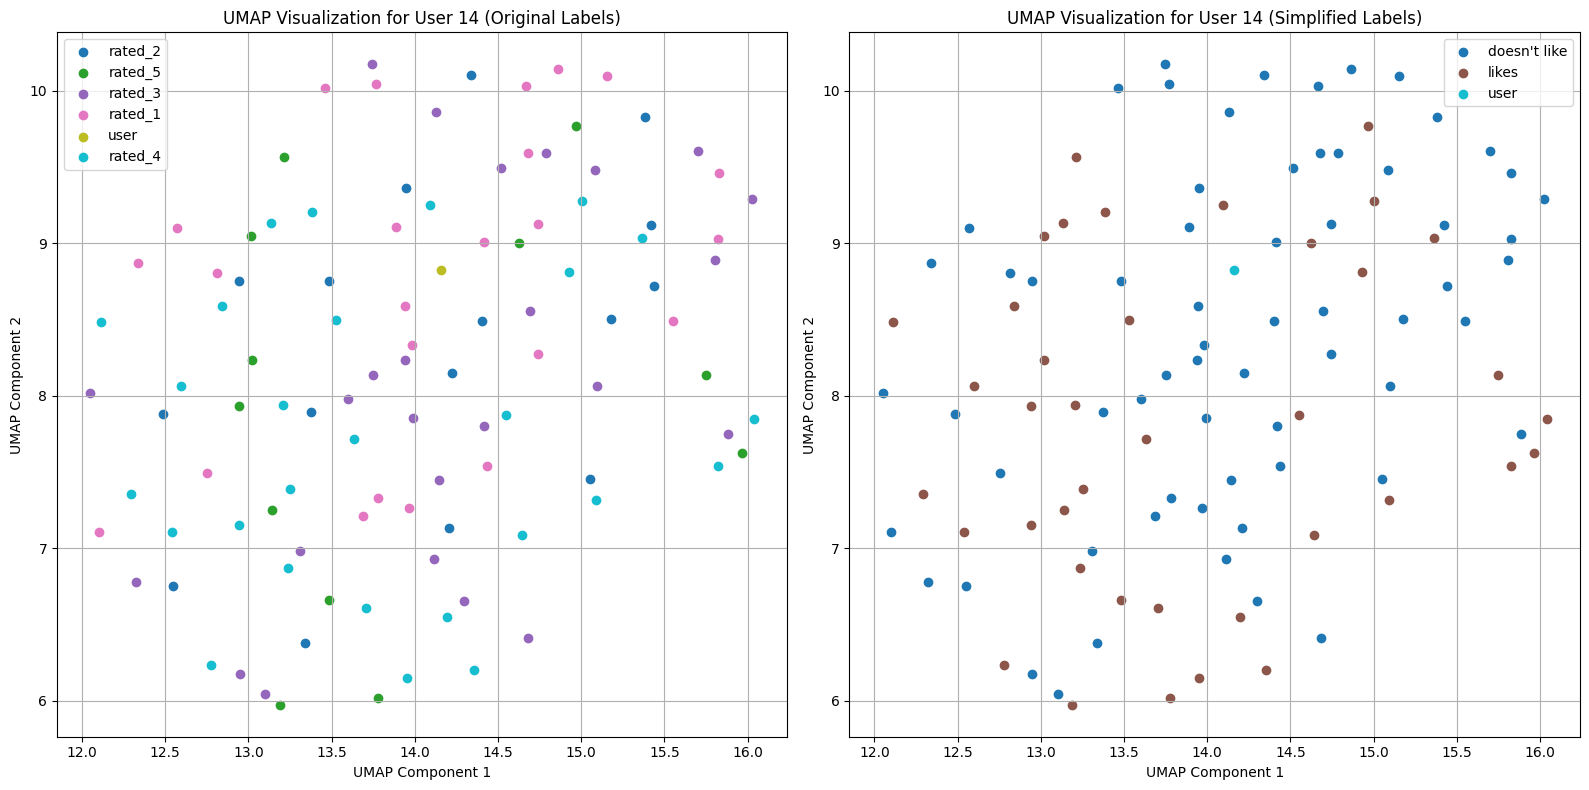

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


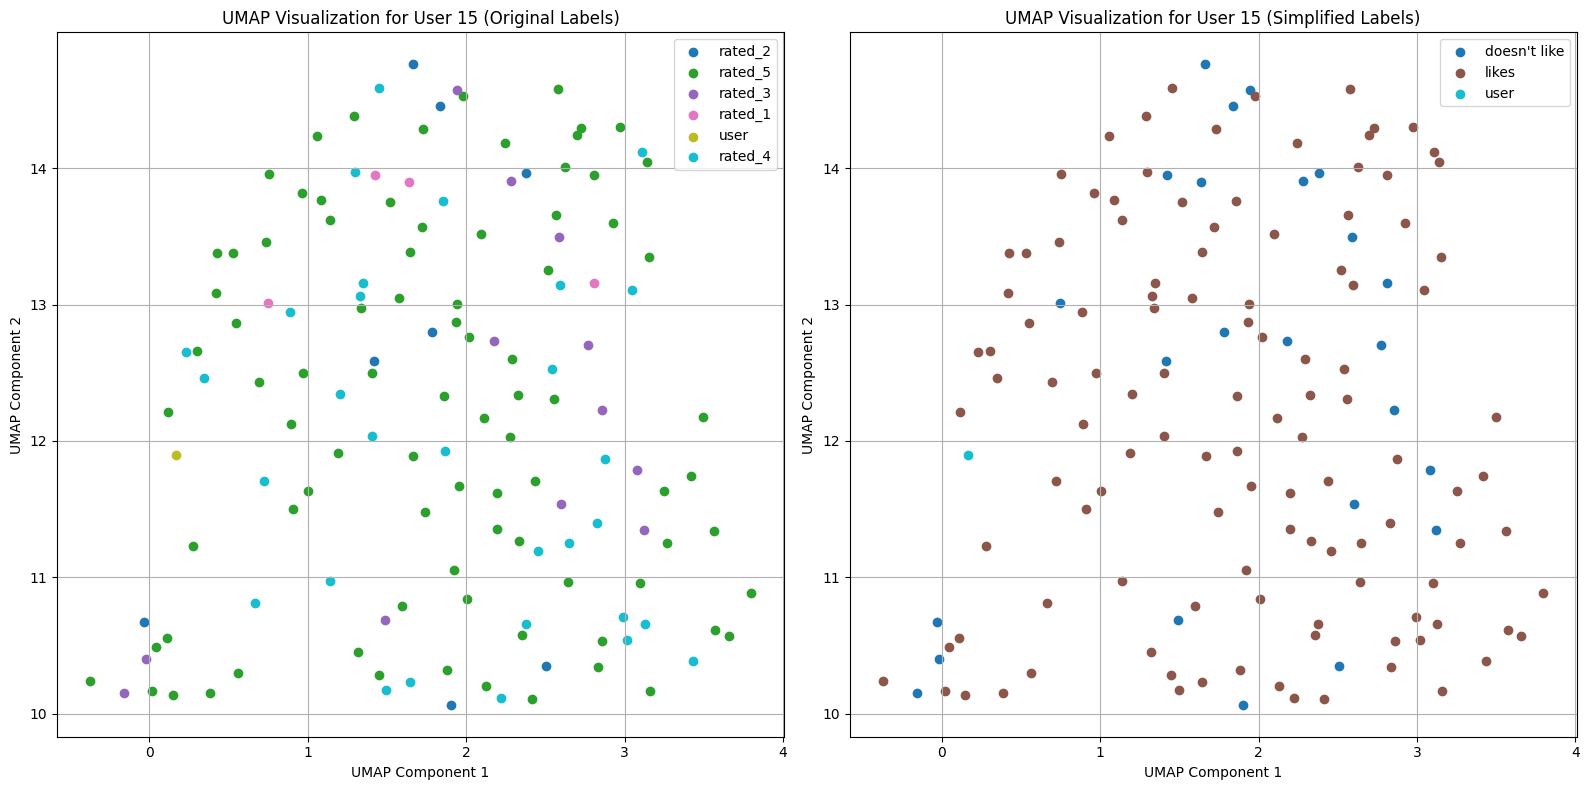

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


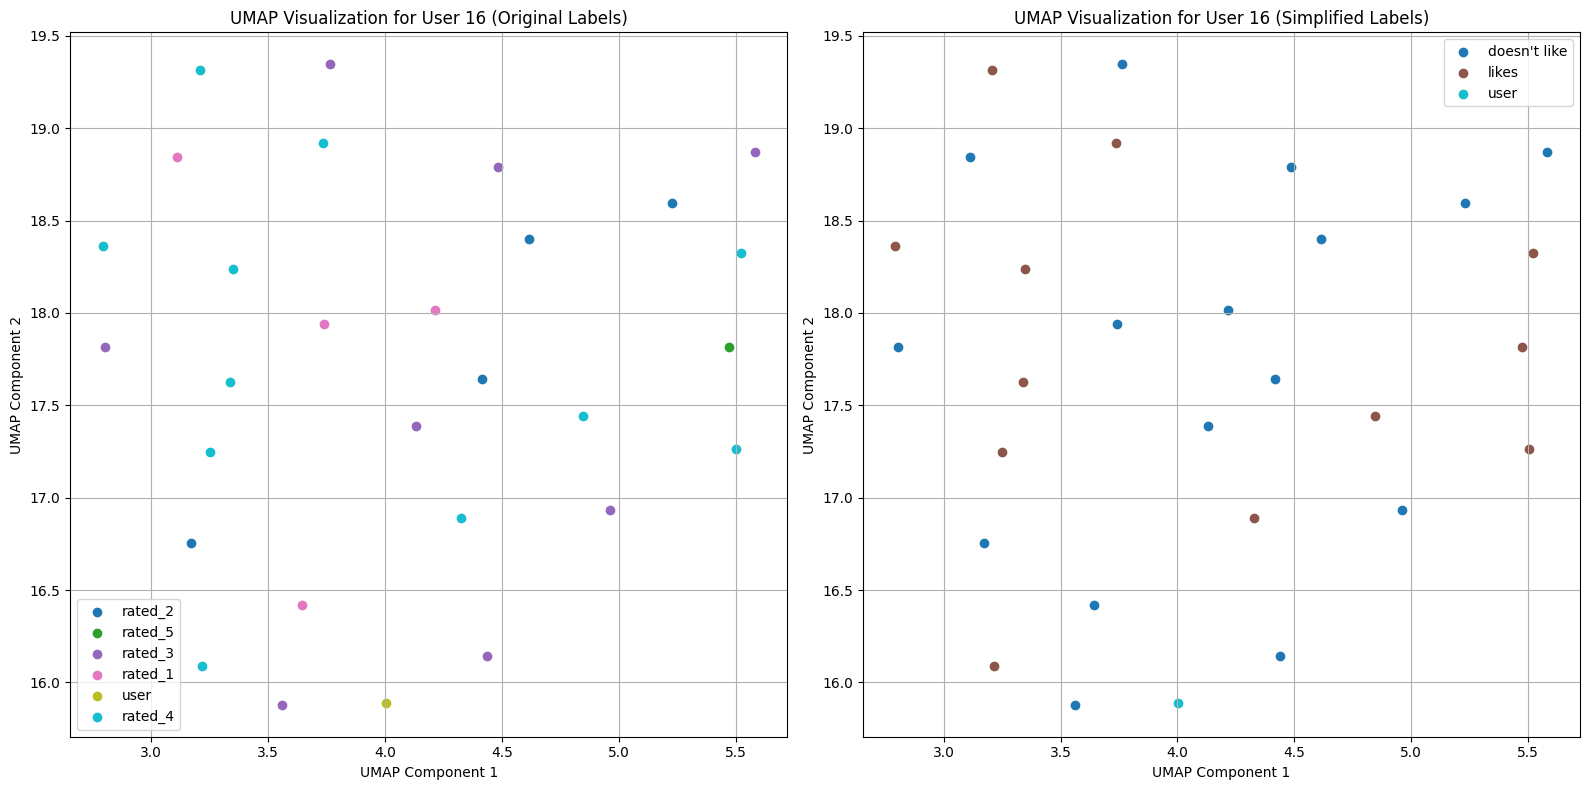

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


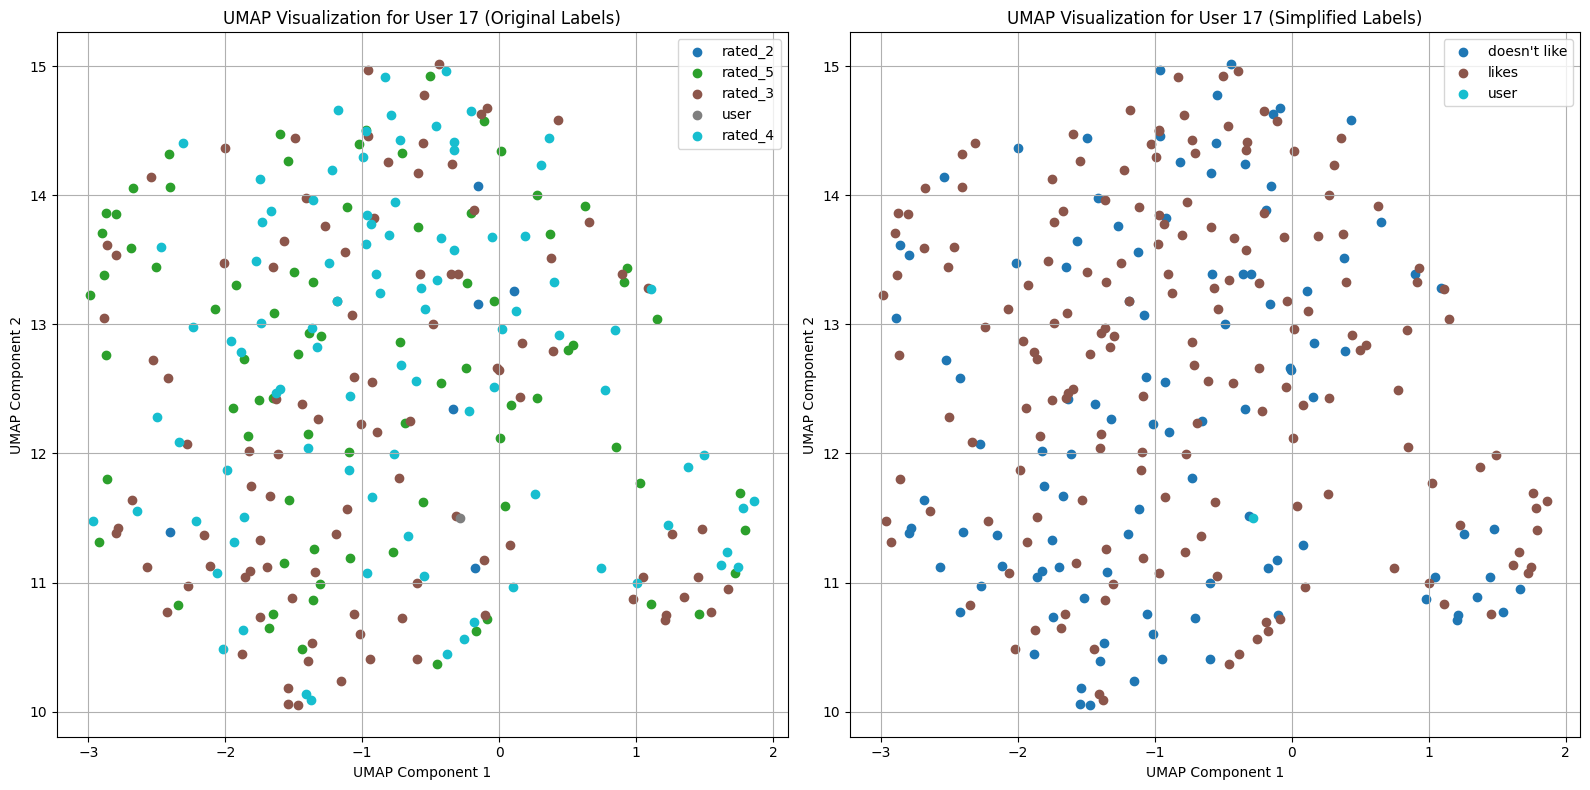

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


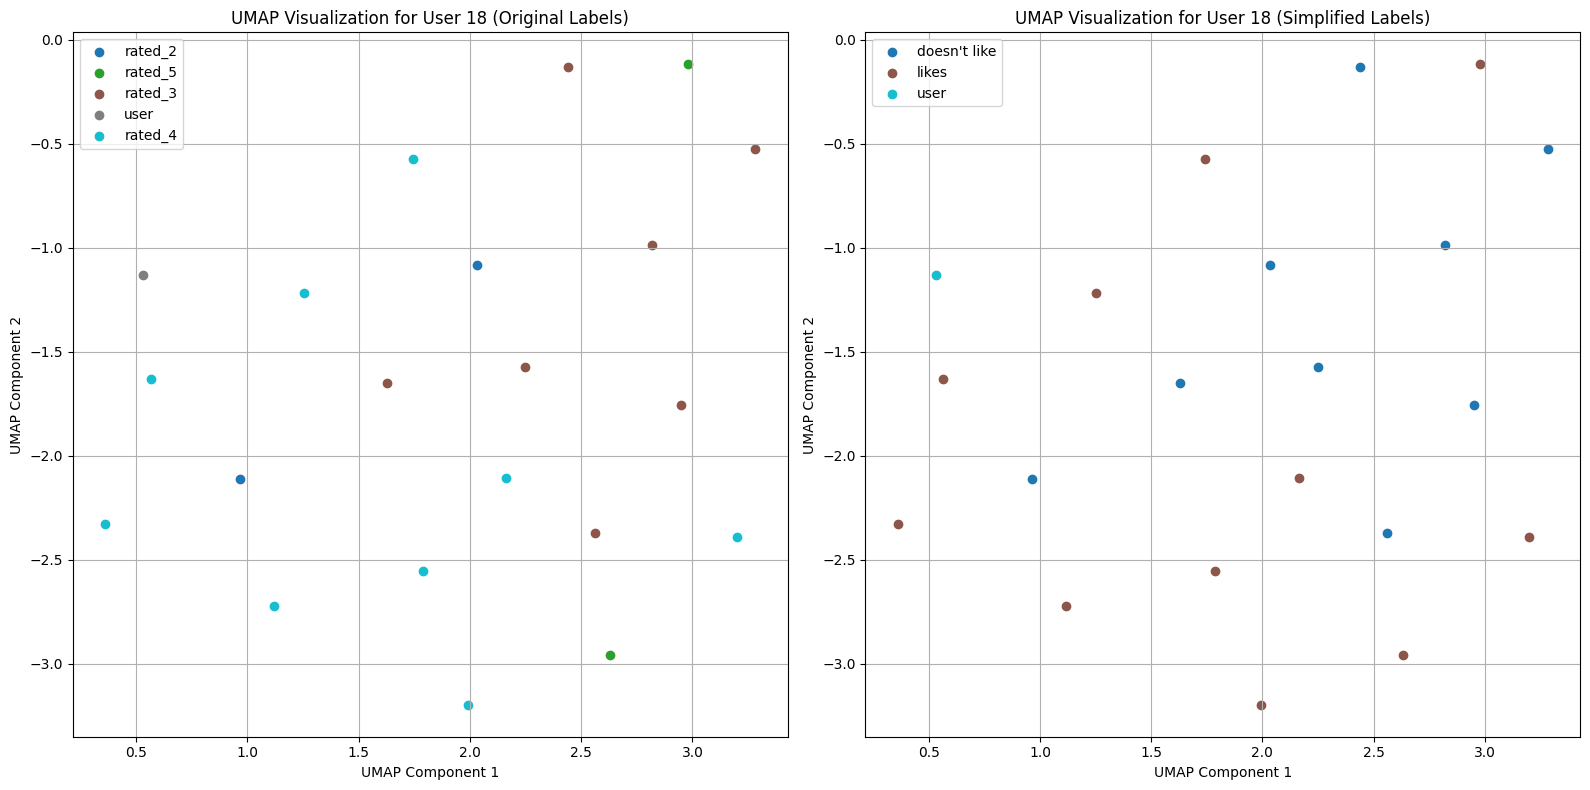

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


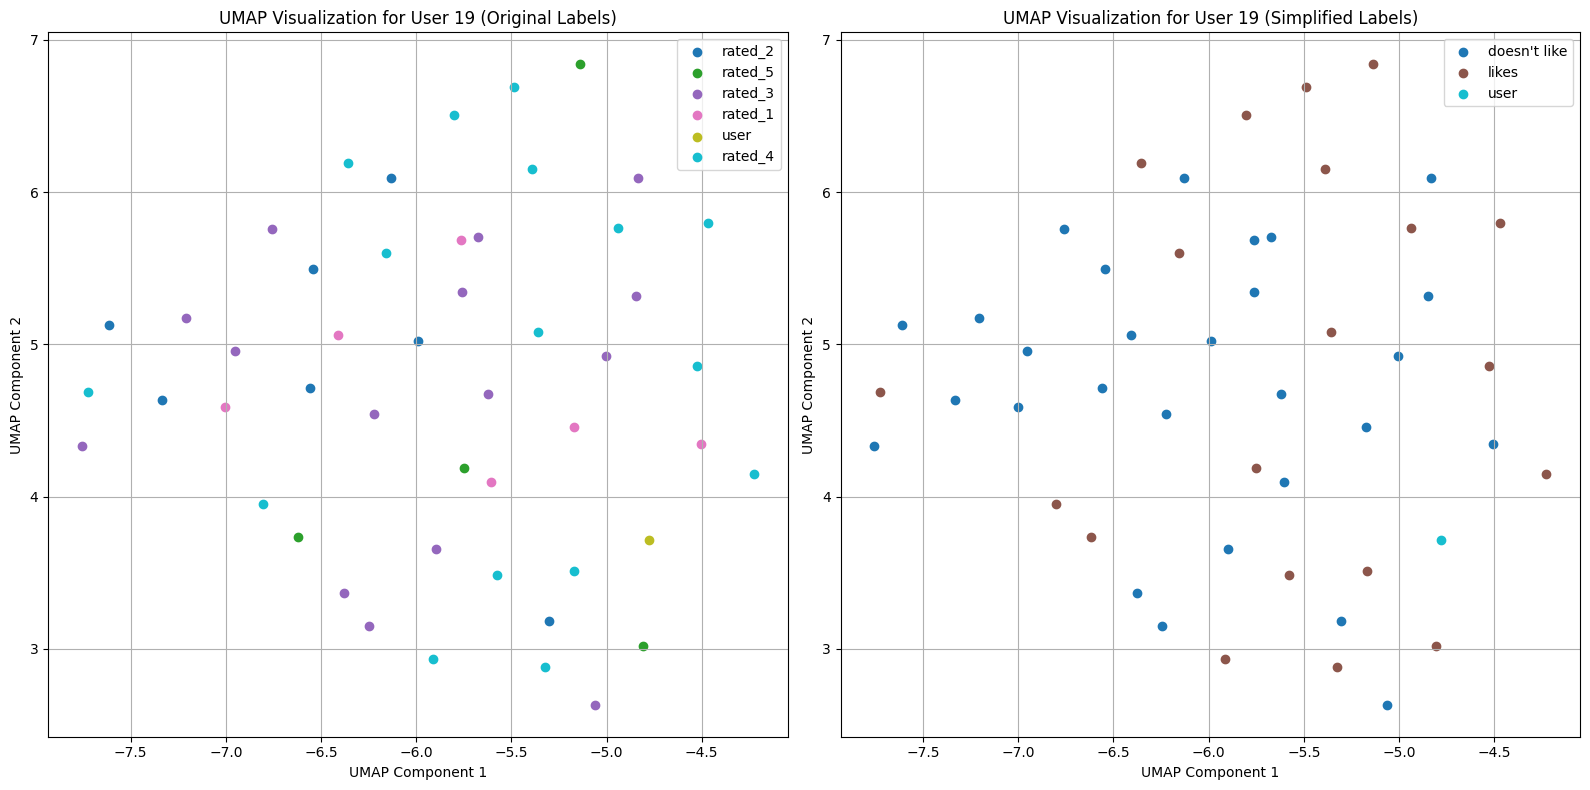

In [56]:
for i in range(20):
    visualize_user_movie_embeddings(i, llm_embedding, movie_embedding, aggregated_df)

In [45]:
llm_embedding_rating = torch.load('user_embeds_rating.pt')
llm_embedding_rating.shape

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_85254/2610115984.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  llm_embedding_rating = torch.load('user_embed

torch.Size([943, 512])

In [46]:
movie_embedding_rating = torch.load('movie_embeds_rating.pt')
movie_embedding_rating.shape

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_85254/2585915352.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  movie_embedding_rating = torch.load('movie_em

torch.Size([1682, 512])

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


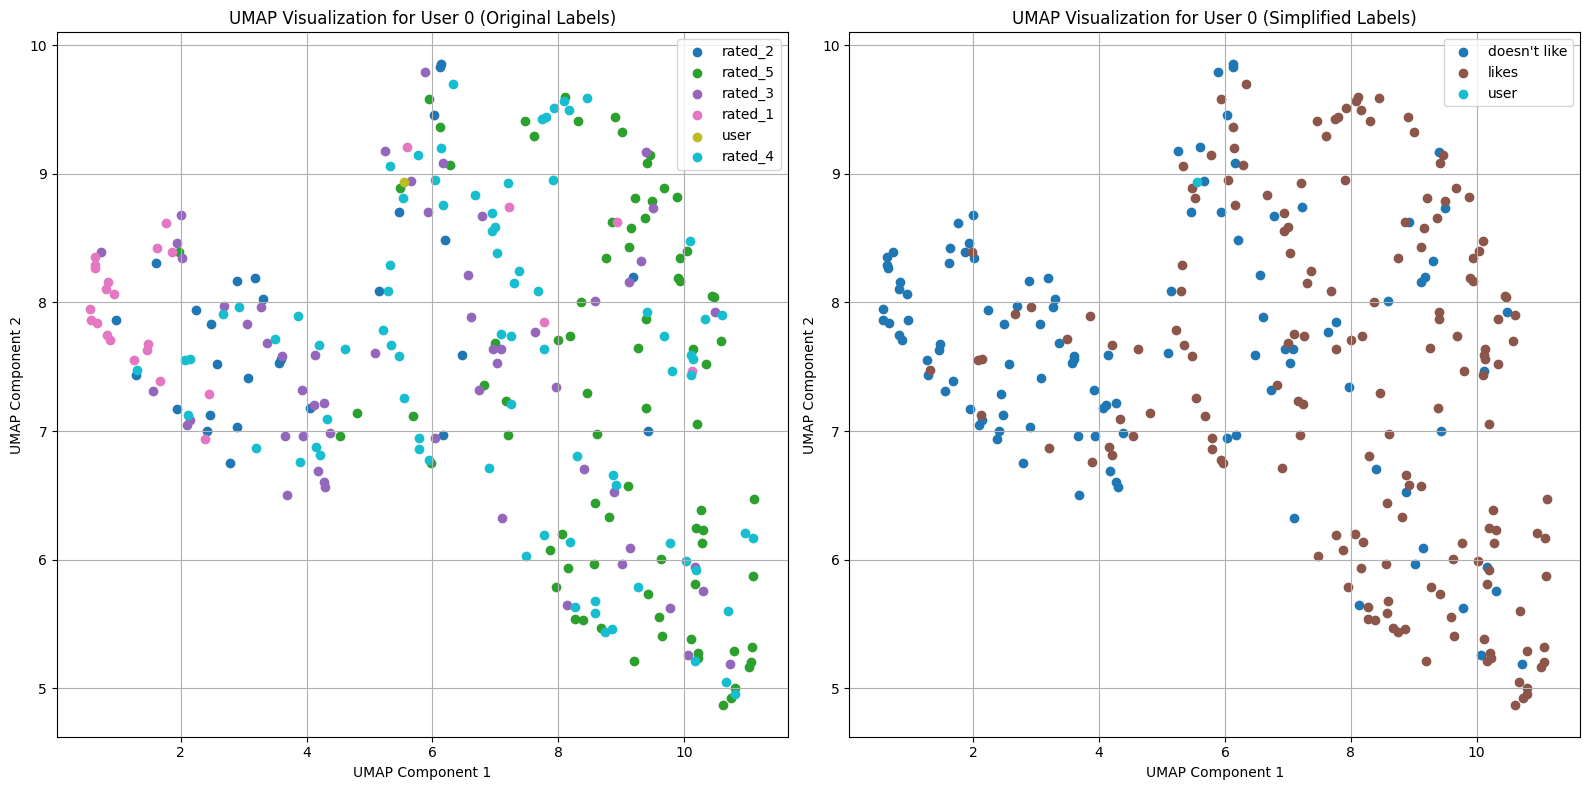

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


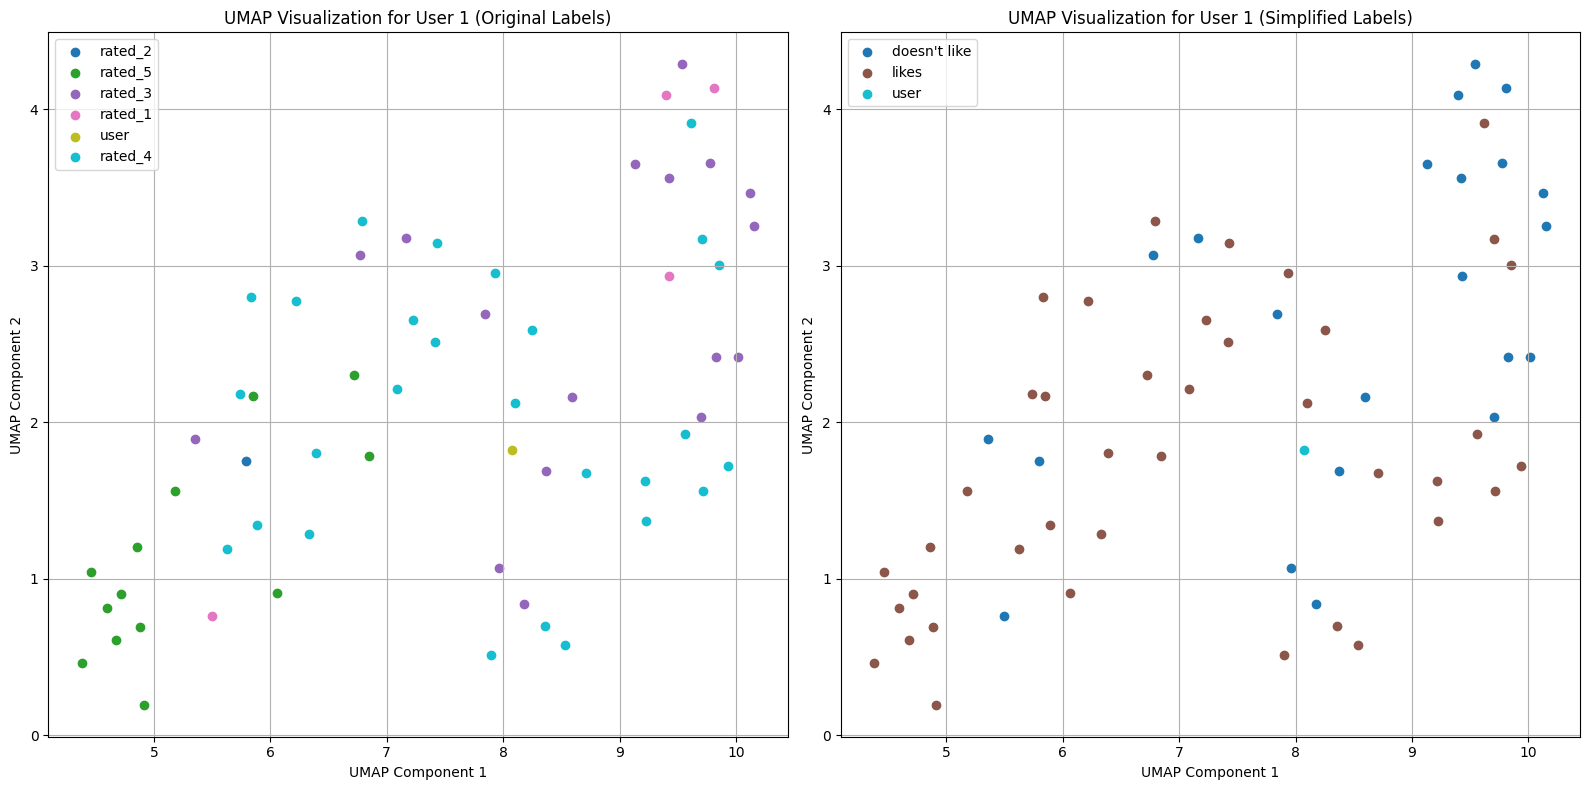

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


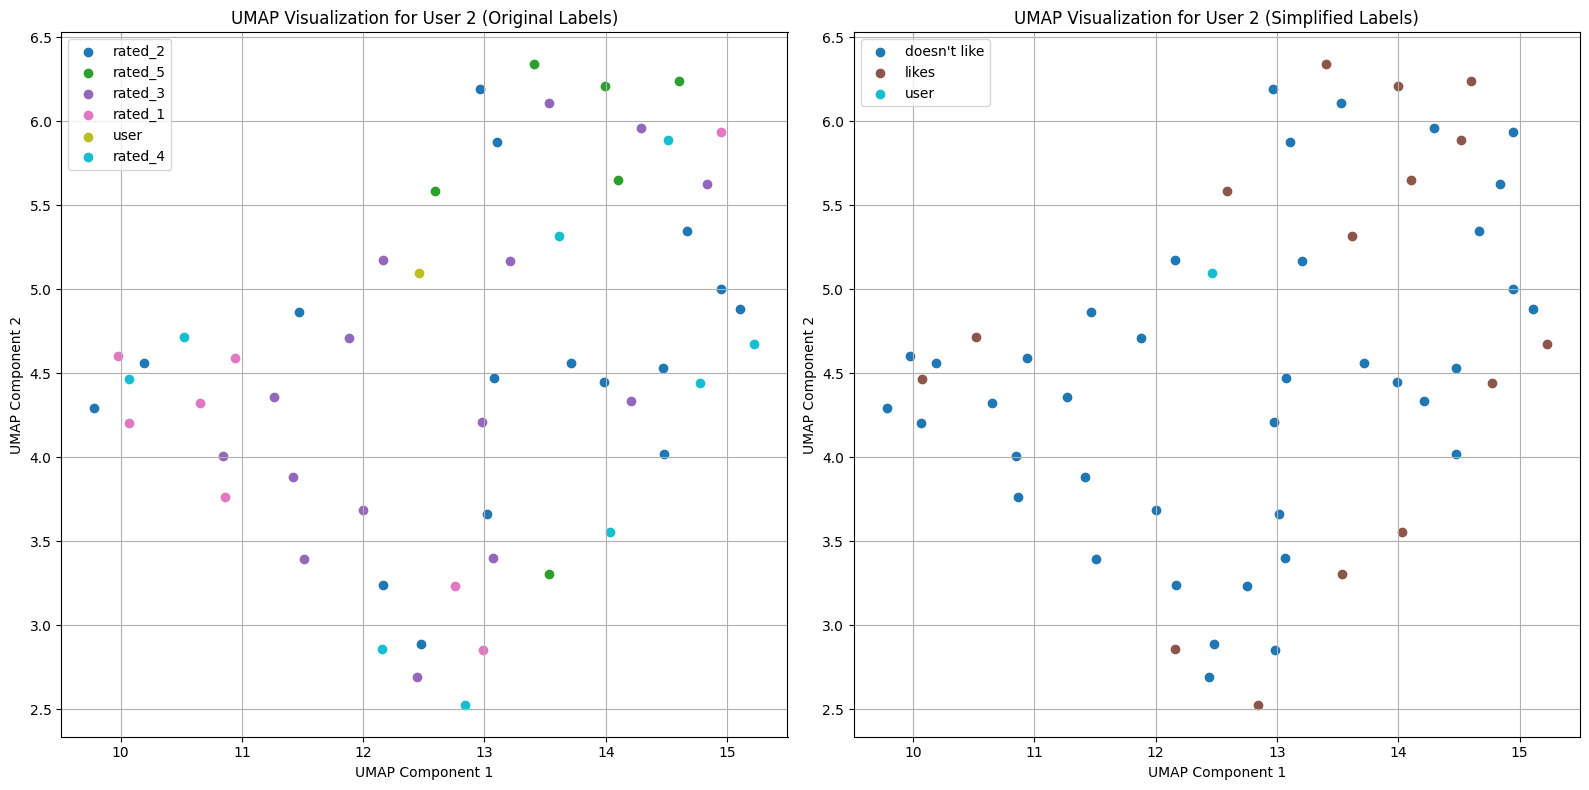

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


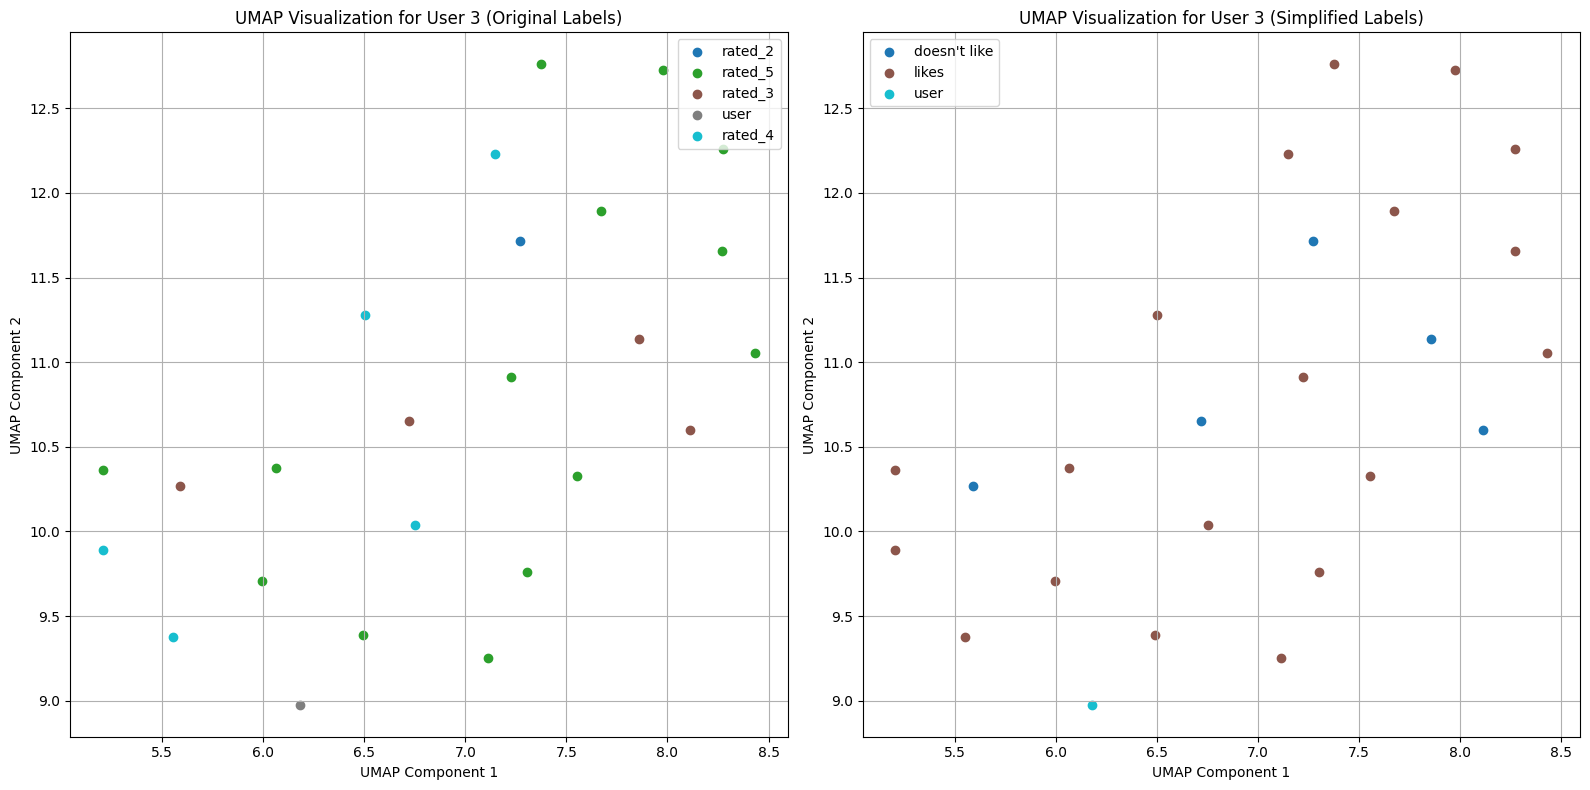

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


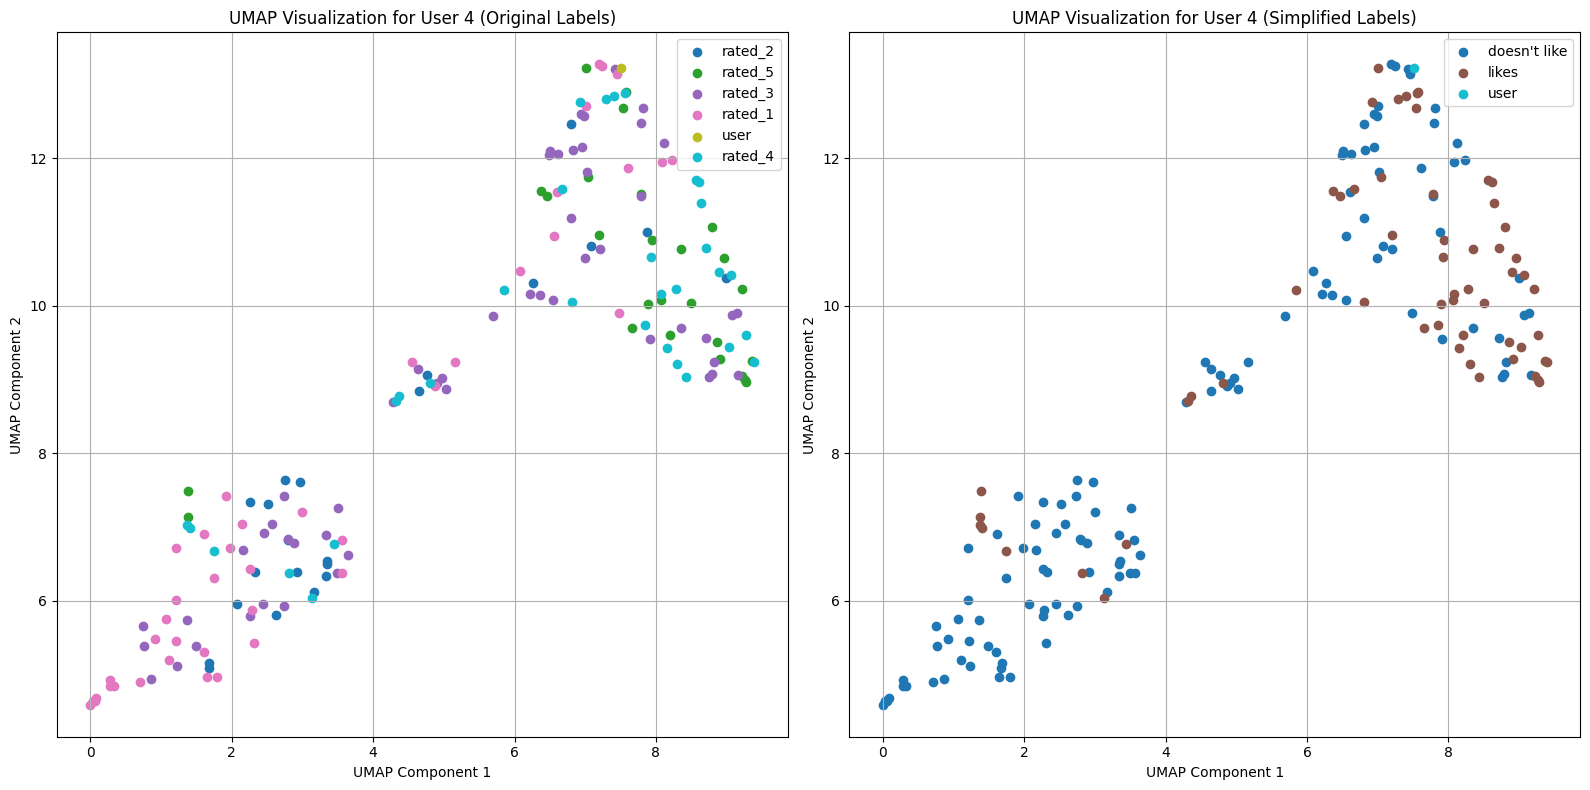

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


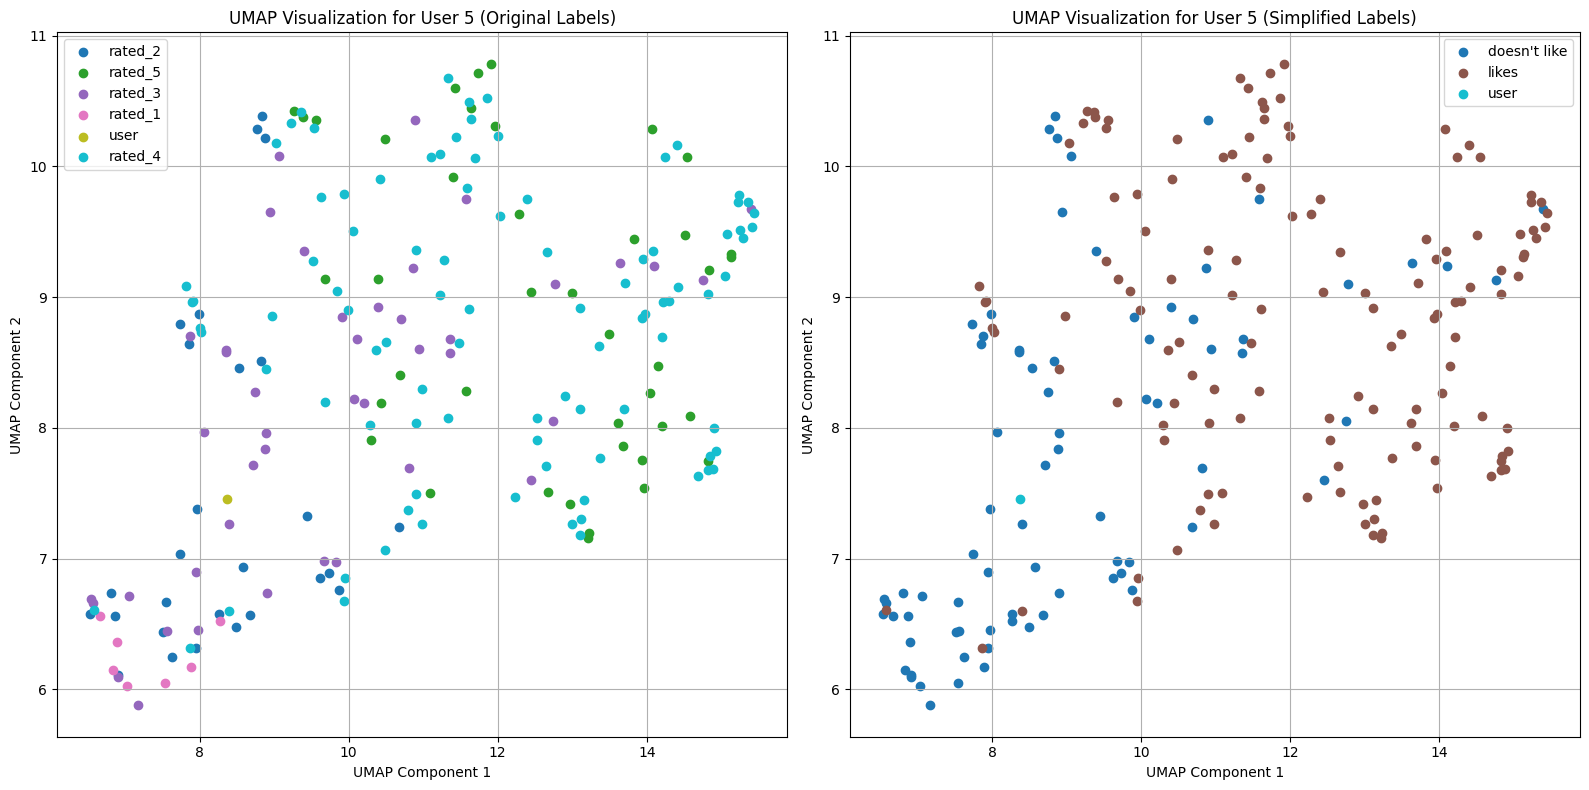

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


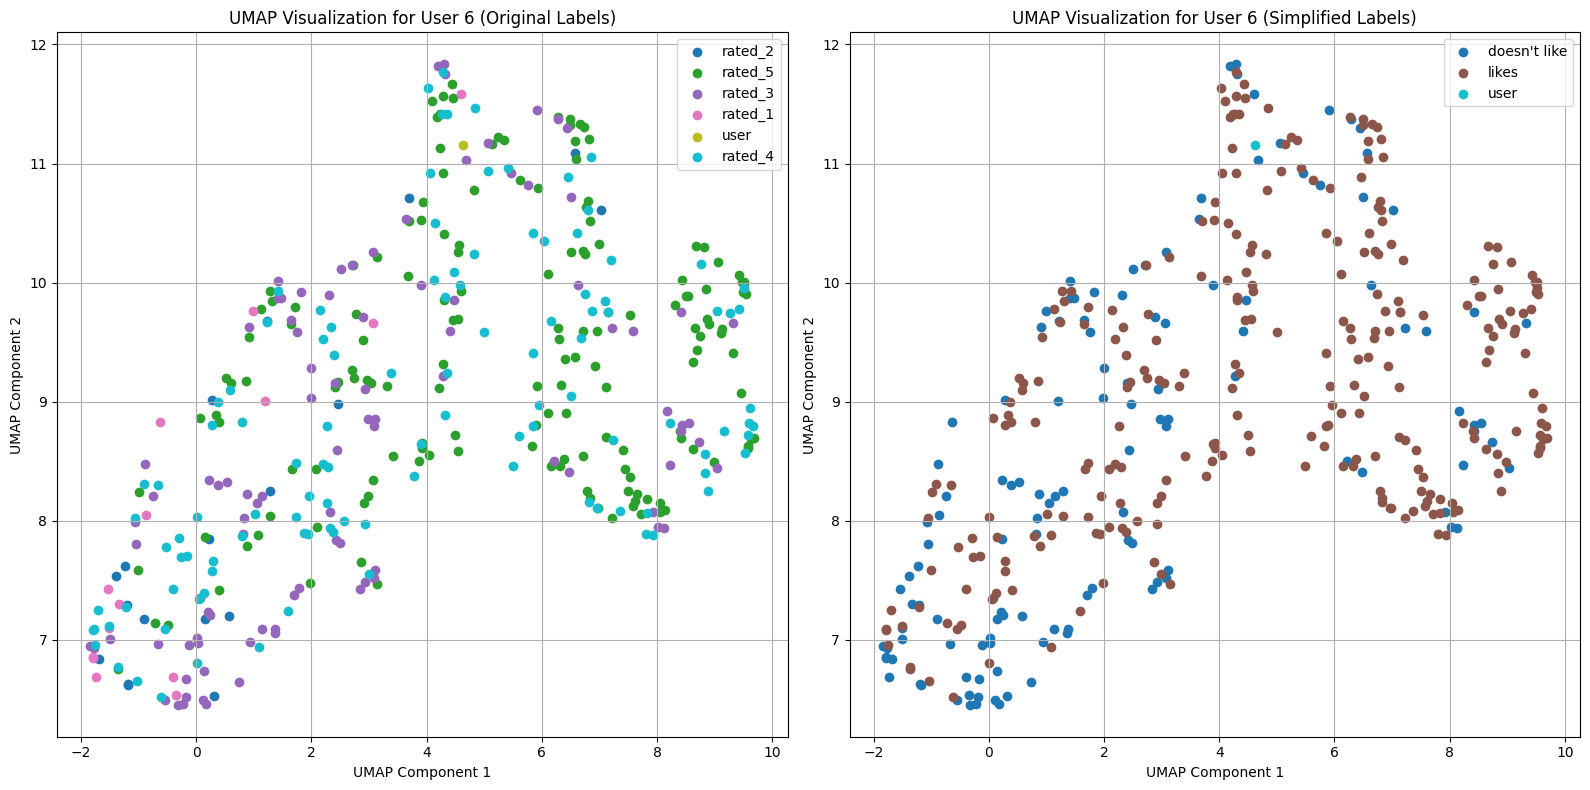

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


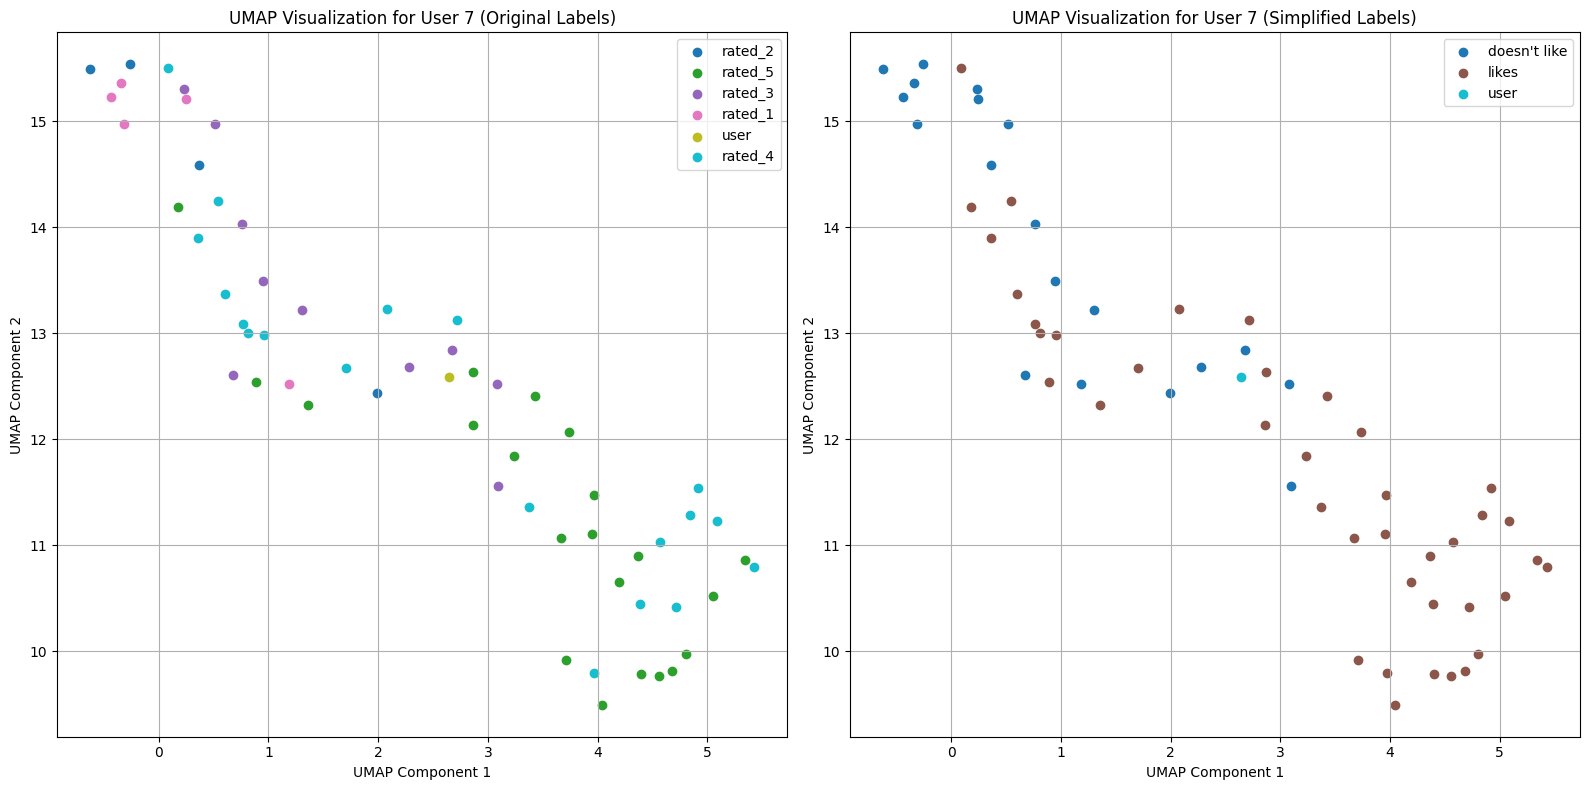

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


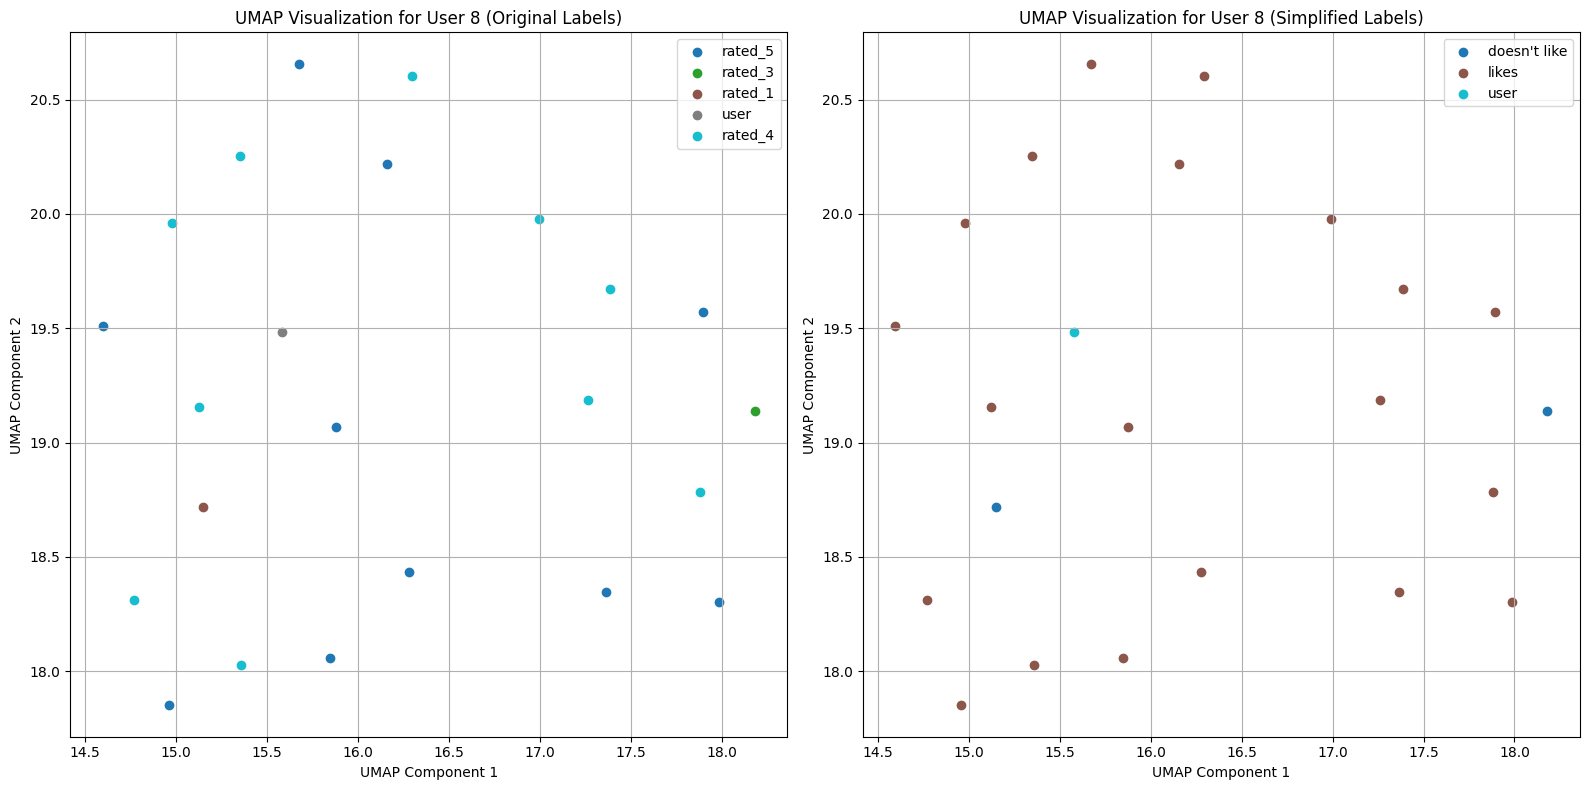

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


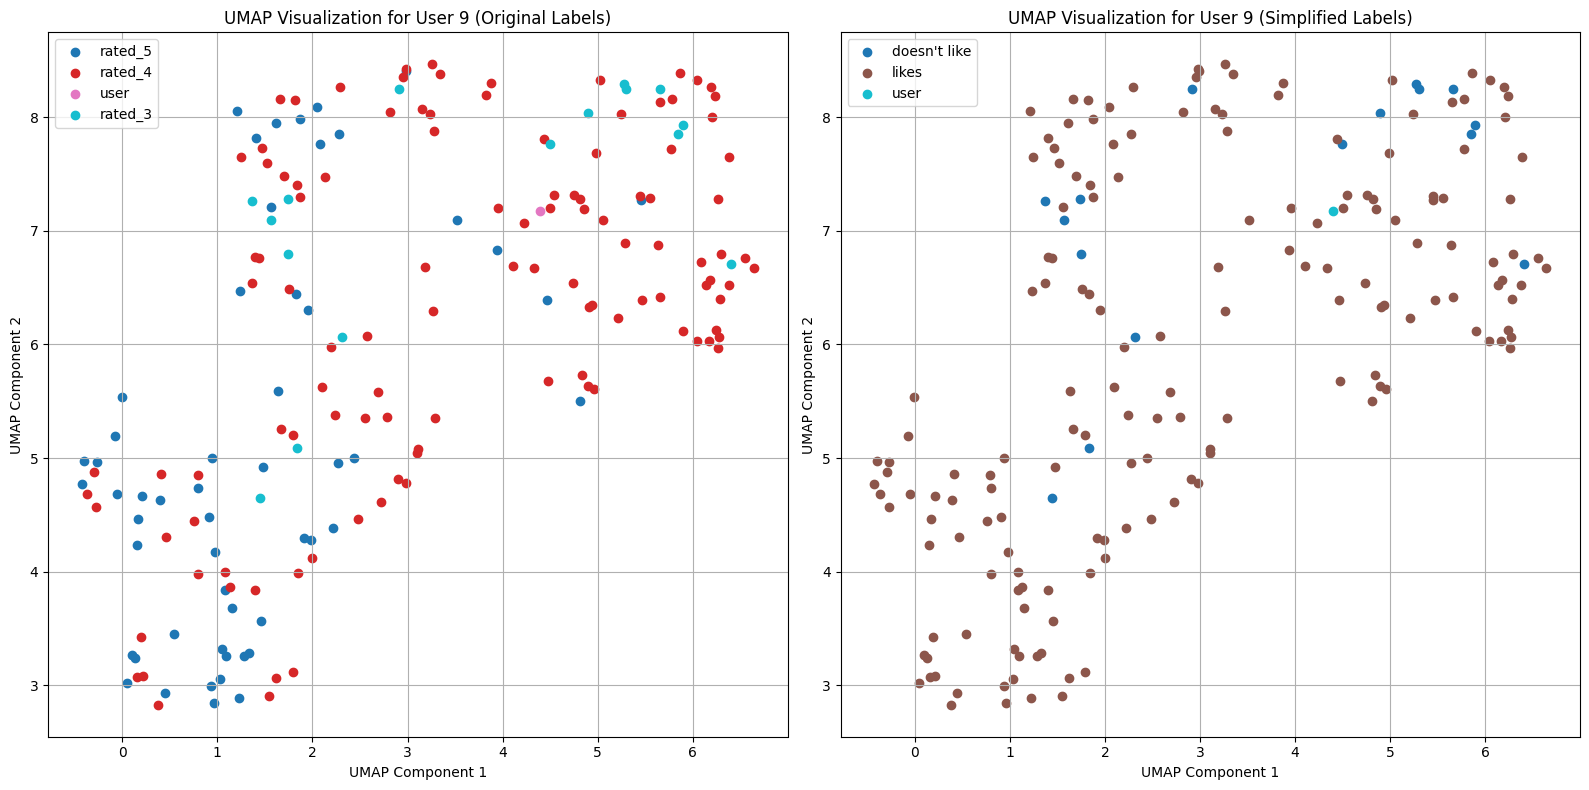

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


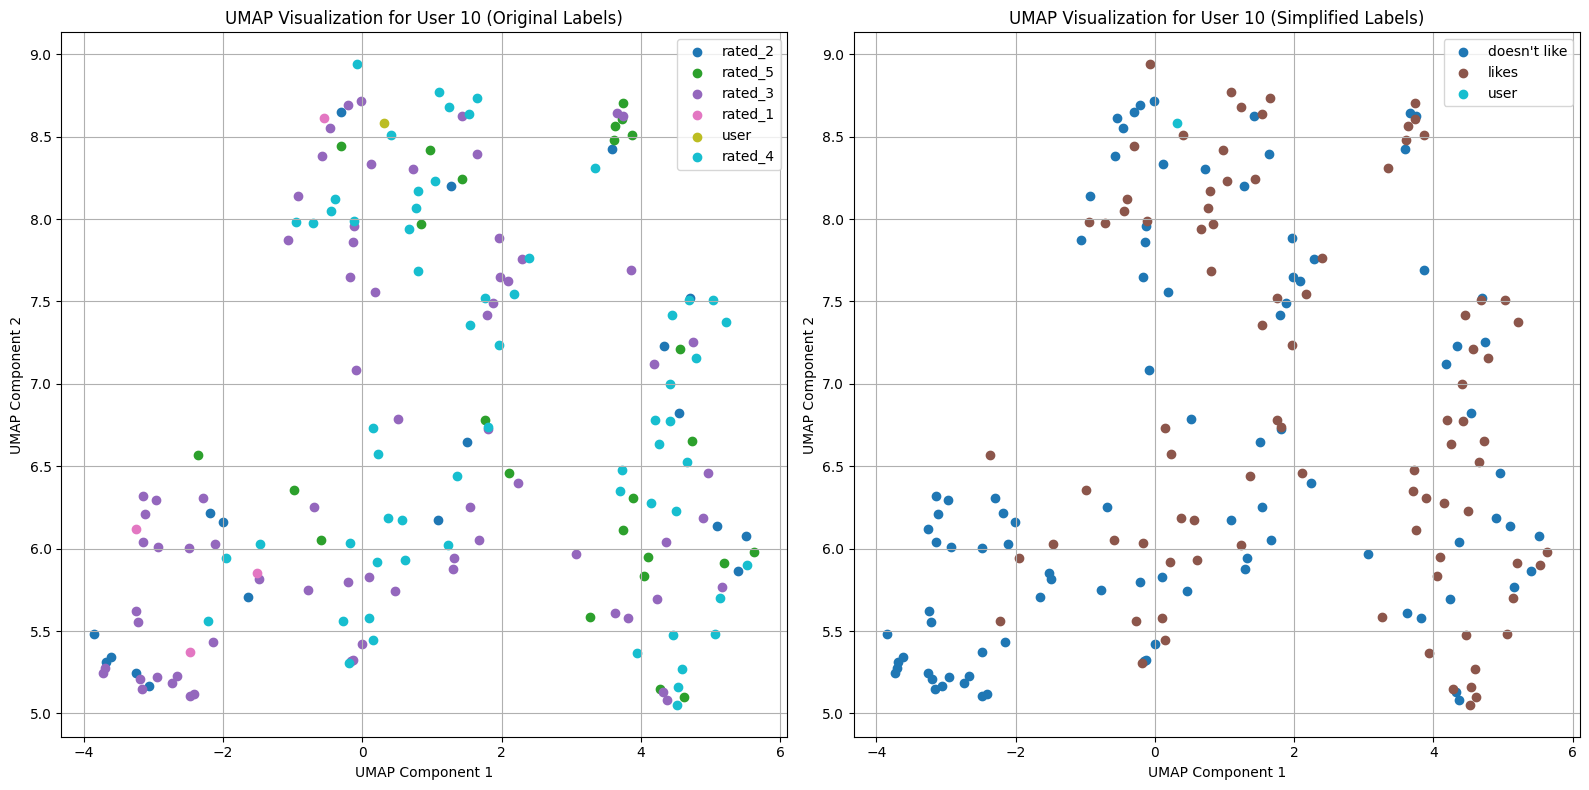

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


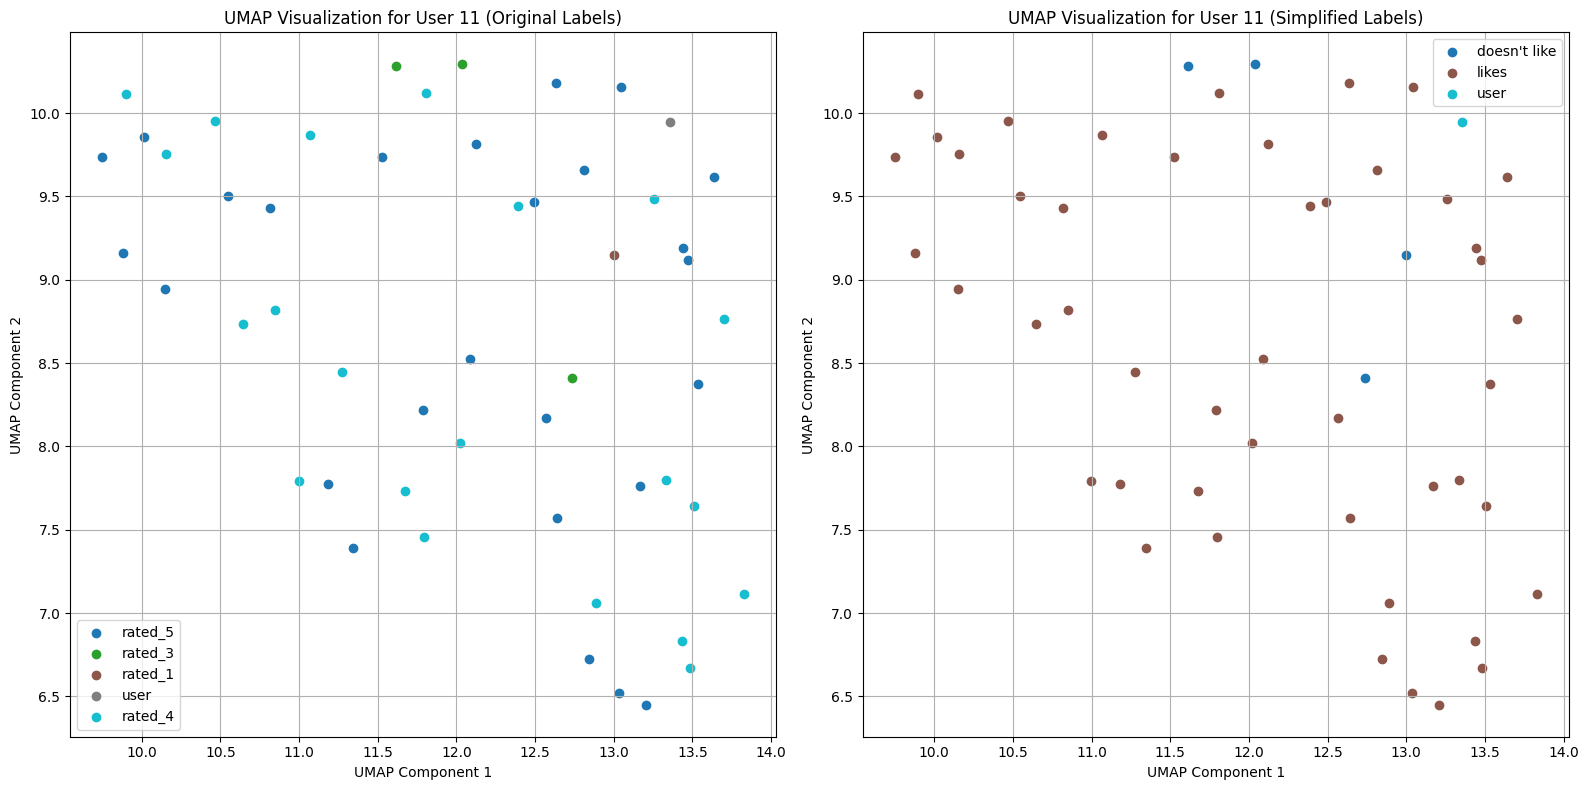

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


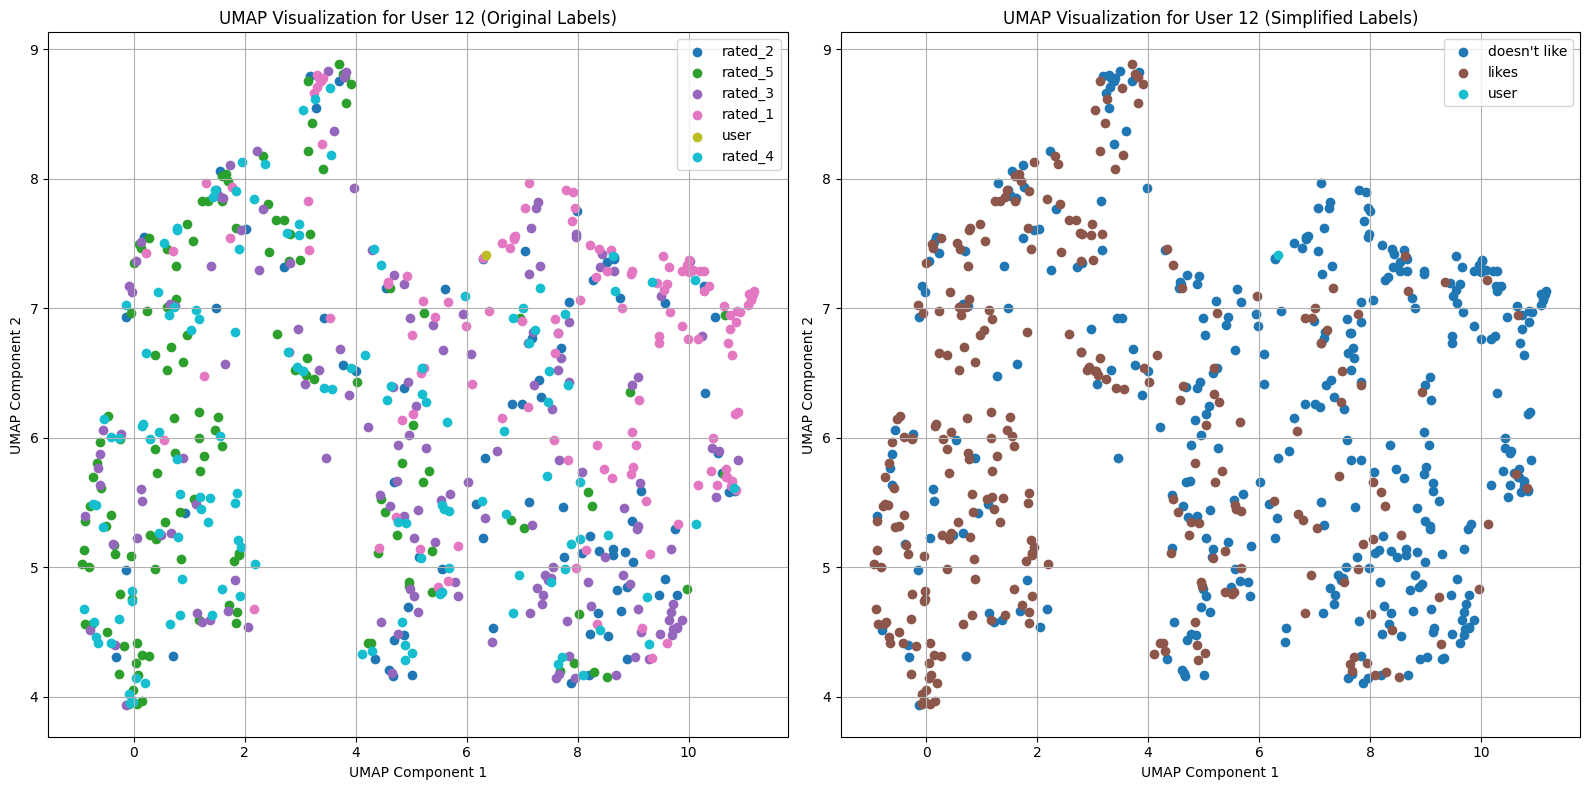

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


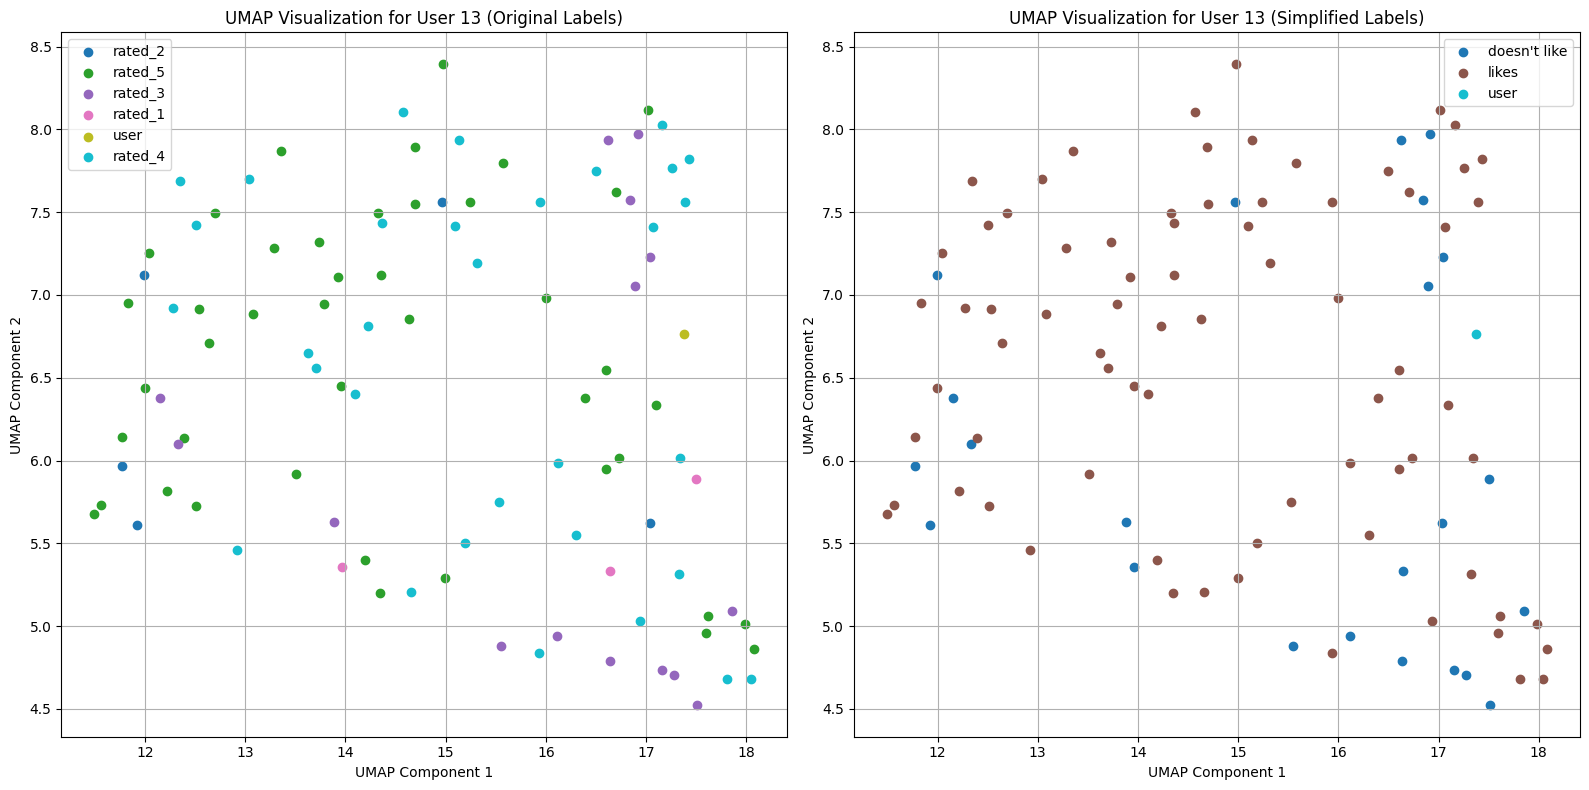

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


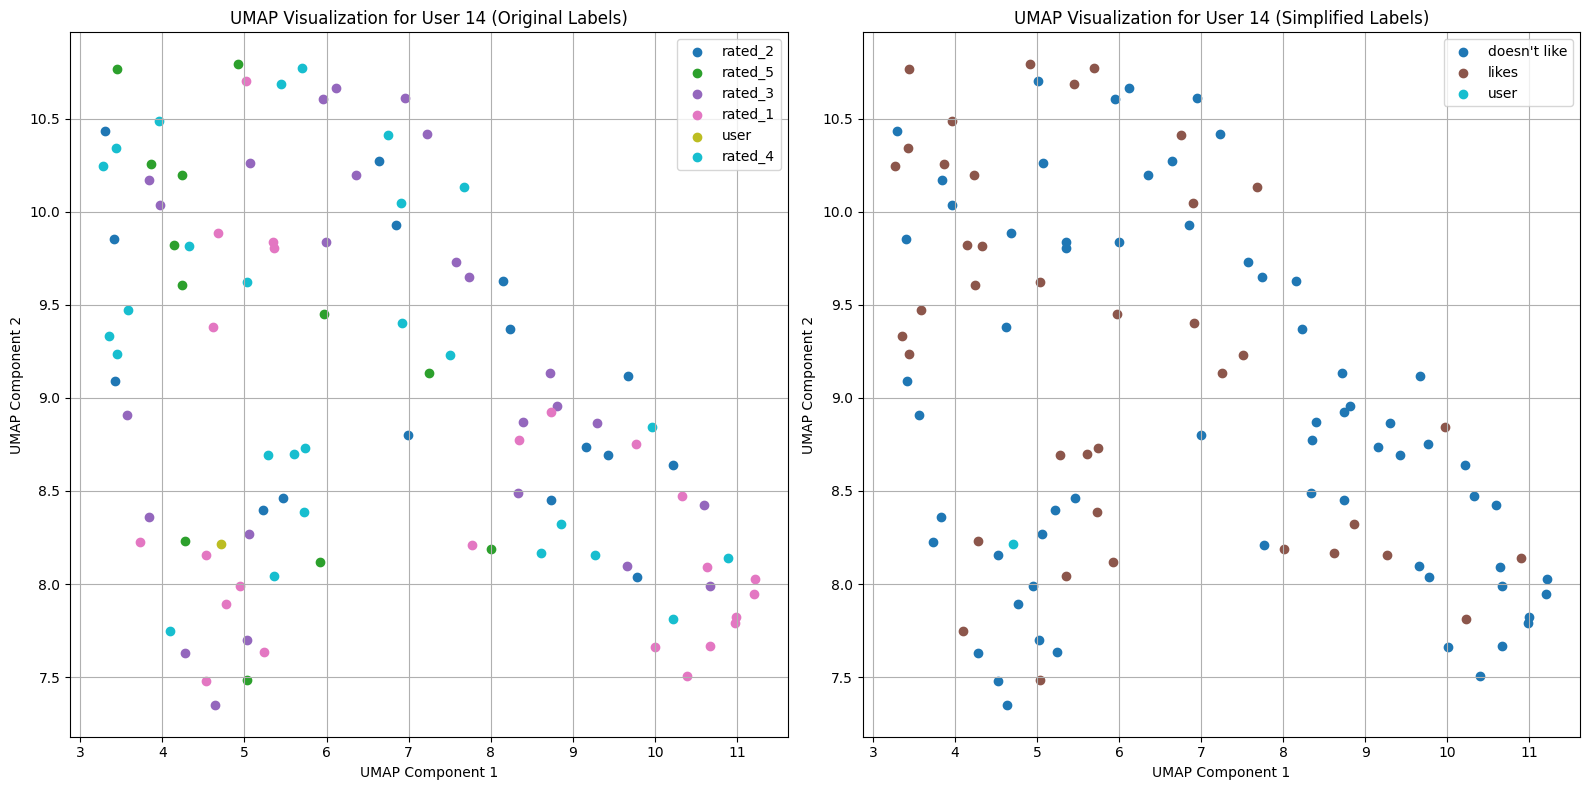

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


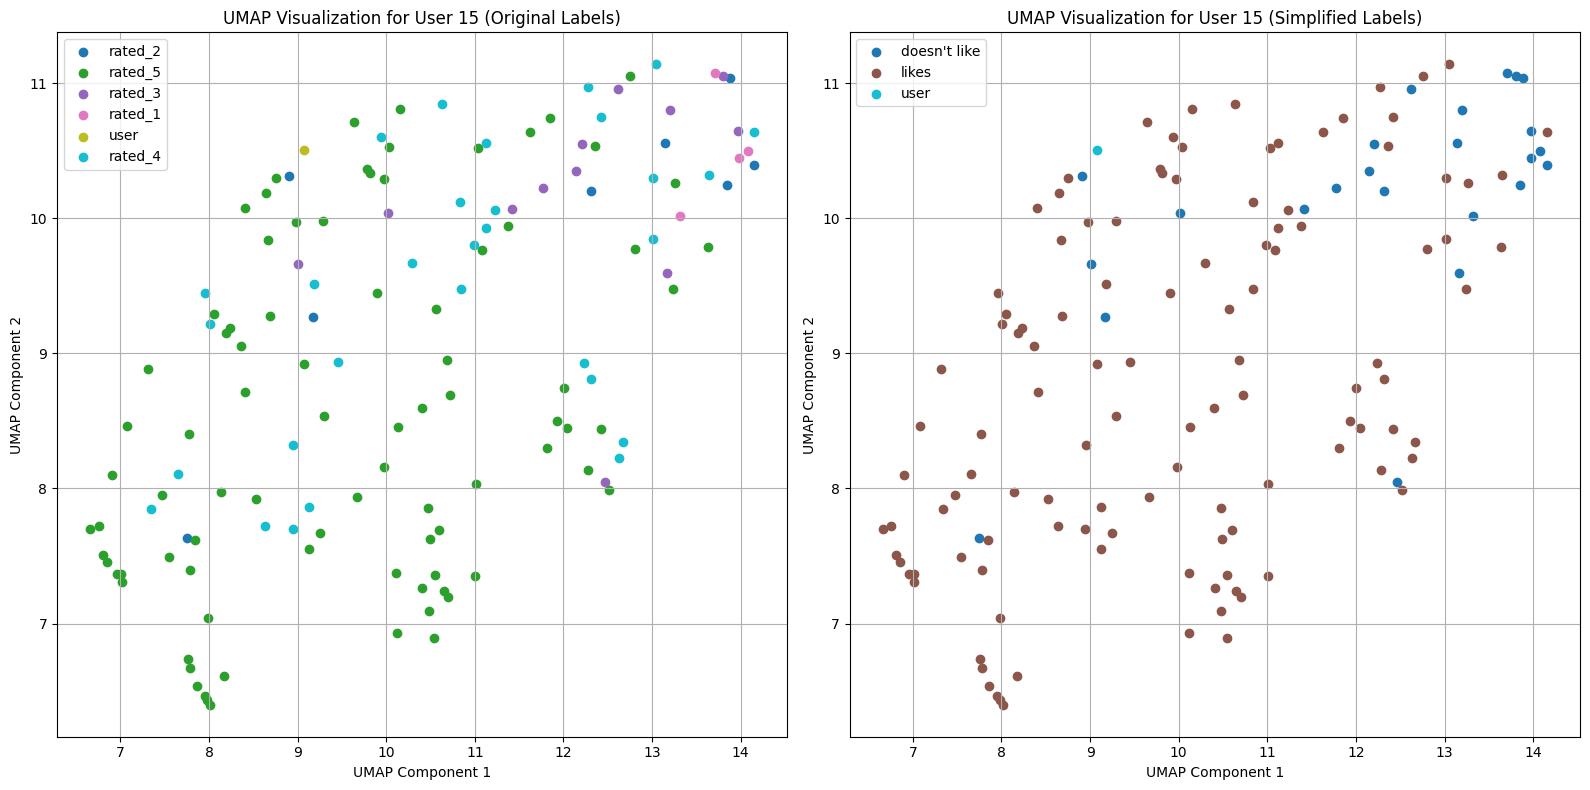

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


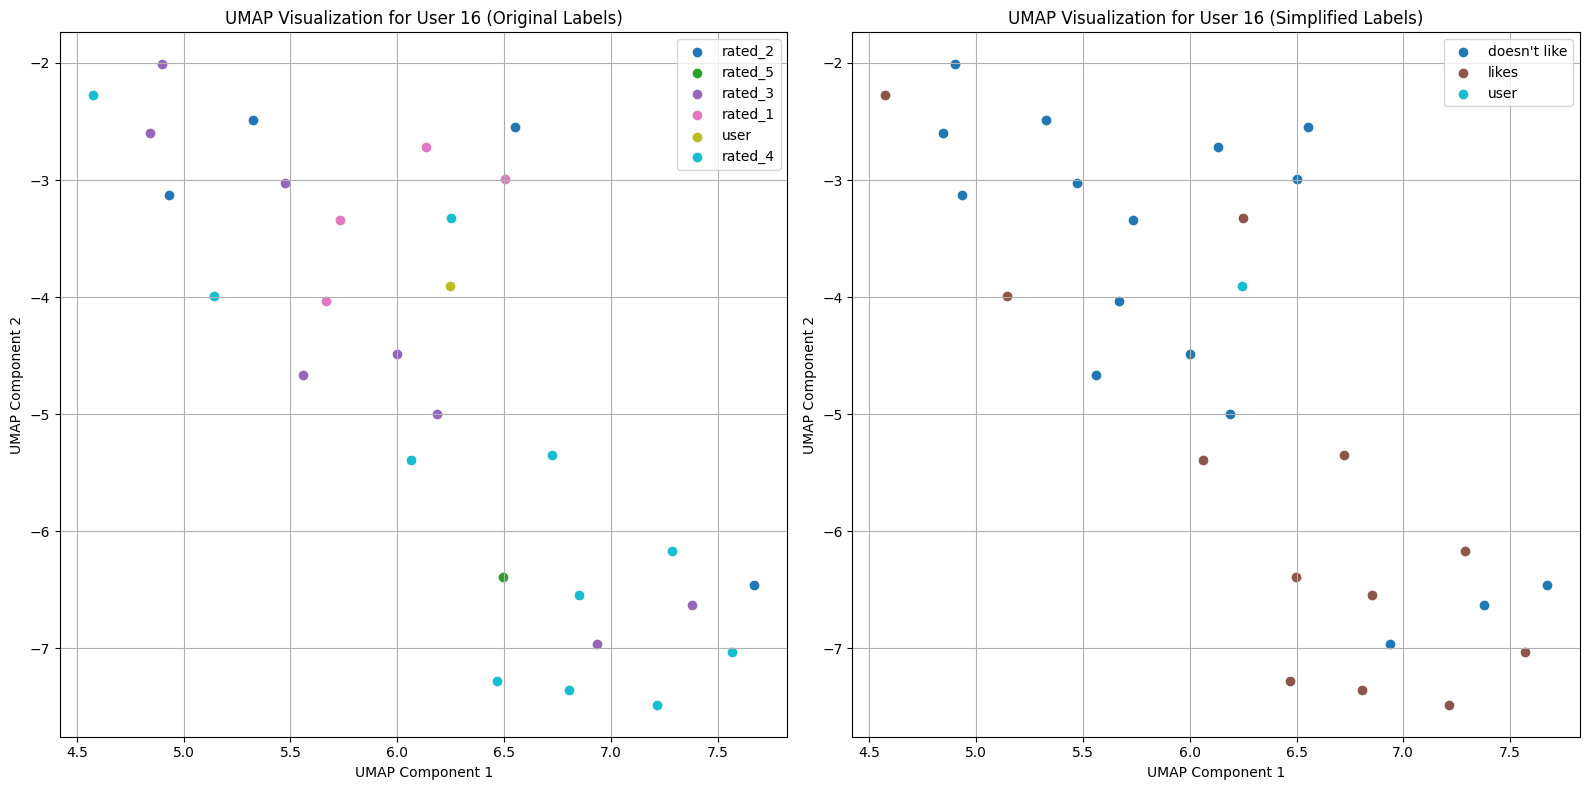

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


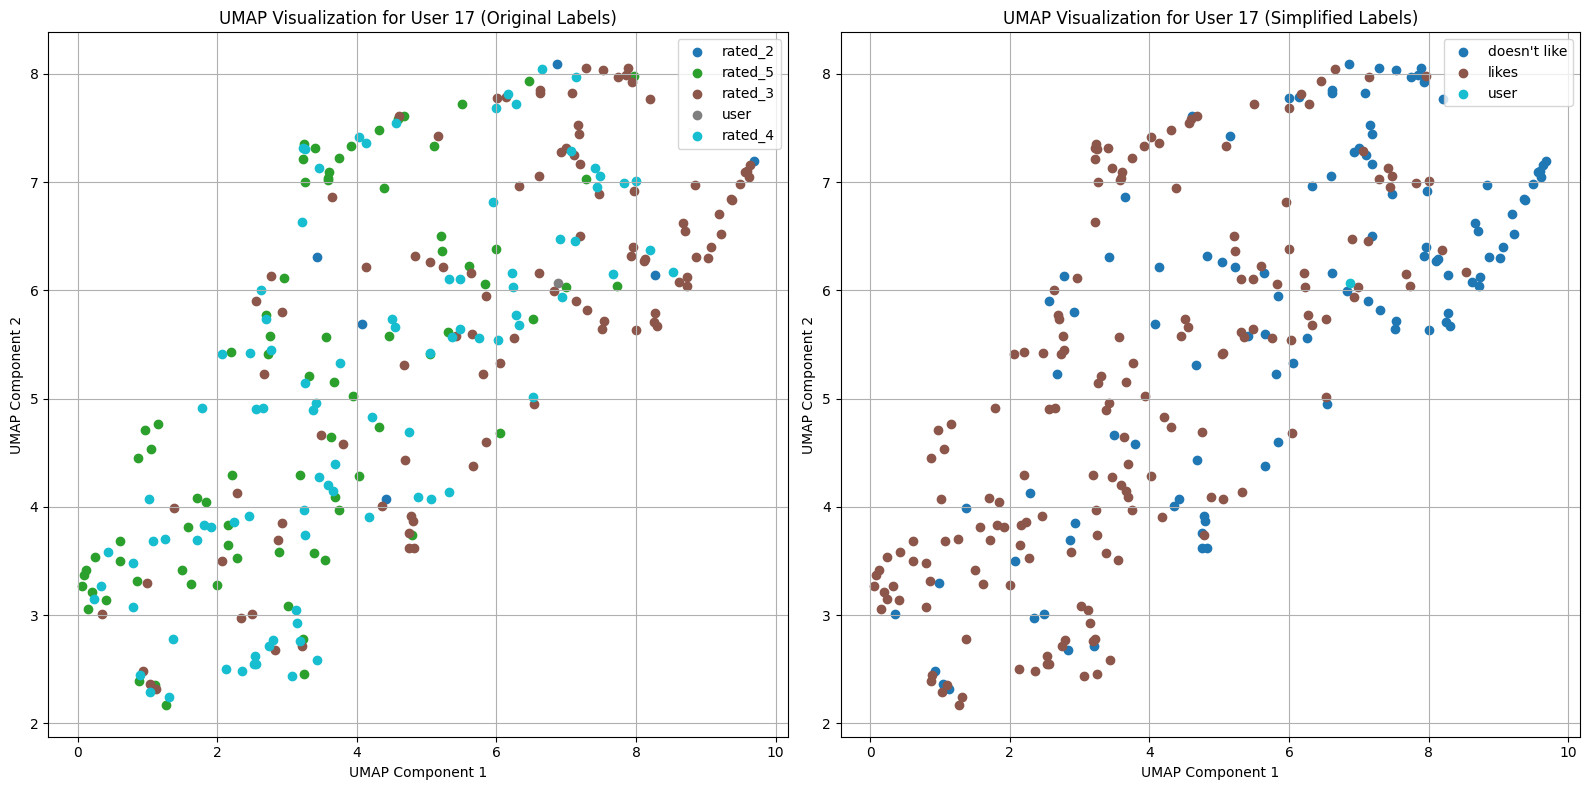

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


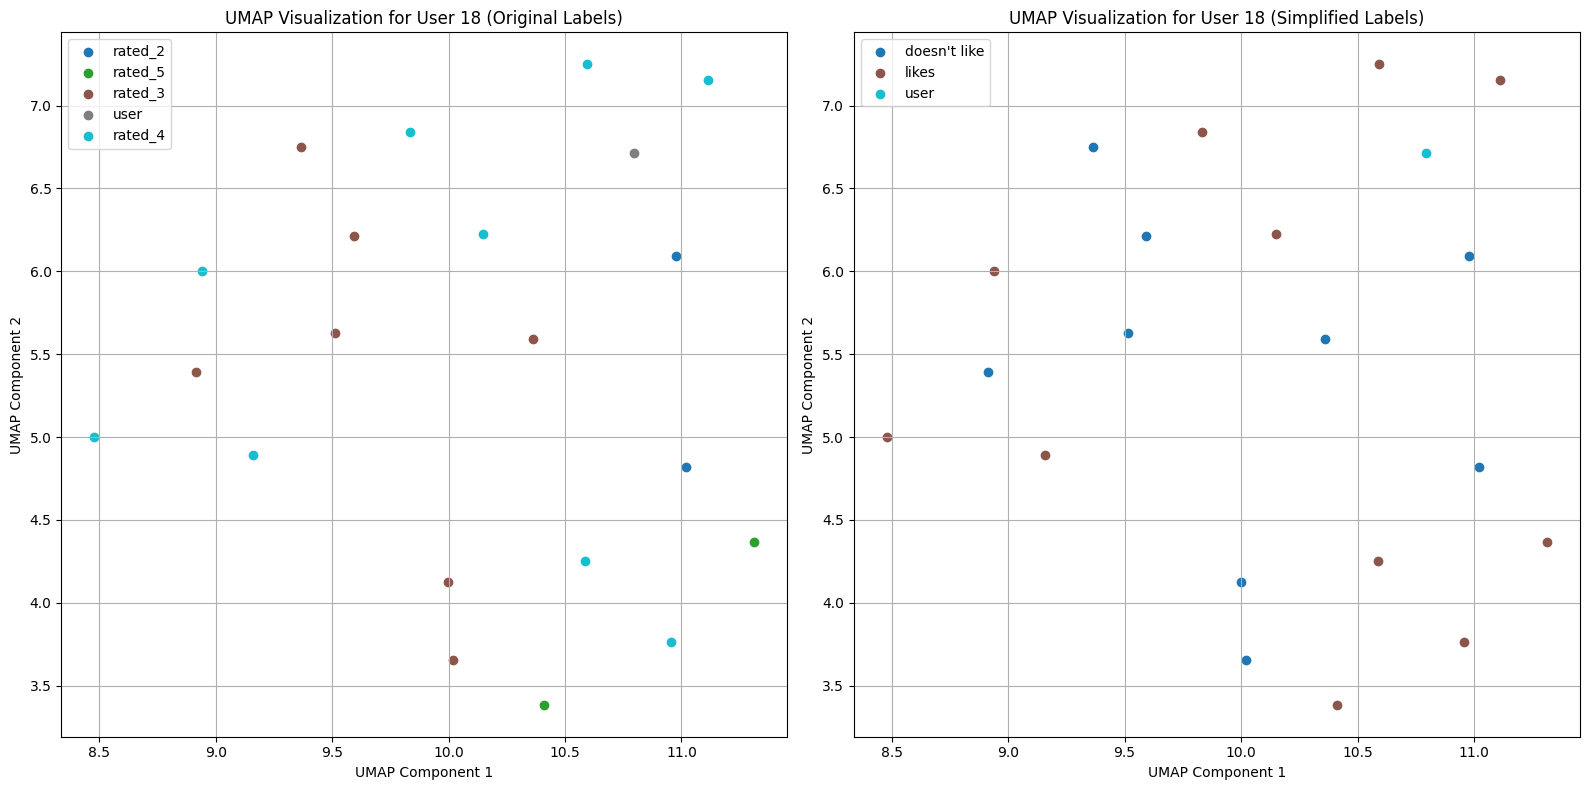

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


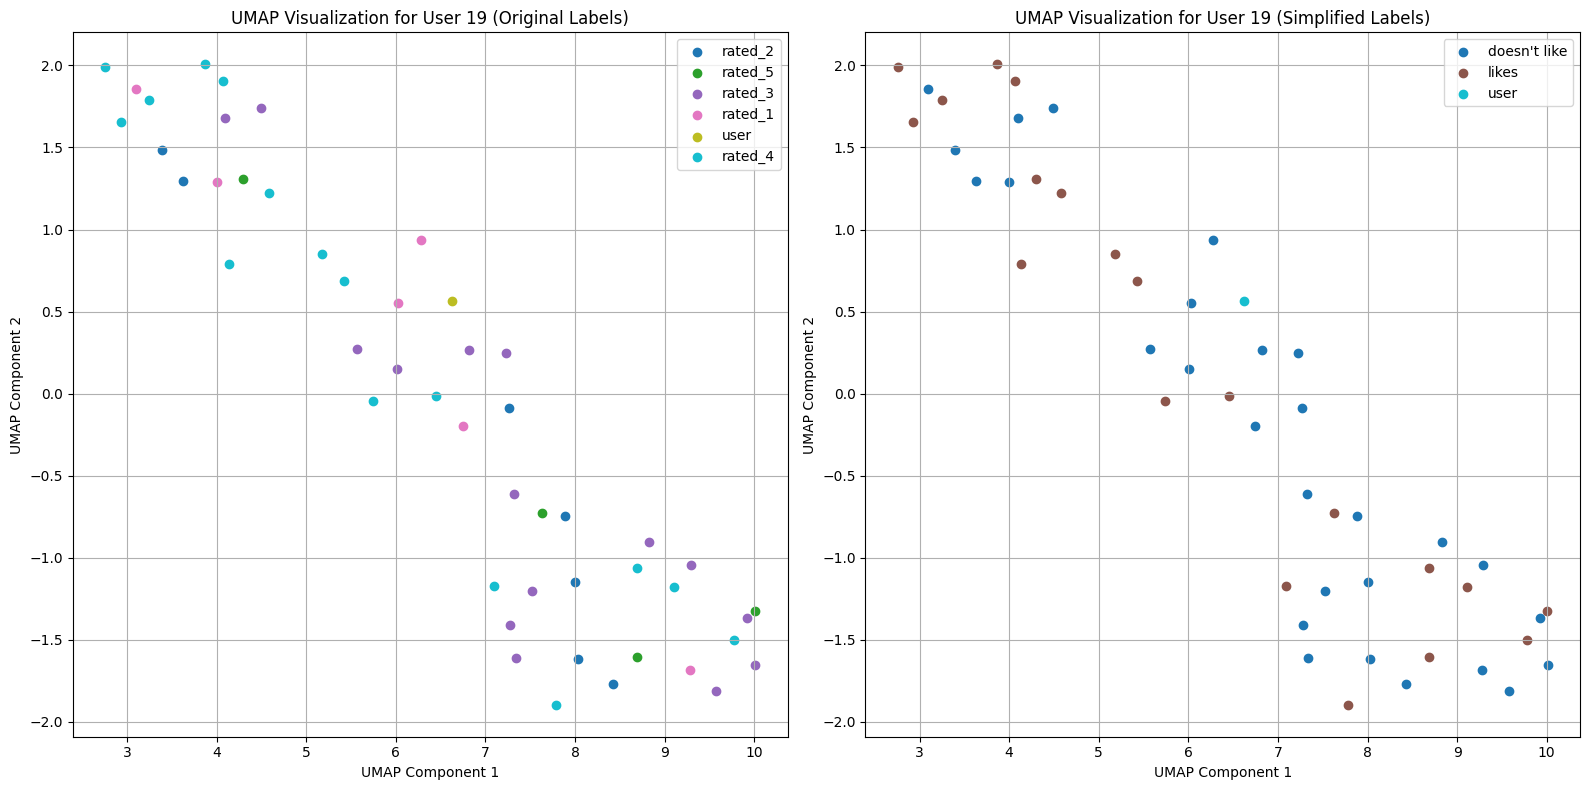

In [63]:
for i in range(20):
    visualize_user_movie_embeddings(i, llm_embedding_rating, movie_embedding_rating, aggregated_df)

In [57]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from umap import UMAP

def visualize_user_movie_embeddings(user_id, user_embedding, movie_embedding, user_embedding_2, movie_embedding_2, dataframe):
    def process_embeddings(user_embedding, movie_embedding):
        user_embed = user_embedding[user_id].numpy()

        rated_movies = {
            f"rated_{i}": np.array([int(movie) for movie in dataframe.loc[user_id, f"movies_rated_{i}"]])
            for i in range(1, 6)
        }

        embeddings = [user_embed]  # Start with the user embedding
        labels = ["user"]  # Label for the user embedding

        for rating, movies in rated_movies.items():
            if len(movies) > 0:
                movie_embeds = movie_embedding[movies].numpy()
                embeddings.append(movie_embeds)
                labels.extend(["likes" if i > 3 else "doesn't like" for i in [int(rating.split("_")[1])] * len(movies)])

        embeddings = np.vstack(embeddings)

        return embeddings, labels
    reduced_embeddings_1, labels_1 = process_embeddings(user_embedding, movie_embedding)
    reduced_embeddings_2, labels_2 = process_embeddings(user_embedding_2, movie_embedding_2)

    transformed_embeddings_1 = UMAP(n_components=2, random_state=42).fit_transform(reduced_embeddings_1)
    transformed_embeddings_2 = UMAP(n_components=2, random_state=42).fit_transform(reduced_embeddings_2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    unique_labels_1 = set(labels_1)
    colors_1 = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_1)))
    label_color_map_1 = dict(zip(unique_labels_1, colors_1))

    for label in unique_labels_1:
        indices = [i for i, l in enumerate(labels_1) if l == label]
        axes[0].scatter(
            transformed_embeddings_1[indices, 0],
            transformed_embeddings_1[indices, 1],
            label=label,
            color=label_color_map_1.get(label, "gray"),
        )

    axes[0].set_title(f"UMAP Visualization for User {user_id} (Binary)")
    axes[0].set_xlabel("UMAP Component 1")
    axes[0].set_ylabel("UMAP Component 2")
    axes[0].legend()
    axes[0].grid(True)
    unique_labels_2 = set(labels_2)
    colors_2 = plt.cm.tab10(np.linspace(0, 1, len(unique_labels_2)))
    label_color_map_2 = dict(zip(unique_labels_2, colors_2))

    for label in unique_labels_2:
        indices = [i for i, l in enumerate(labels_2) if l == label]
        axes[1].scatter(
            transformed_embeddings_2[indices, 0],
            transformed_embeddings_2[indices, 1],
            label=label,
            color=label_color_map_2.get(label, "gray"),
        )

    axes[1].set_title(f"UMAP Visualization for User {user_id} (Rating Classific.)")
    axes[1].set_xlabel("UMAP Component 1")
    axes[1].set_ylabel("UMAP Component 2")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


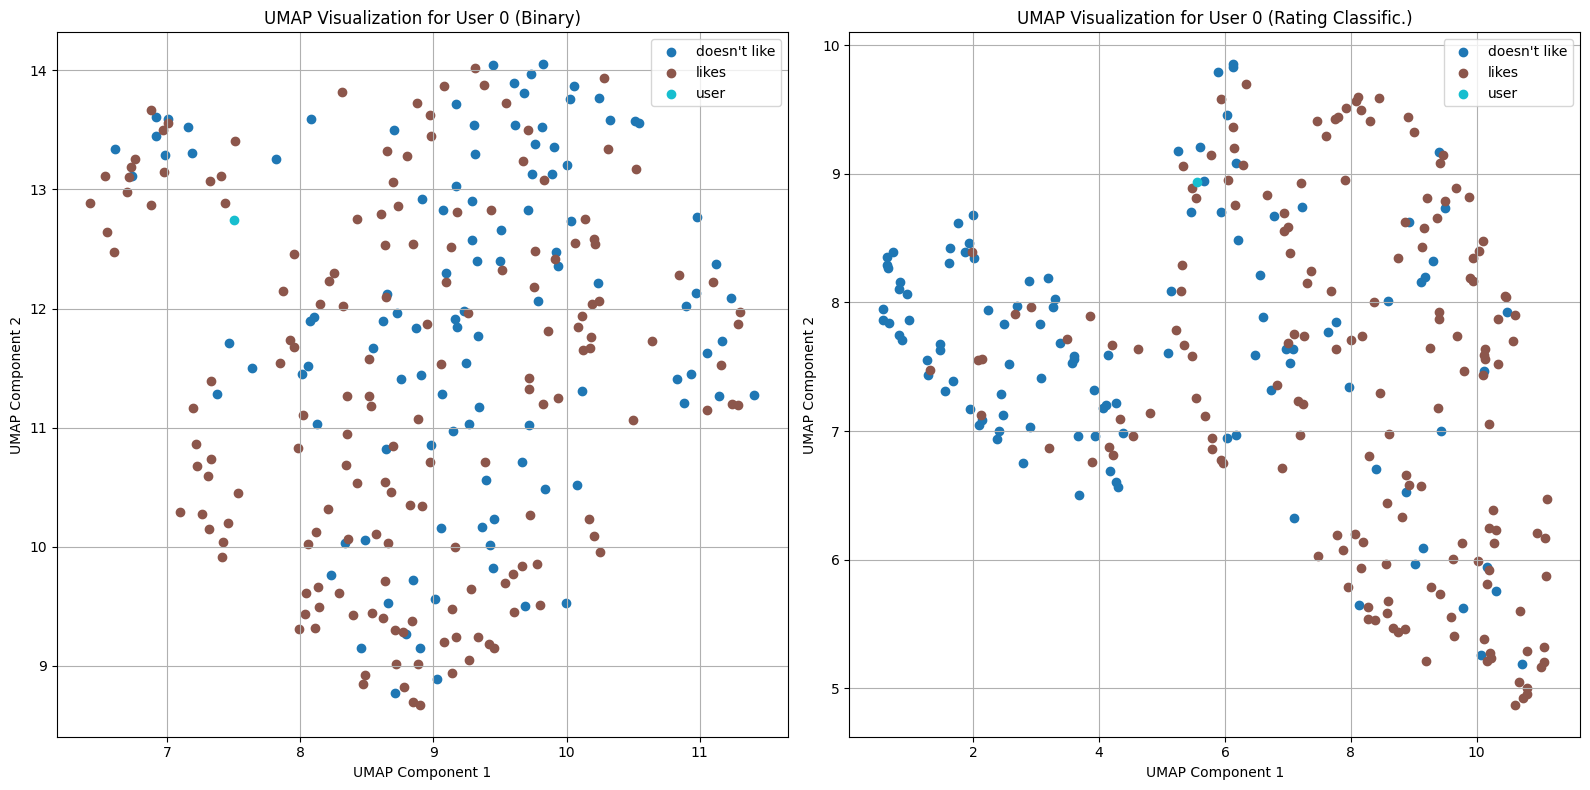

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


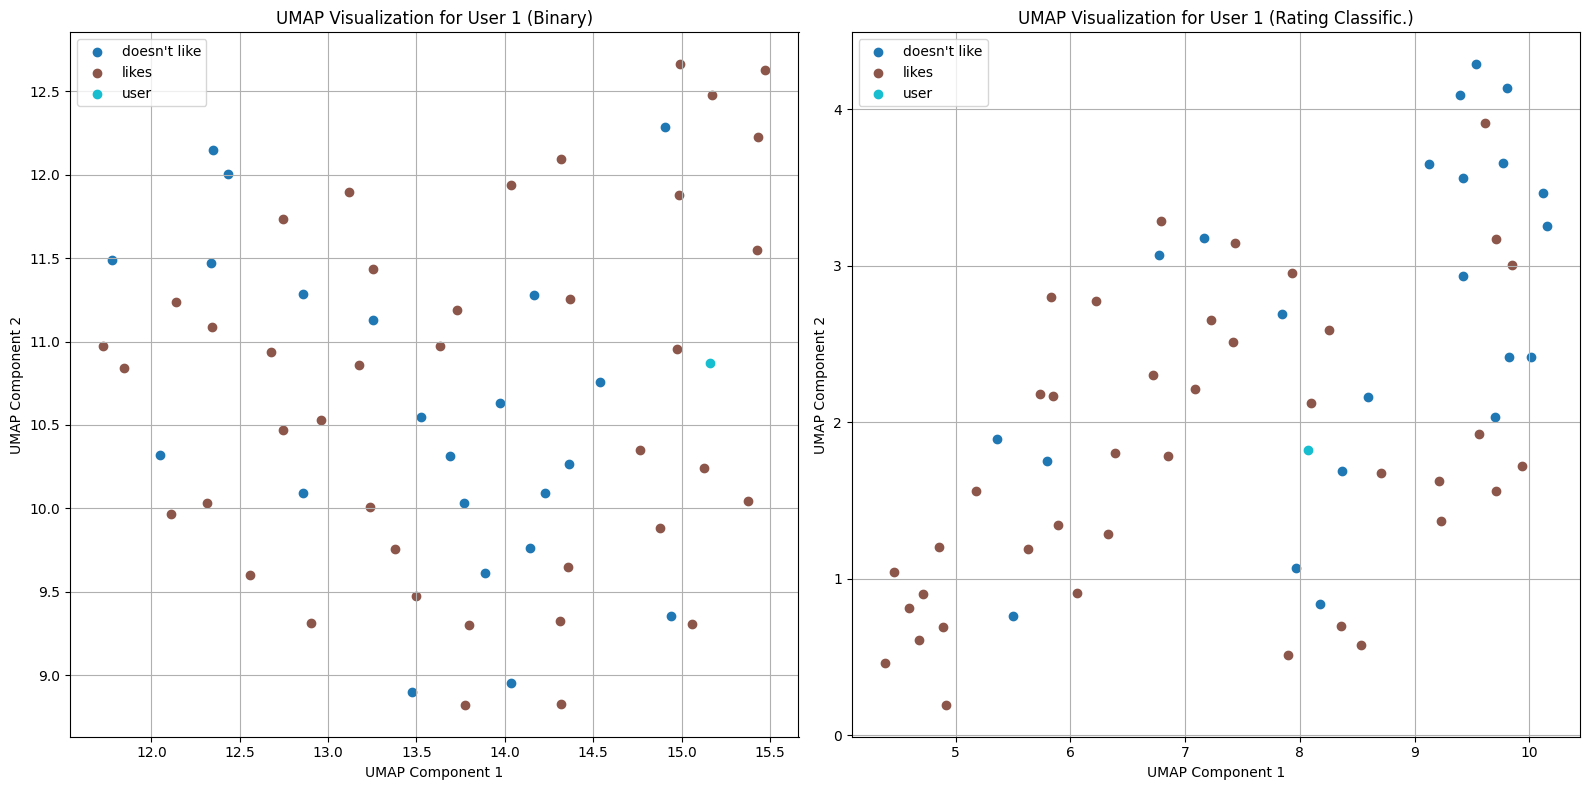

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


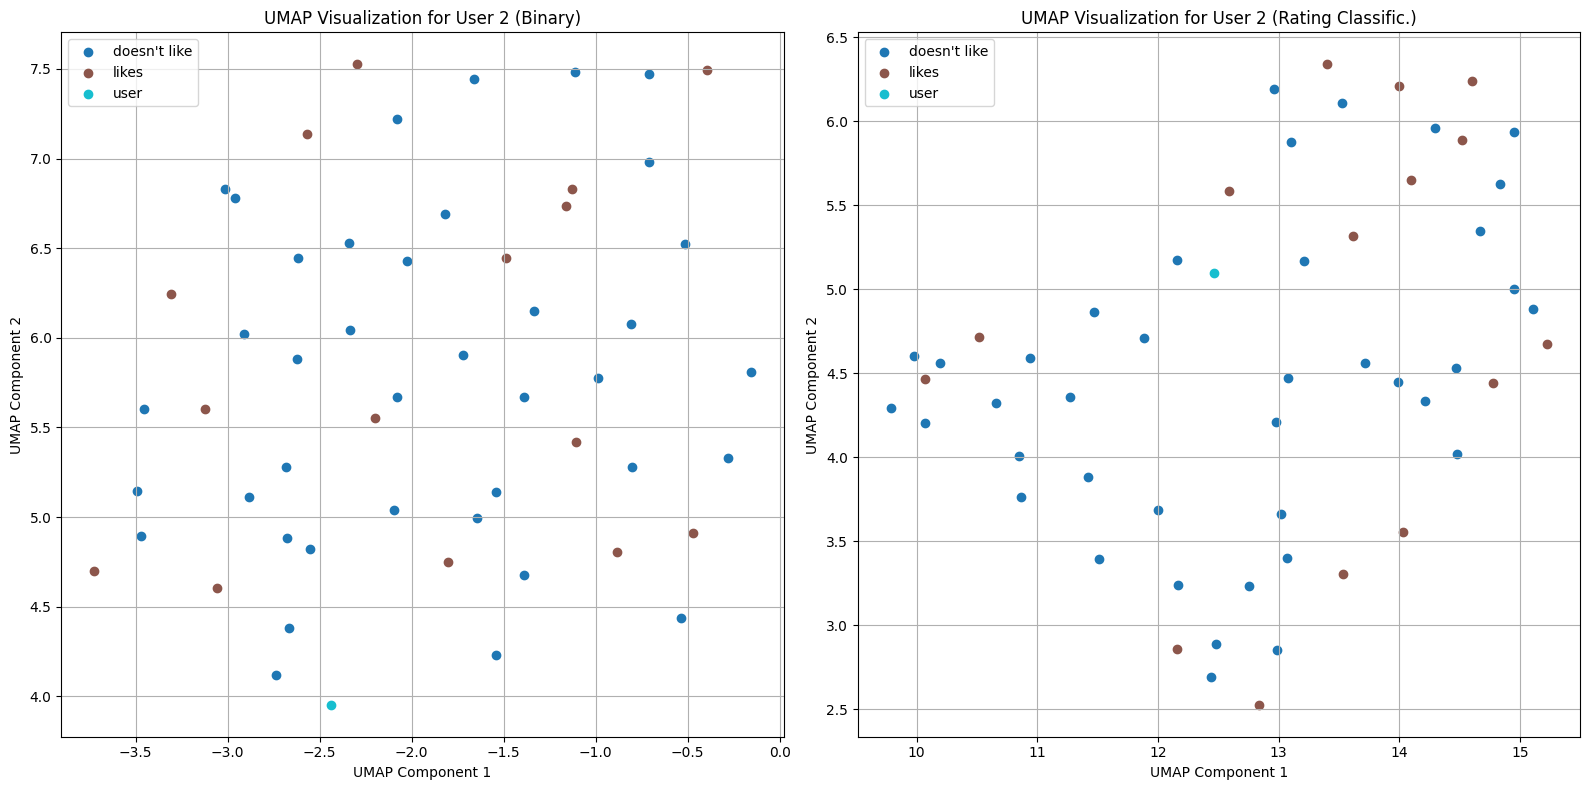

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


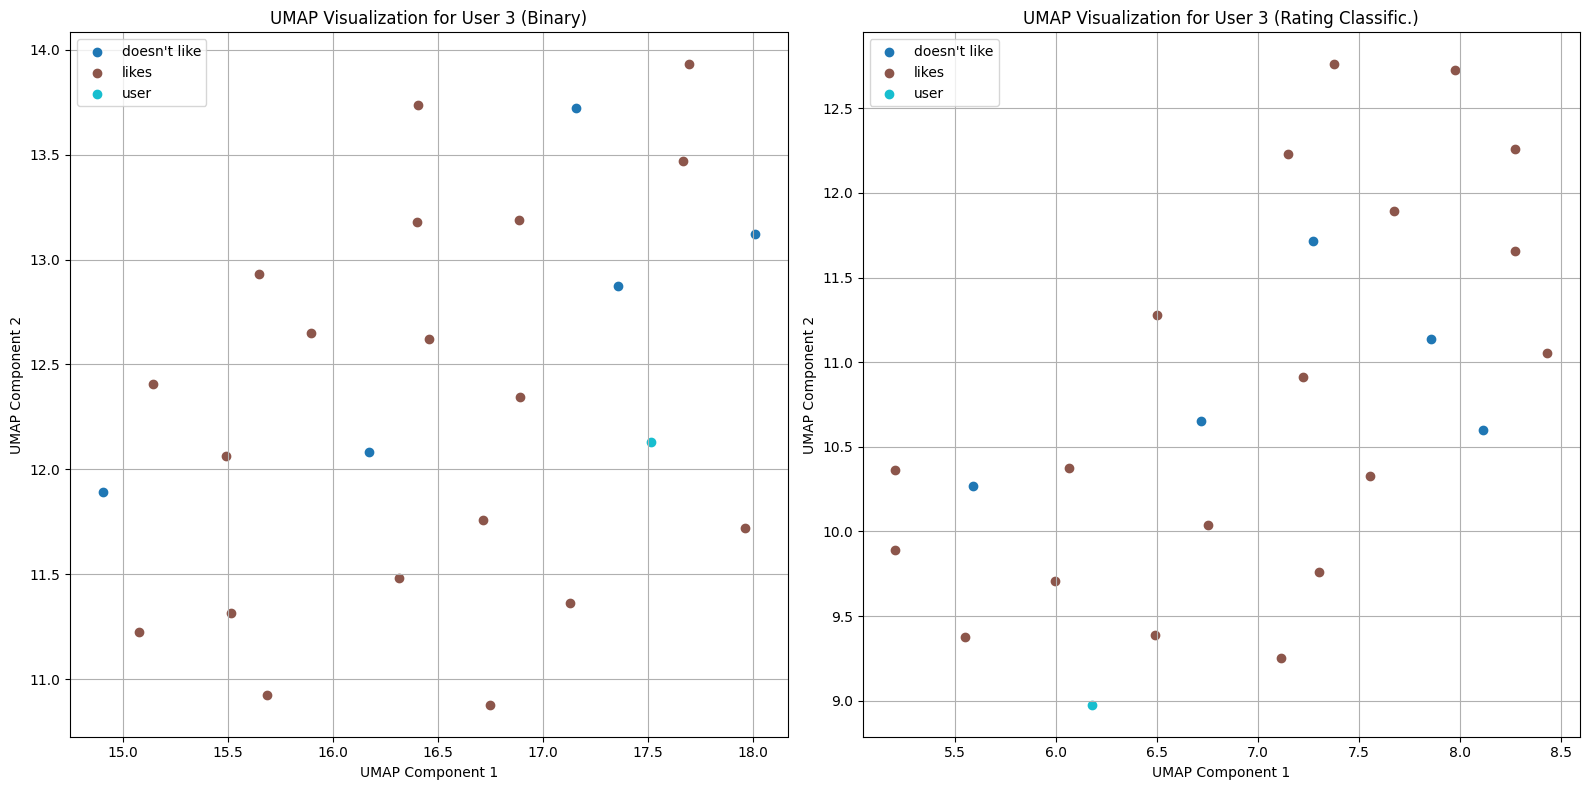

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


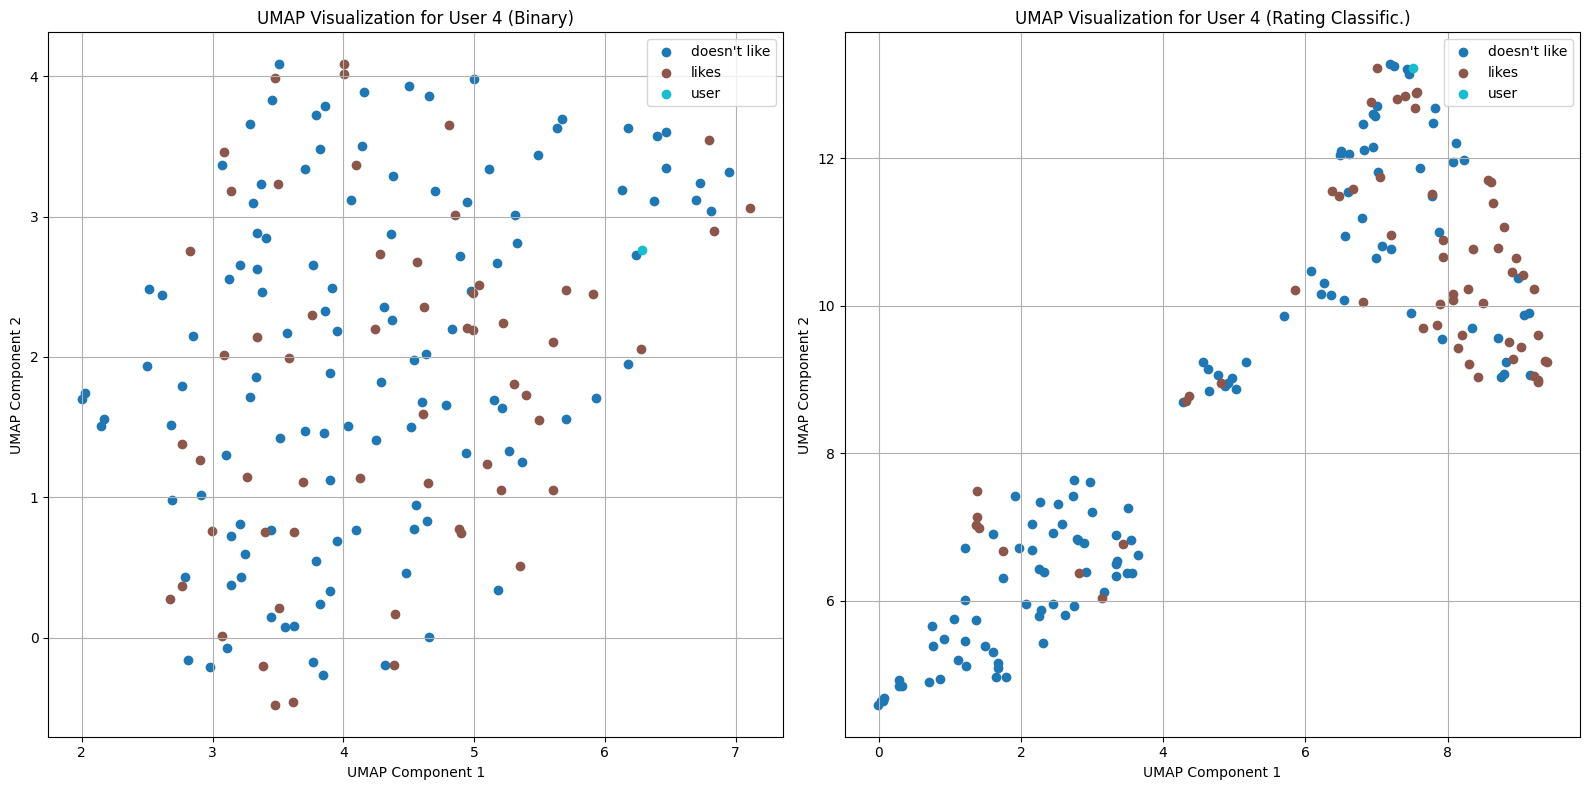

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


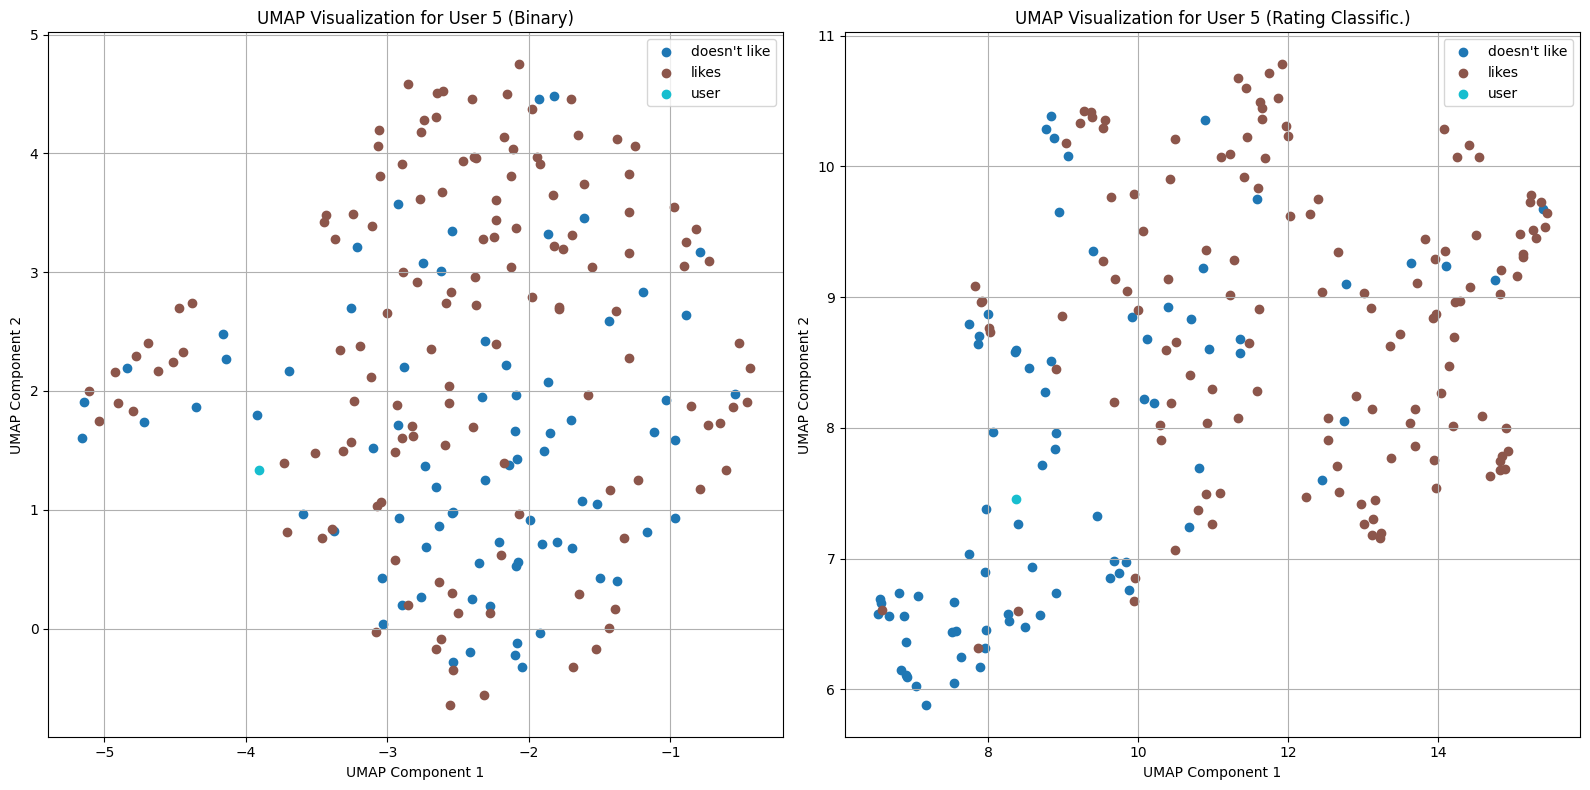

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


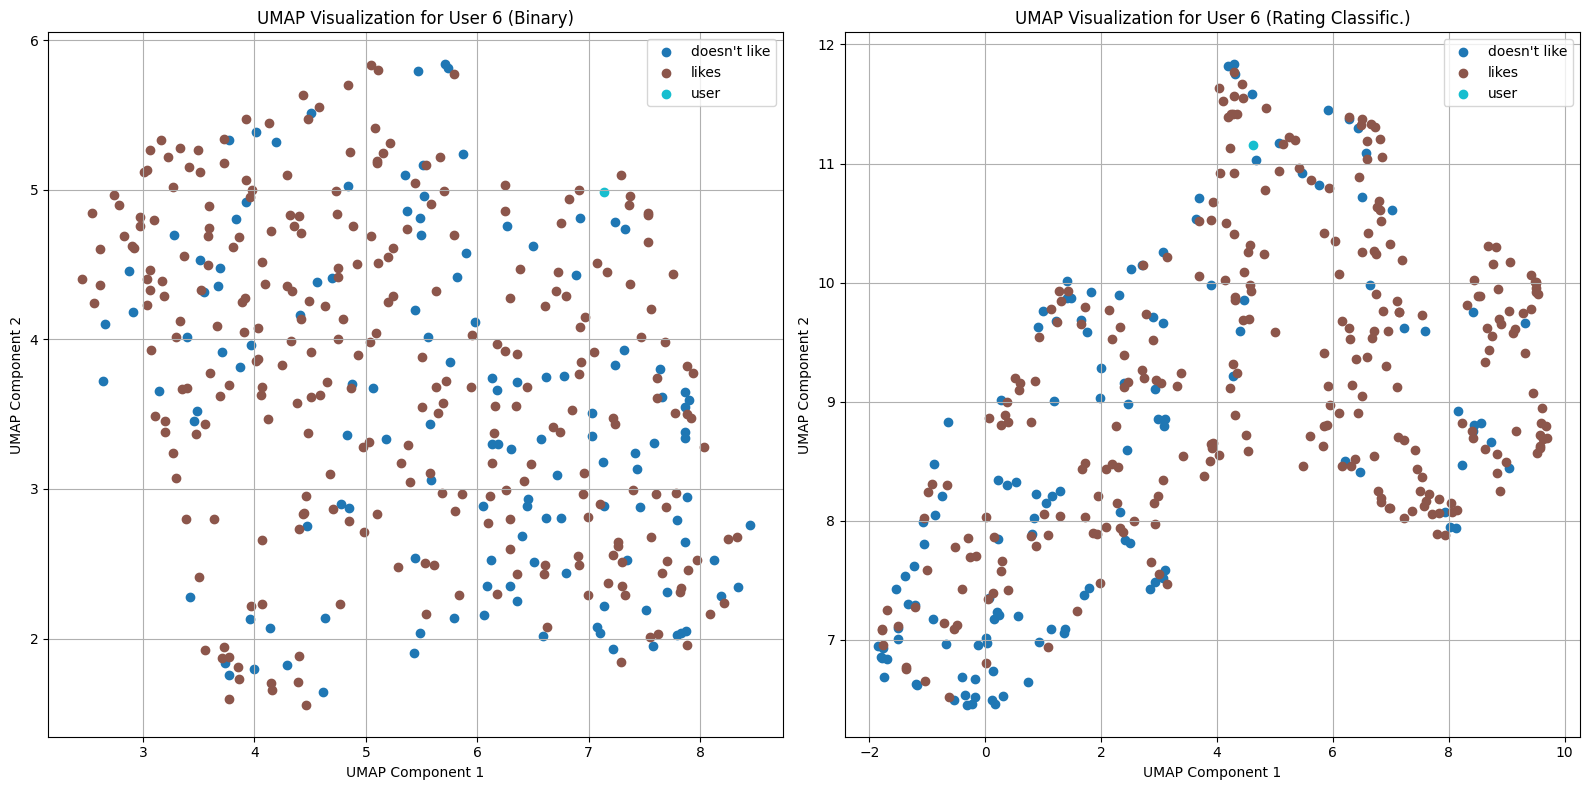

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


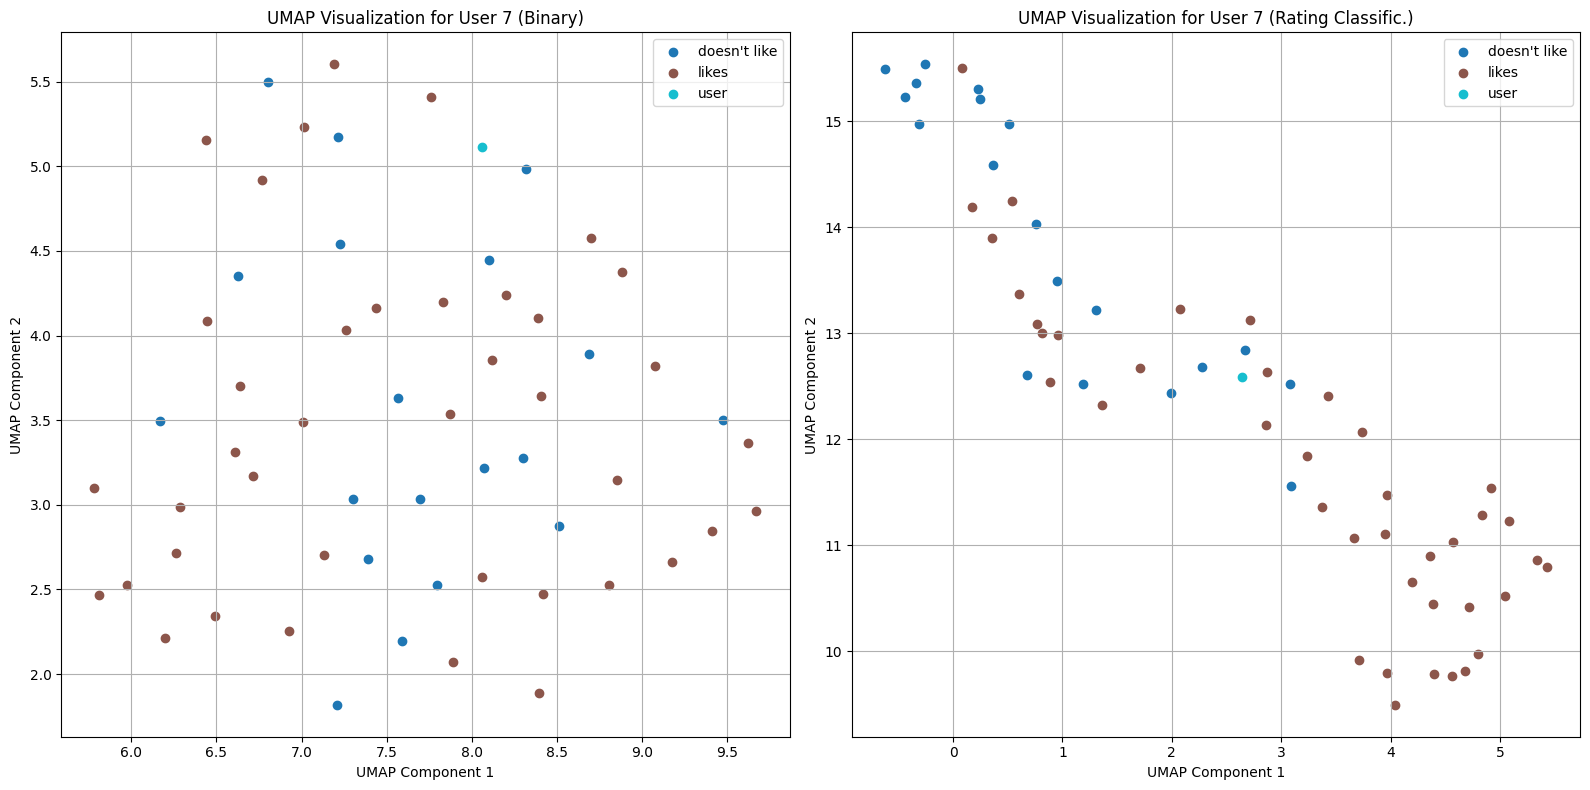

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


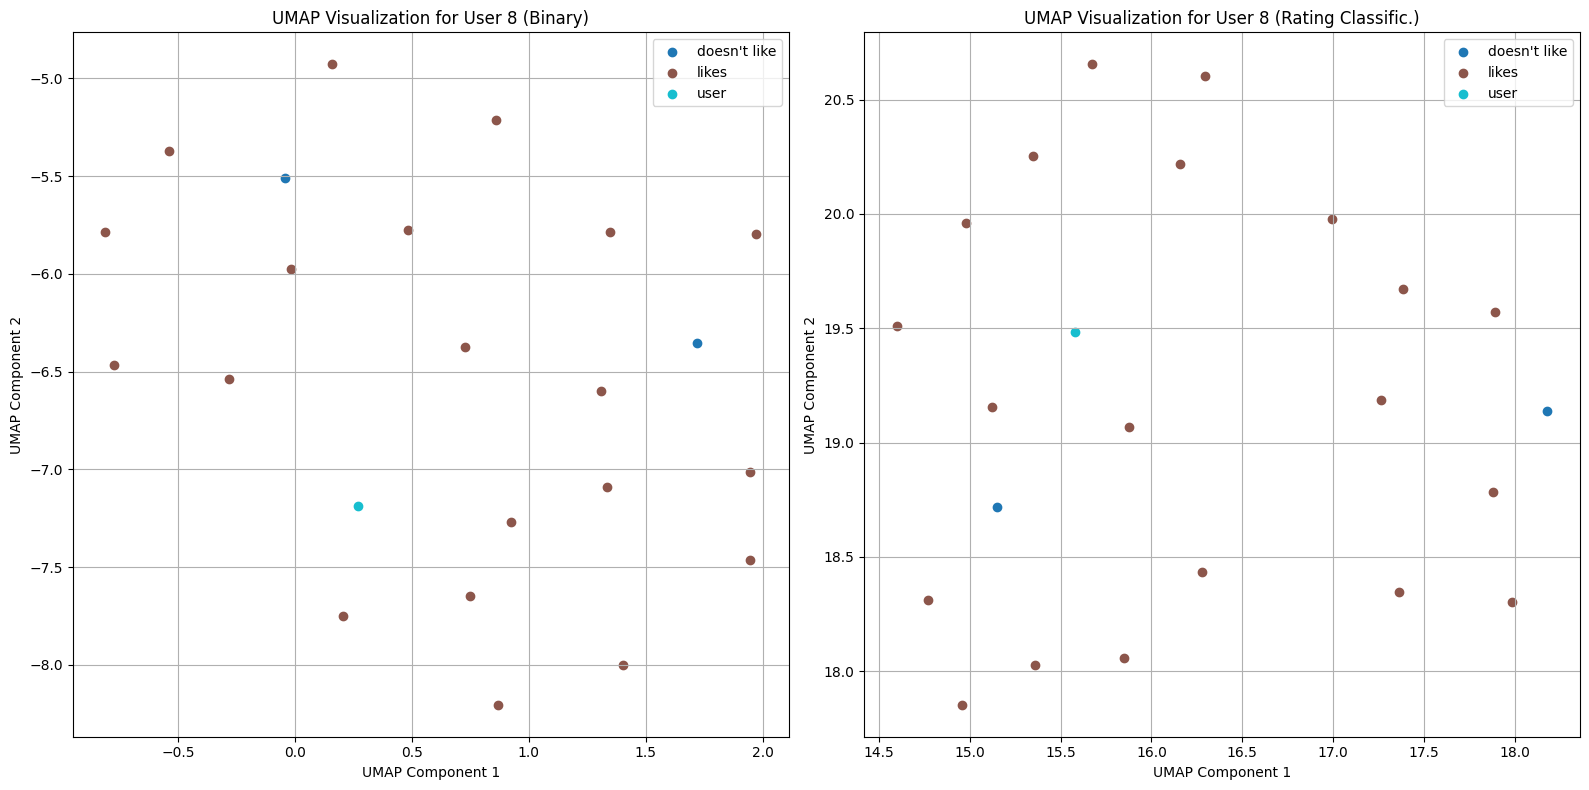

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


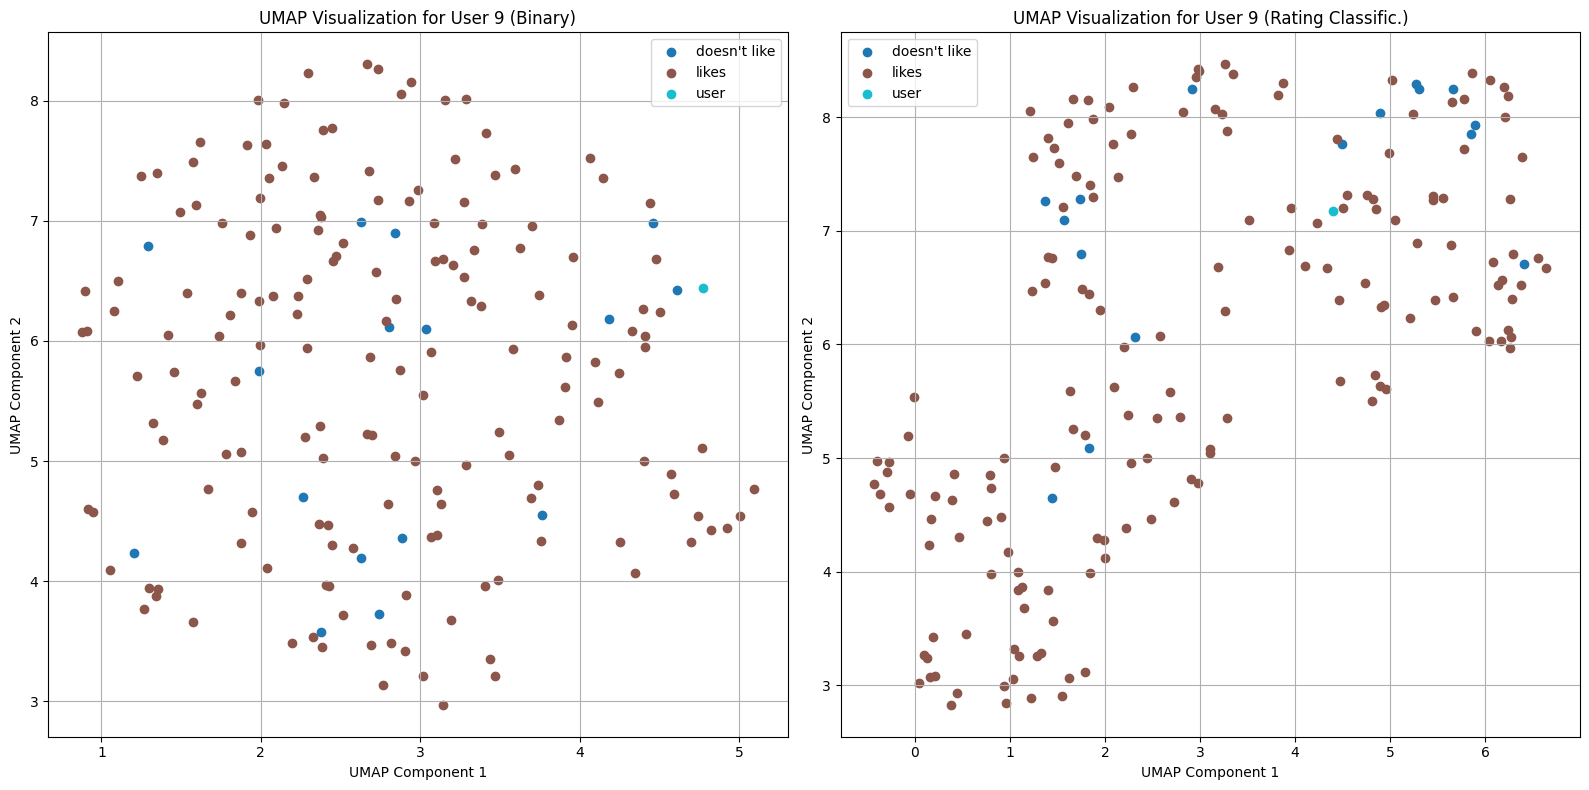

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


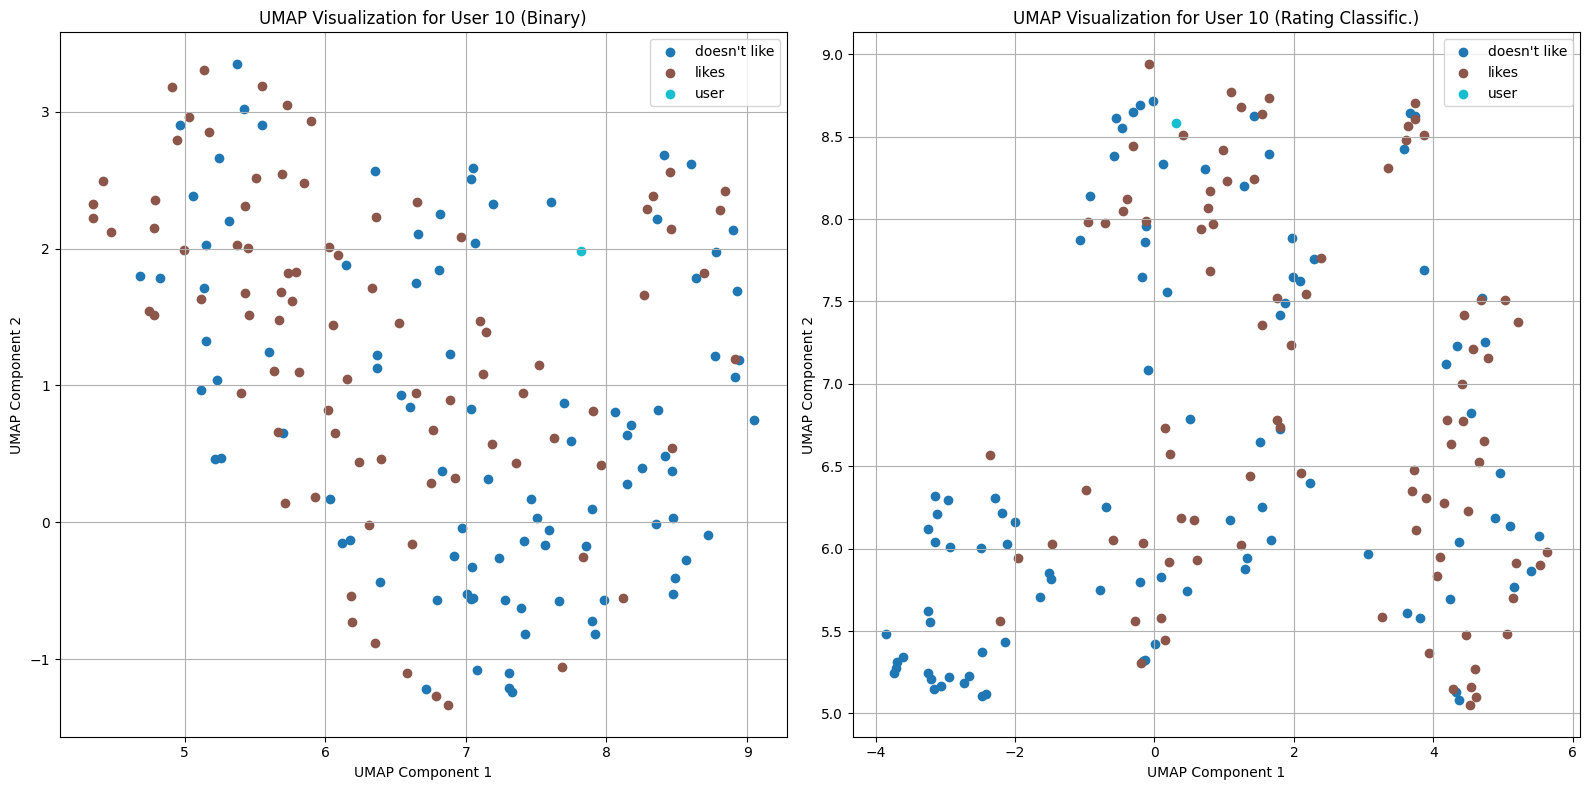

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


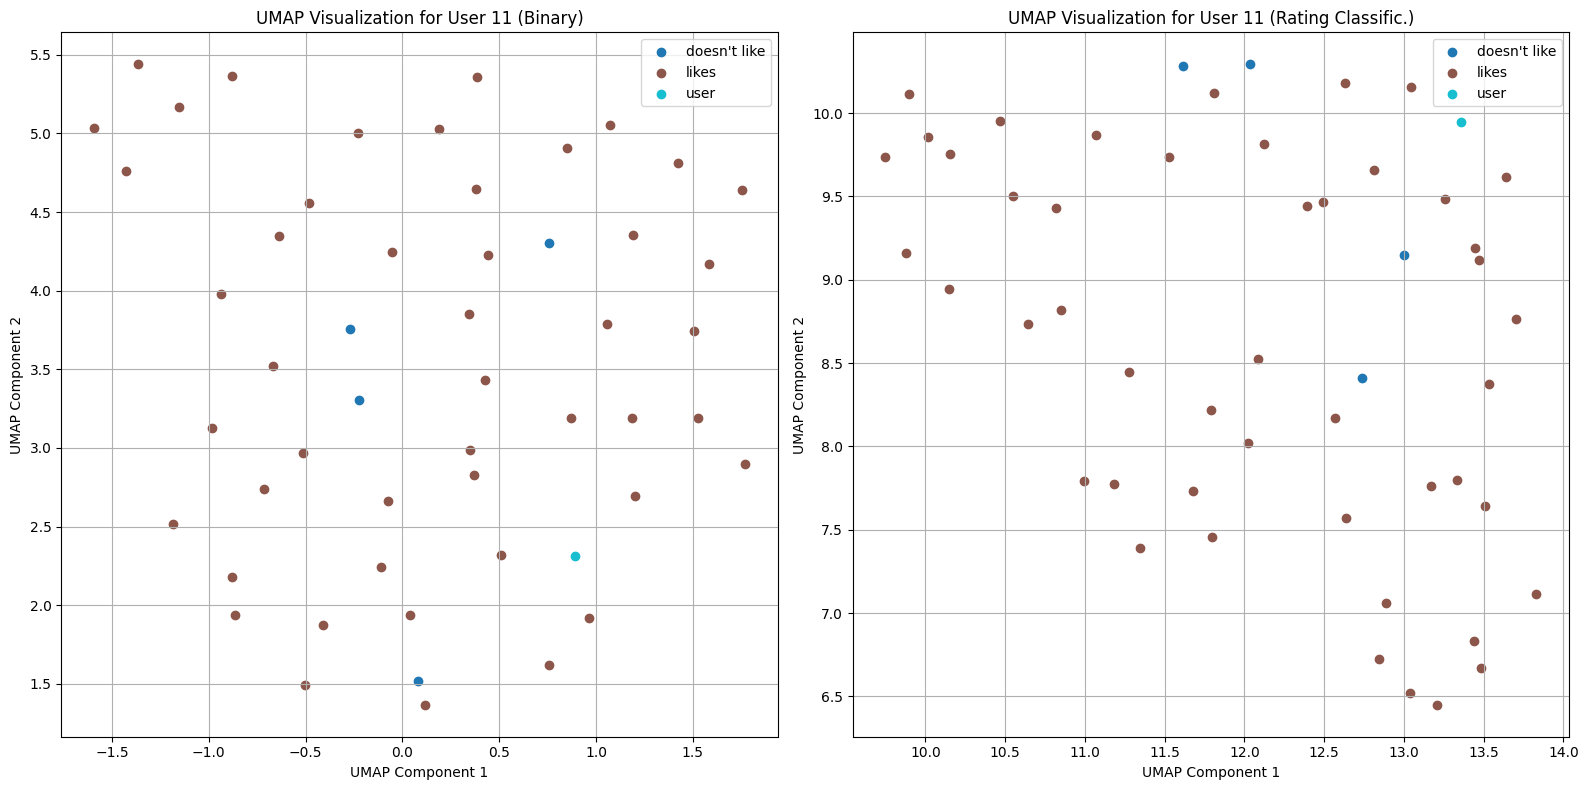

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


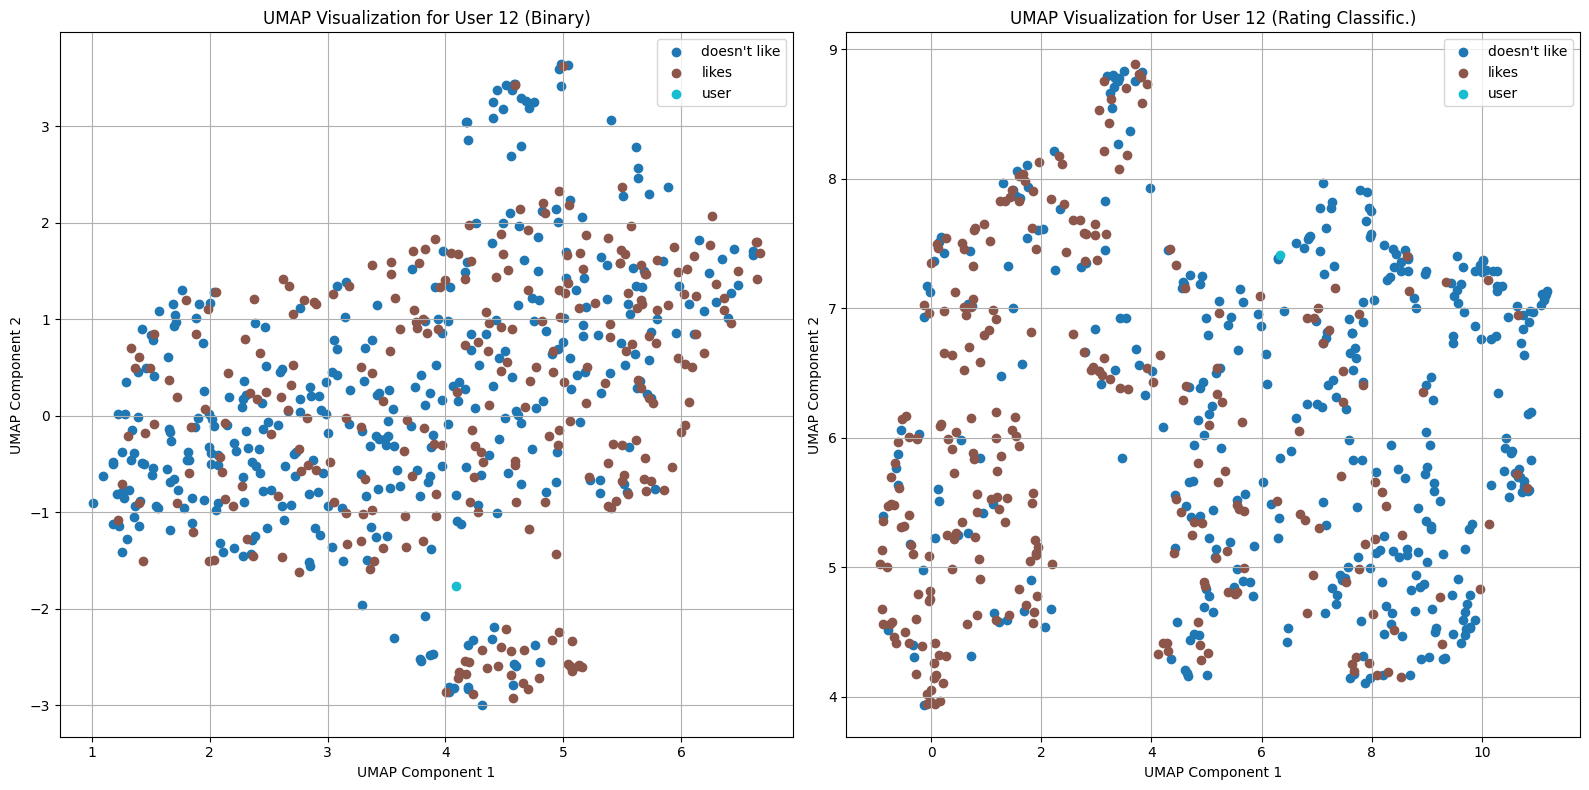

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


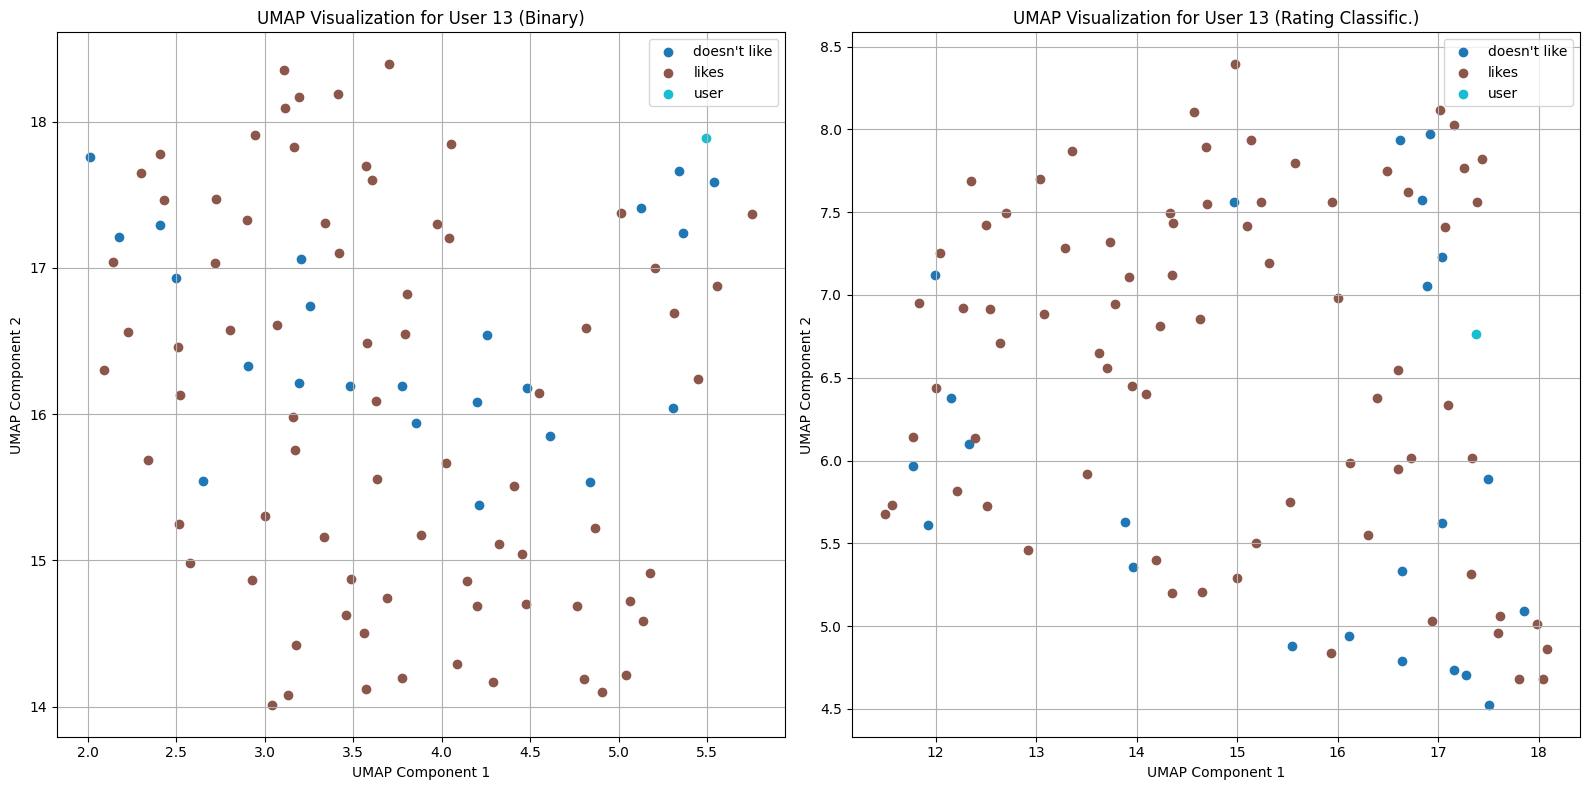

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


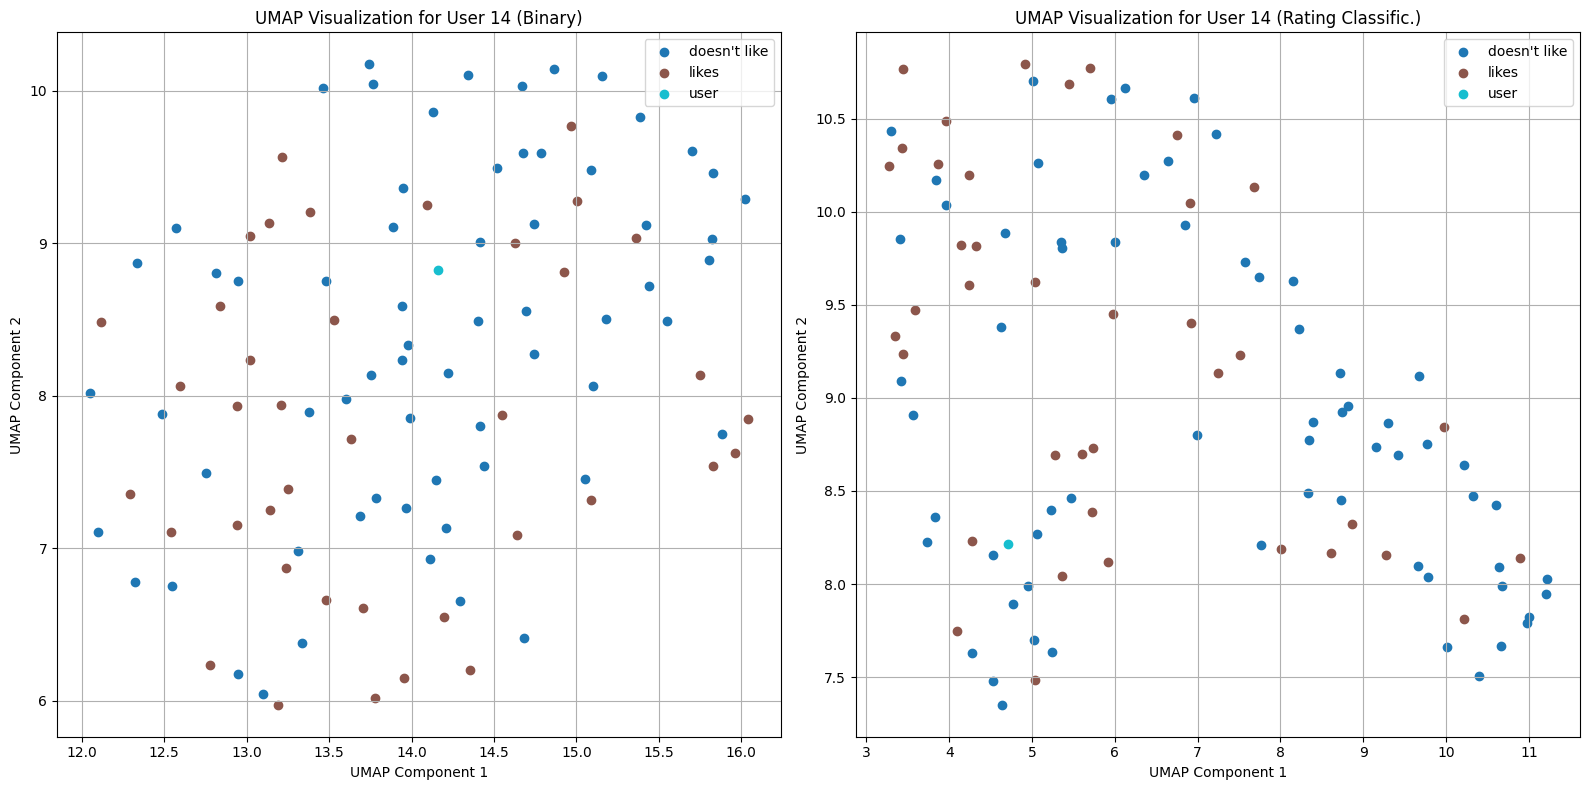

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


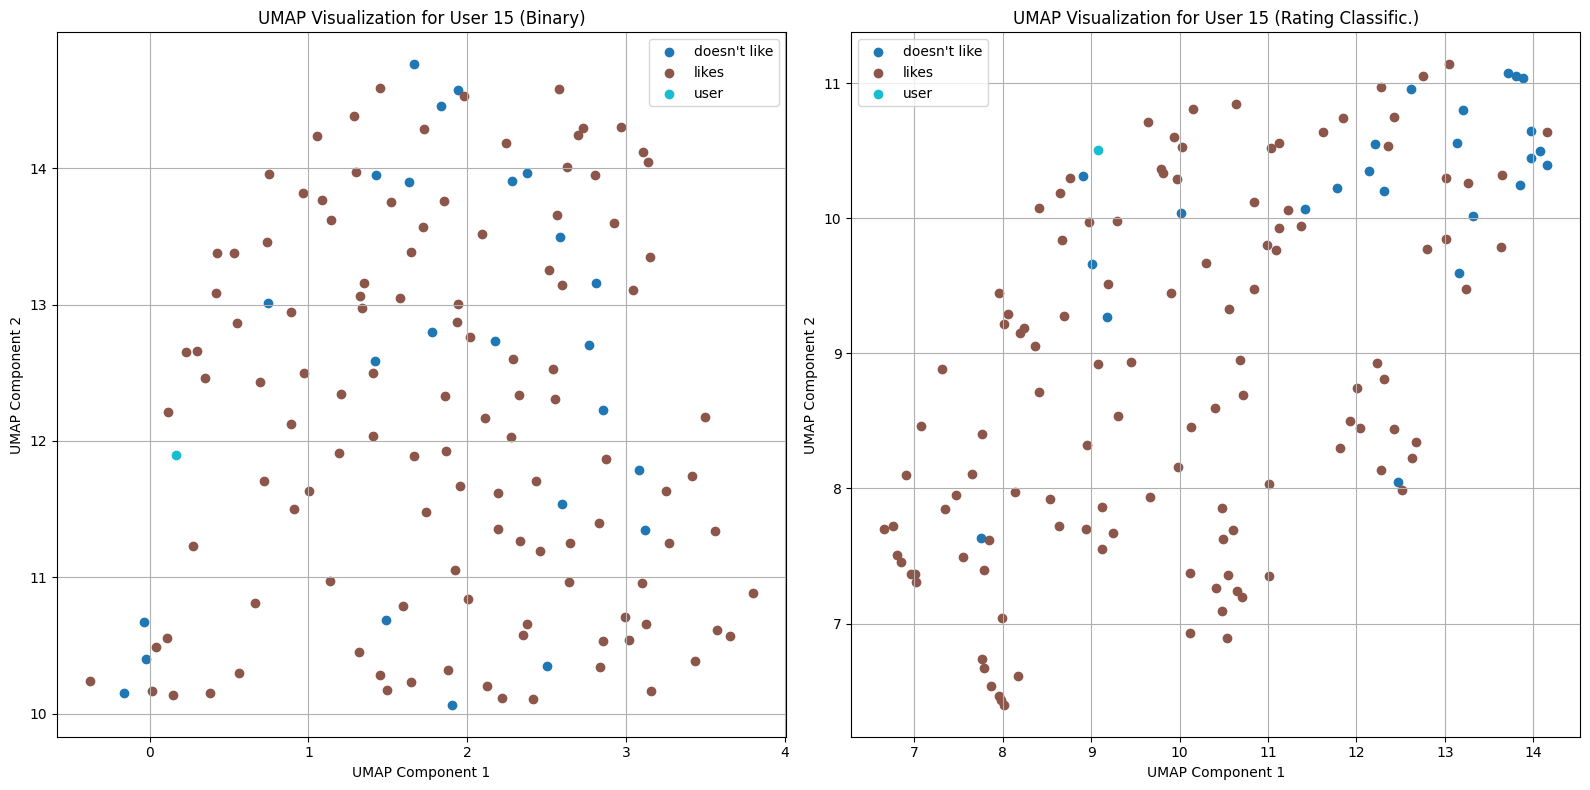

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


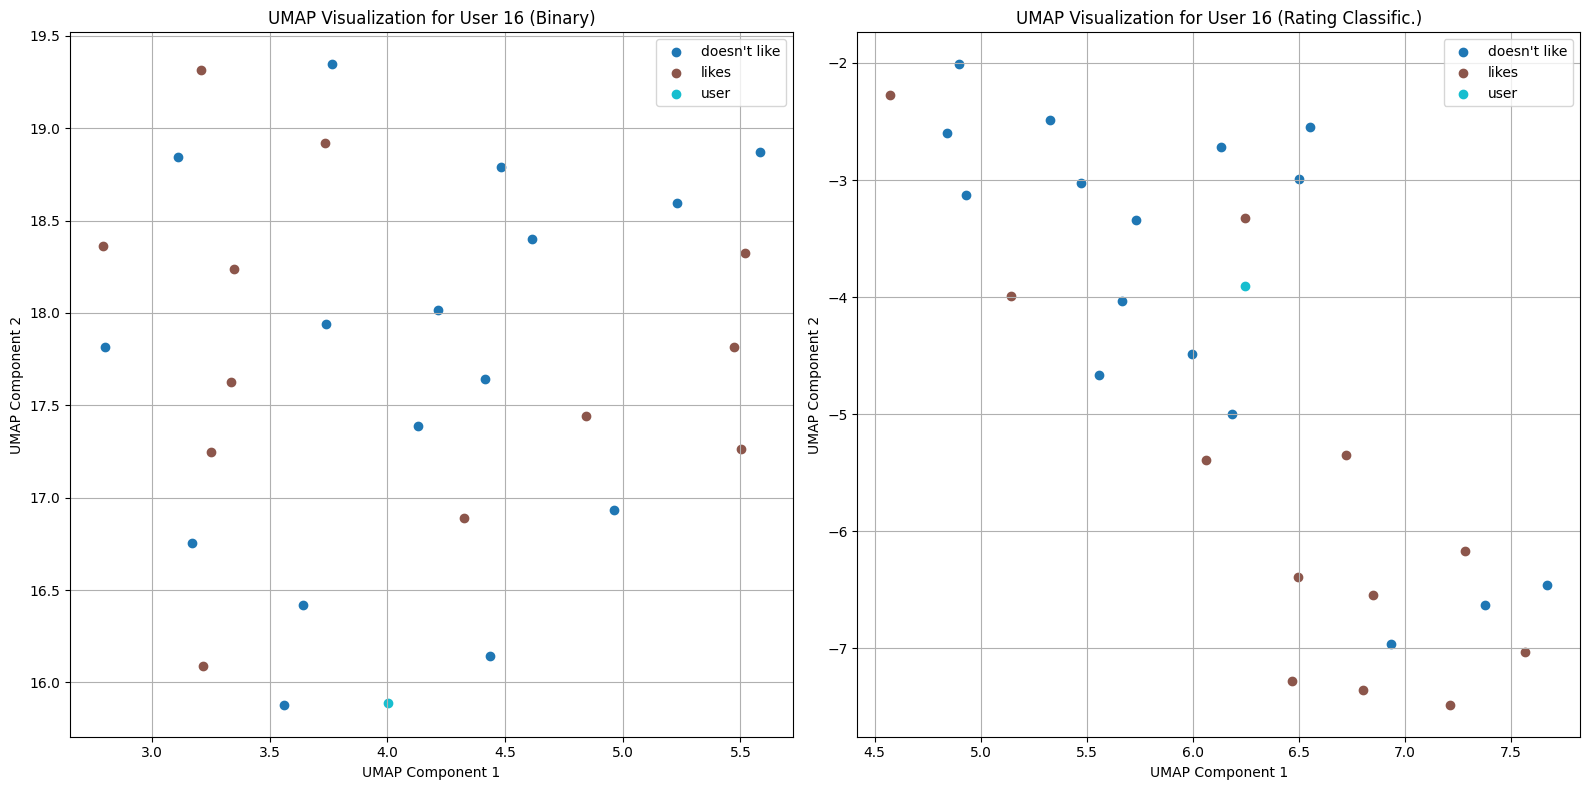

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


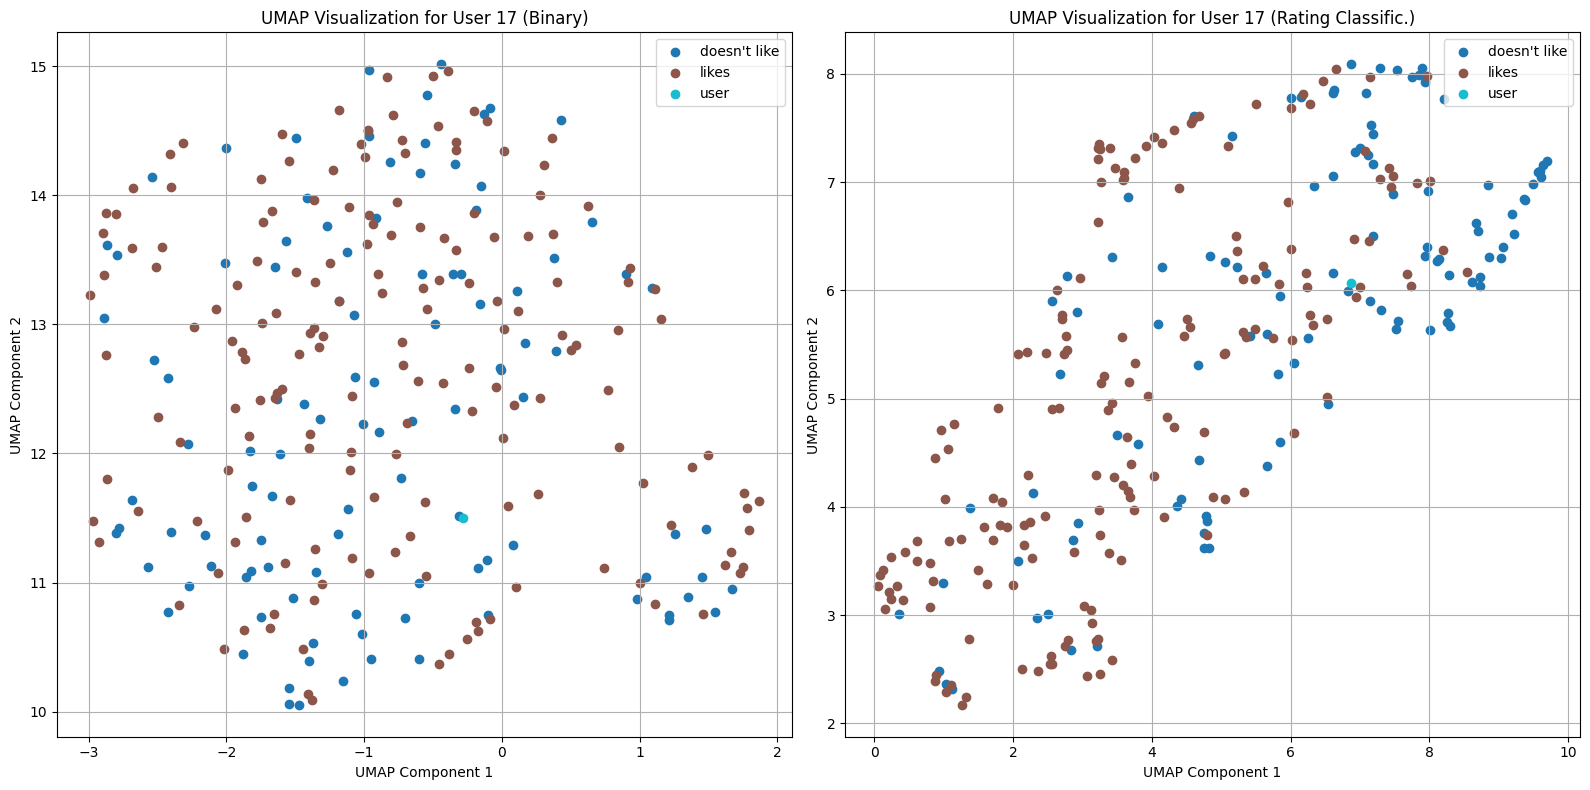

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


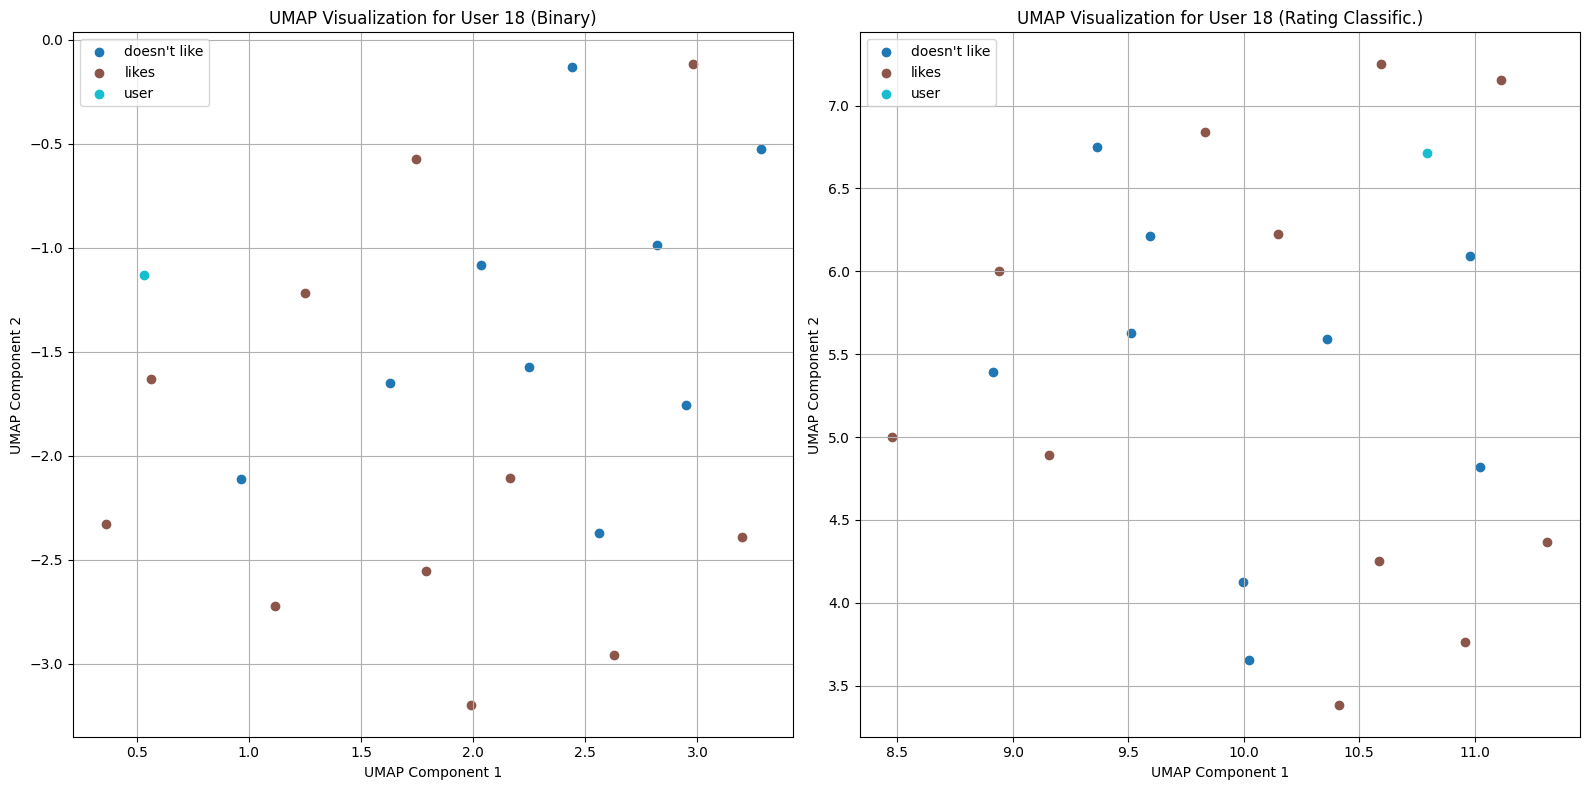

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


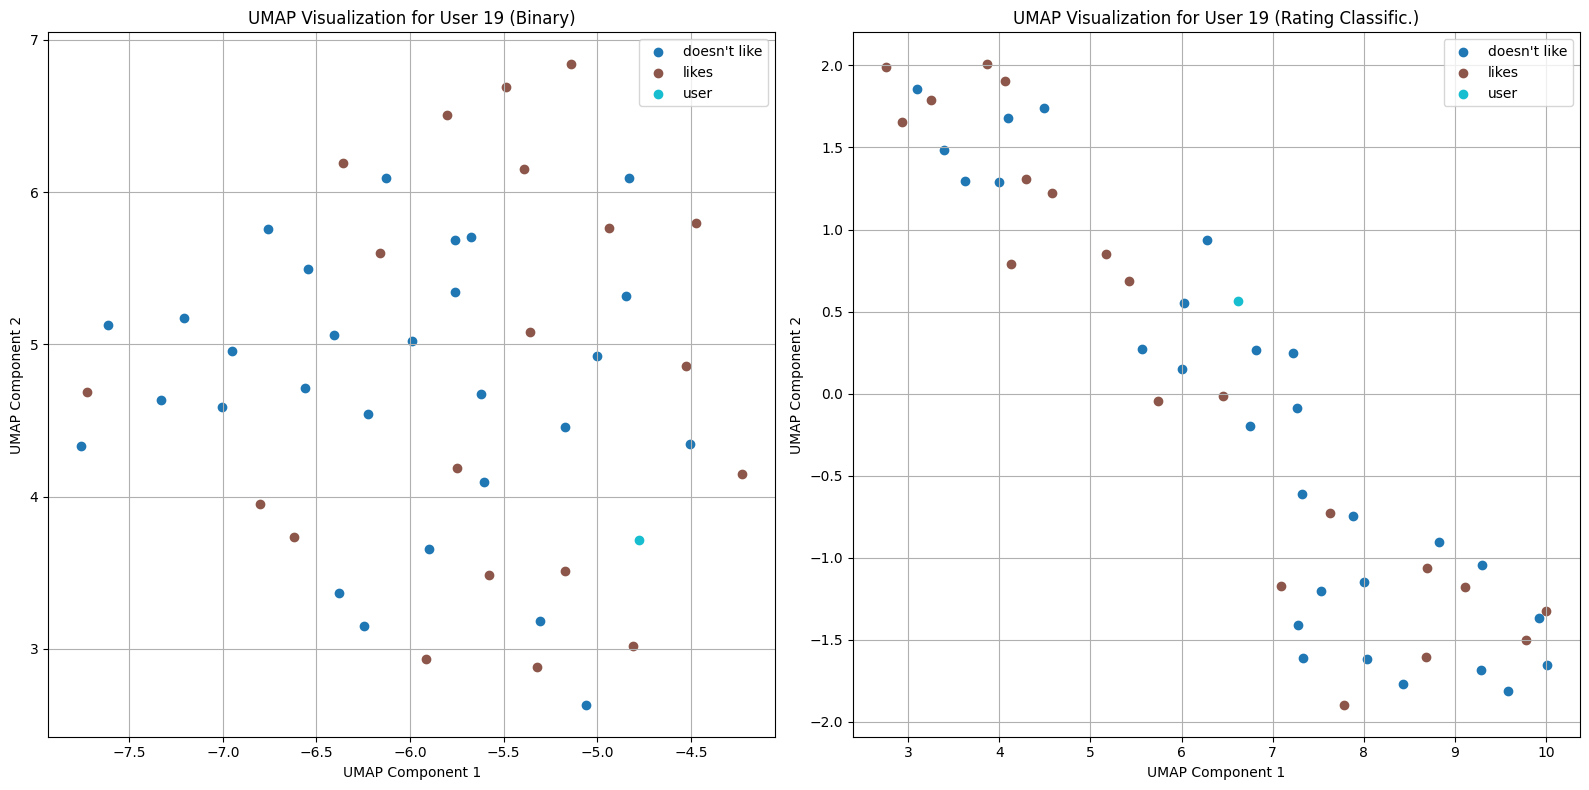

In [58]:
for i in range(20):
    visualize_user_movie_embeddings(i, llm_embedding, movie_embedding, llm_embedding_rating, movie_embedding_rating, aggregated_df)

# The same but after FC1

In [59]:
user_embeds_fc1 = torch.load('user_embeds_fc1.pt')
movie_embeds_fc1 = torch.load('movie_embeds_fc1.pt')
user_embeds_rating_fc1 = torch.load('user_embeds_rating_fc1.pt')
movie_embeds_rating_fc1 = torch.load('movie_embeds_rating_fc1.pt')

/var/folders/jd/4hblgkwx24zg166lcr8sj2200000gn/T/ipykernel_85254/3952170309.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  user_embeds_fc1 = torch.load('user_embeds_fc1

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


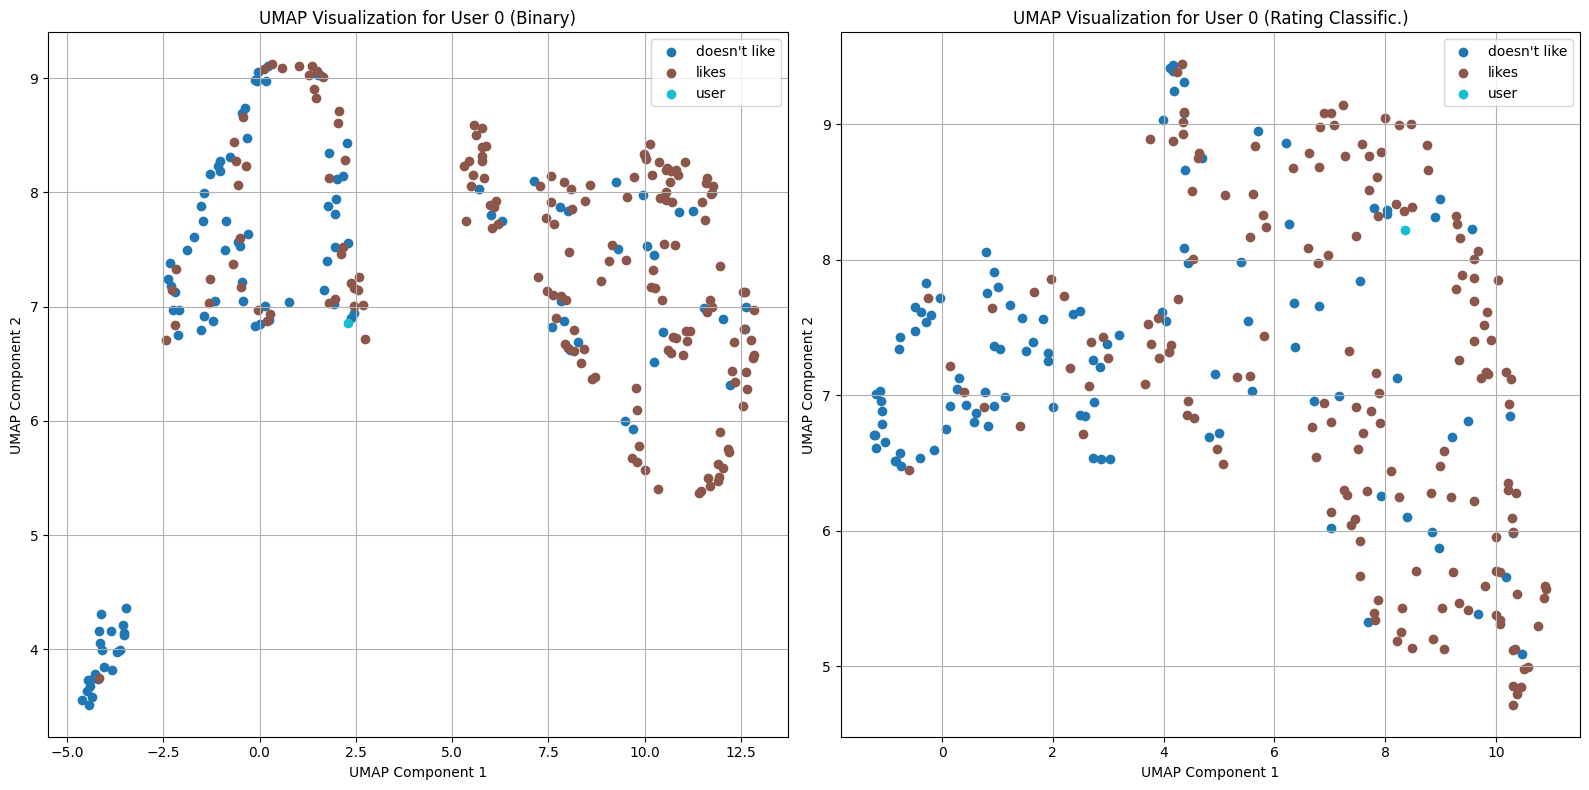

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


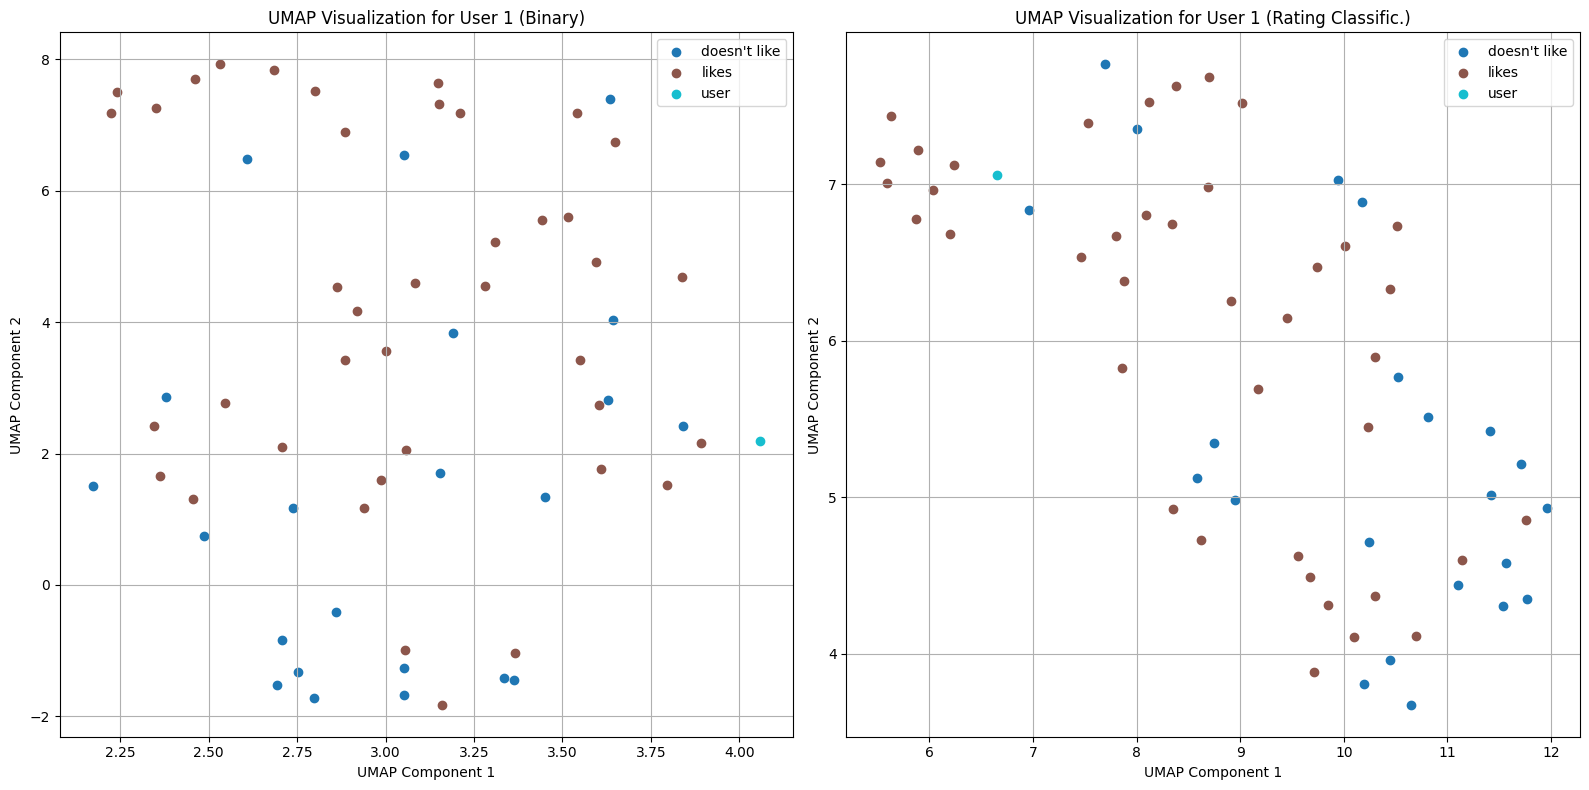

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


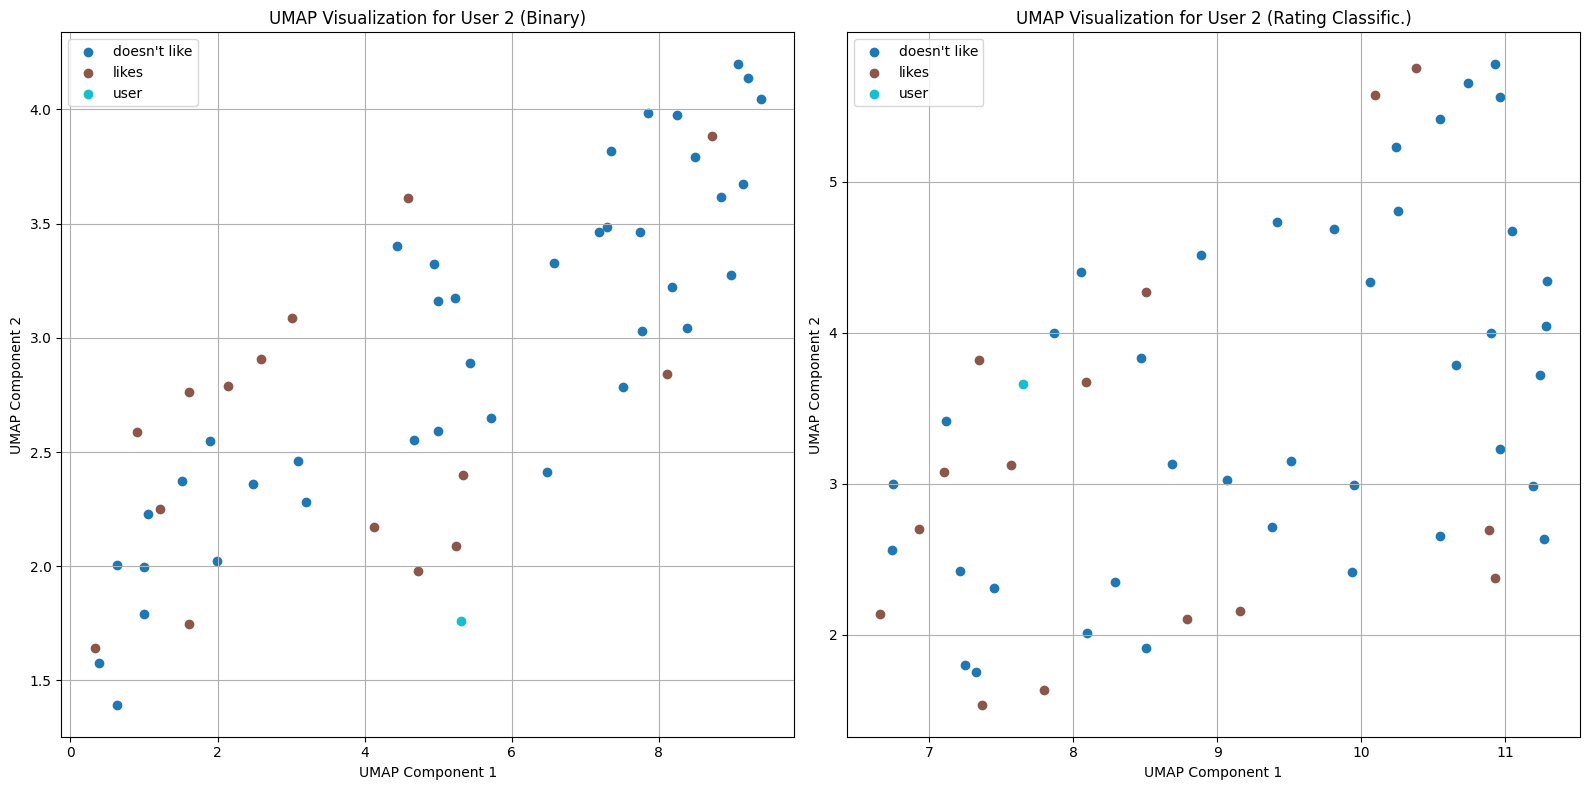

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


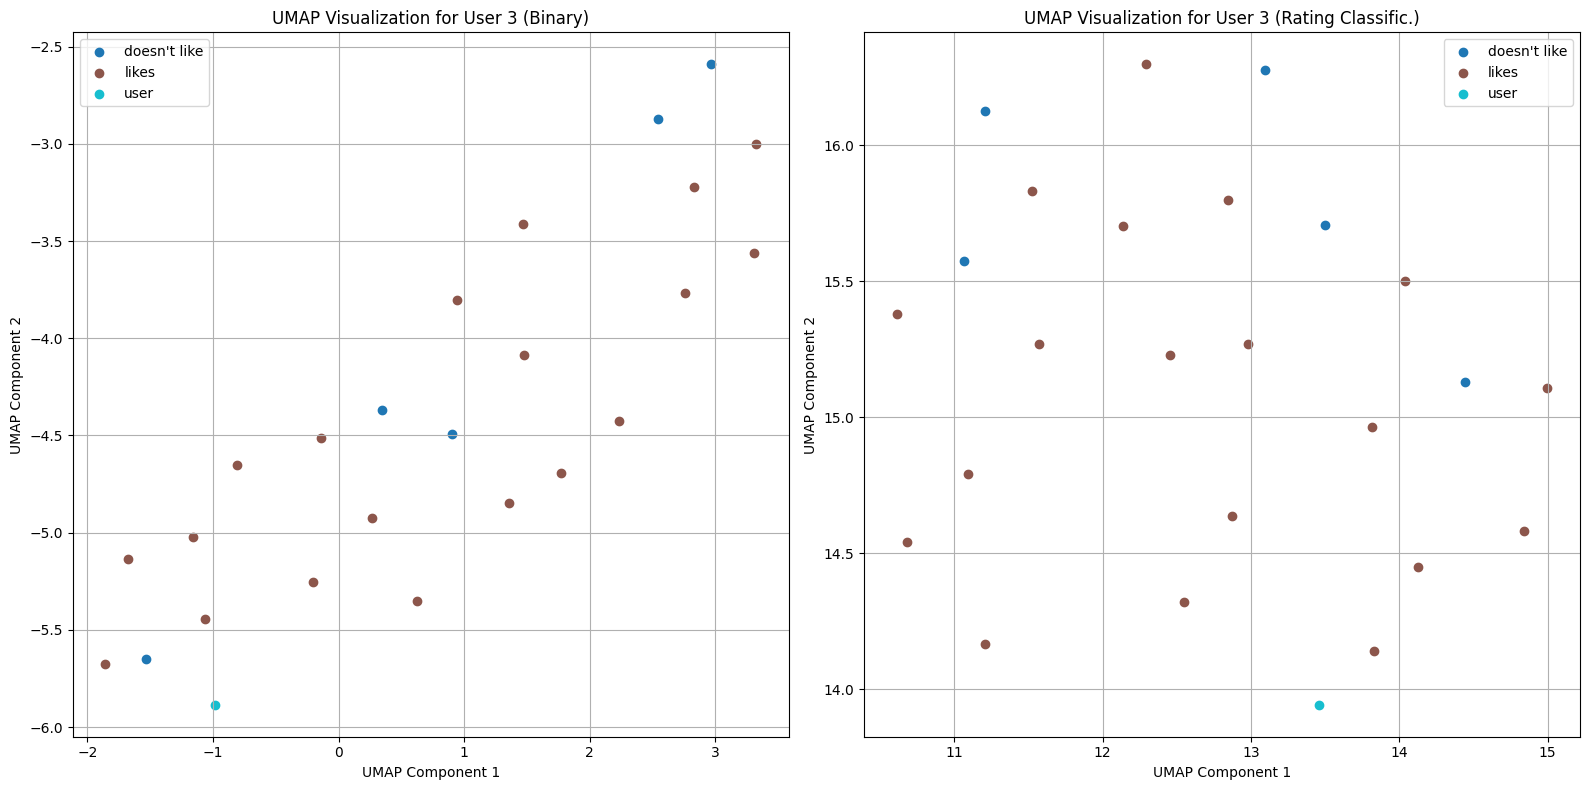

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


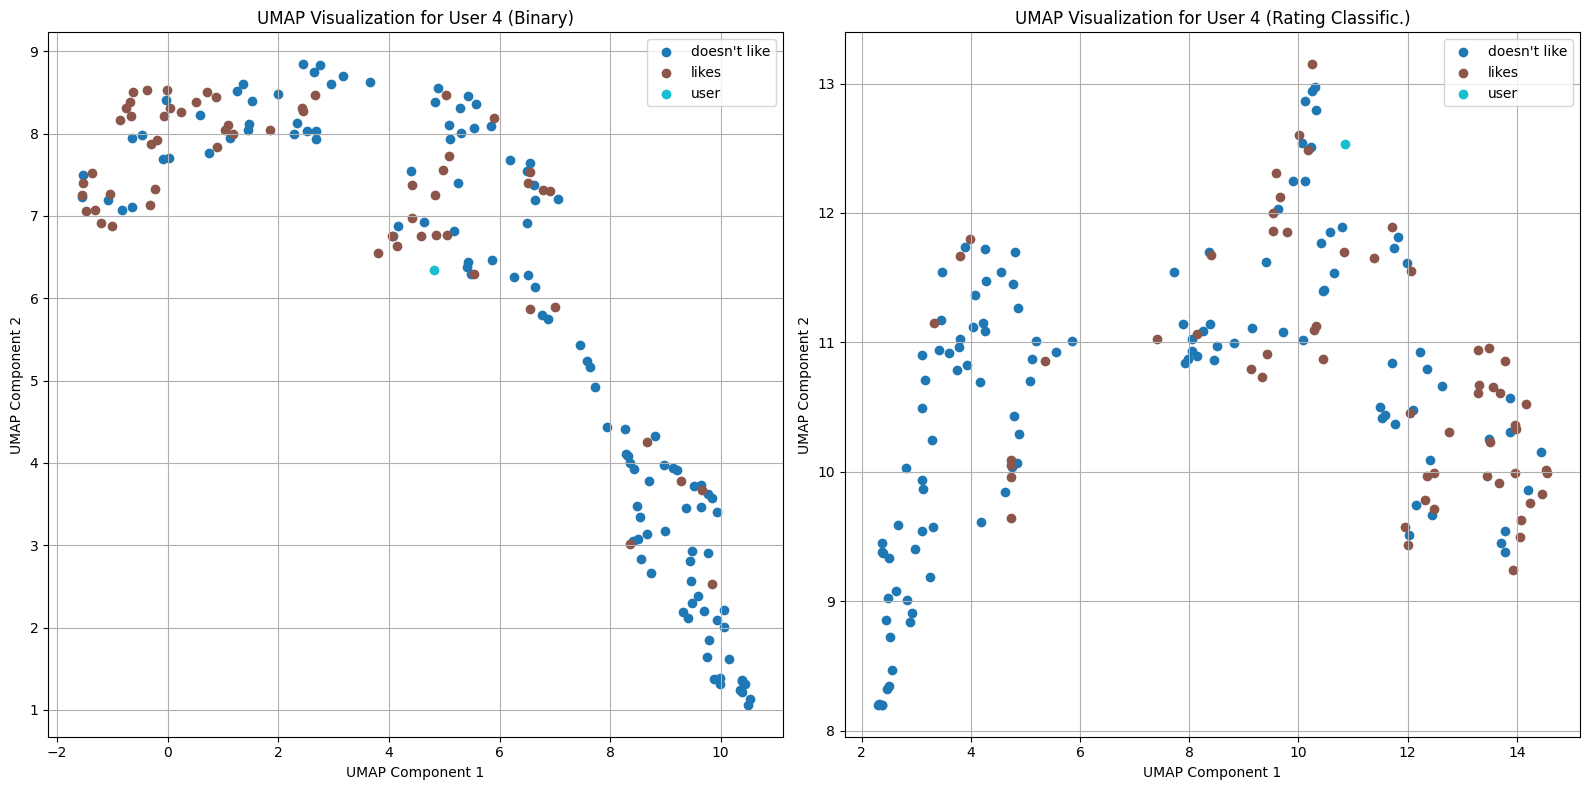

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


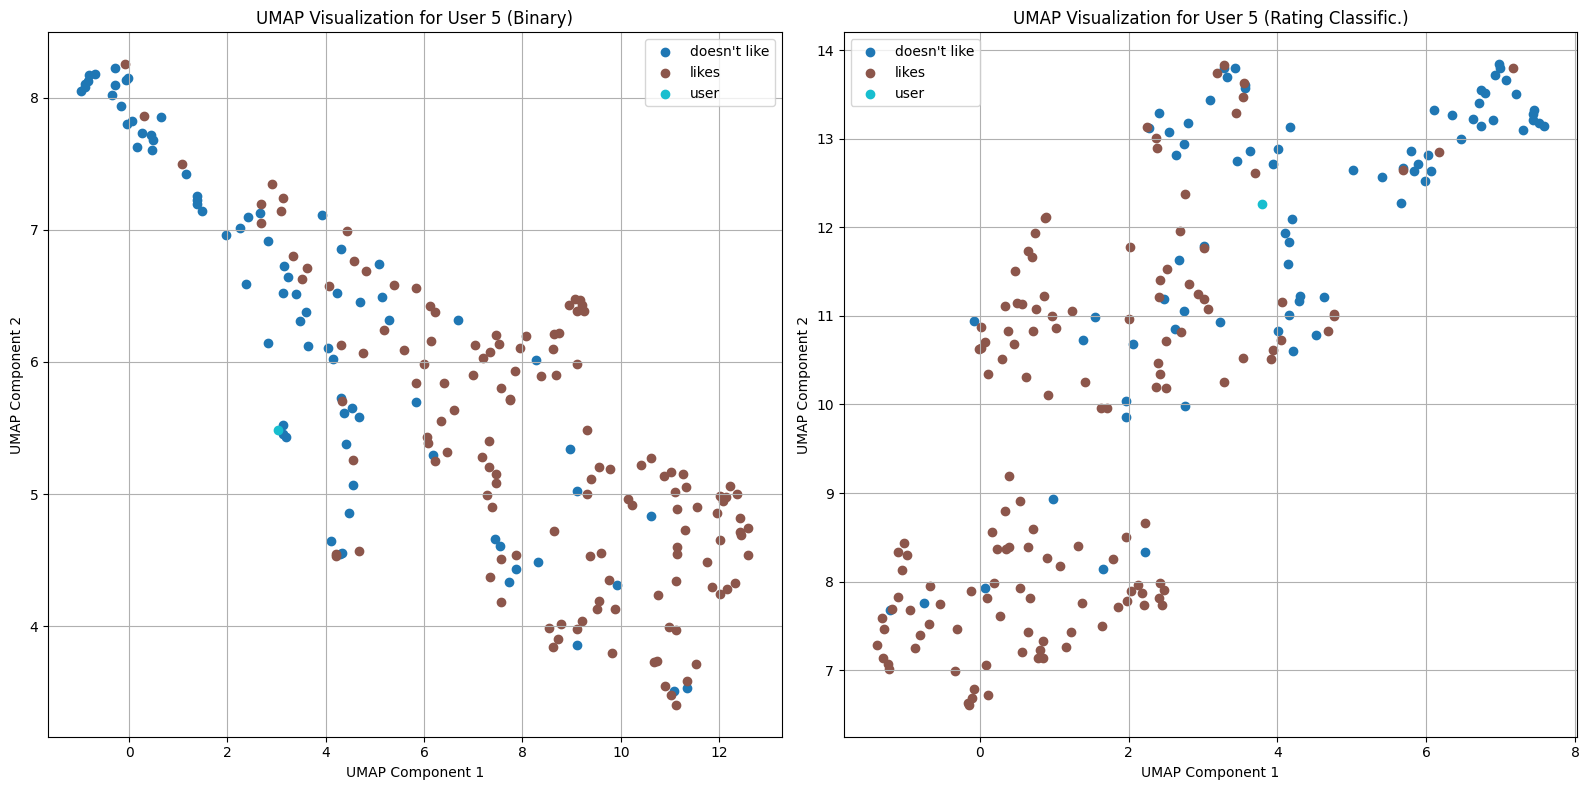

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


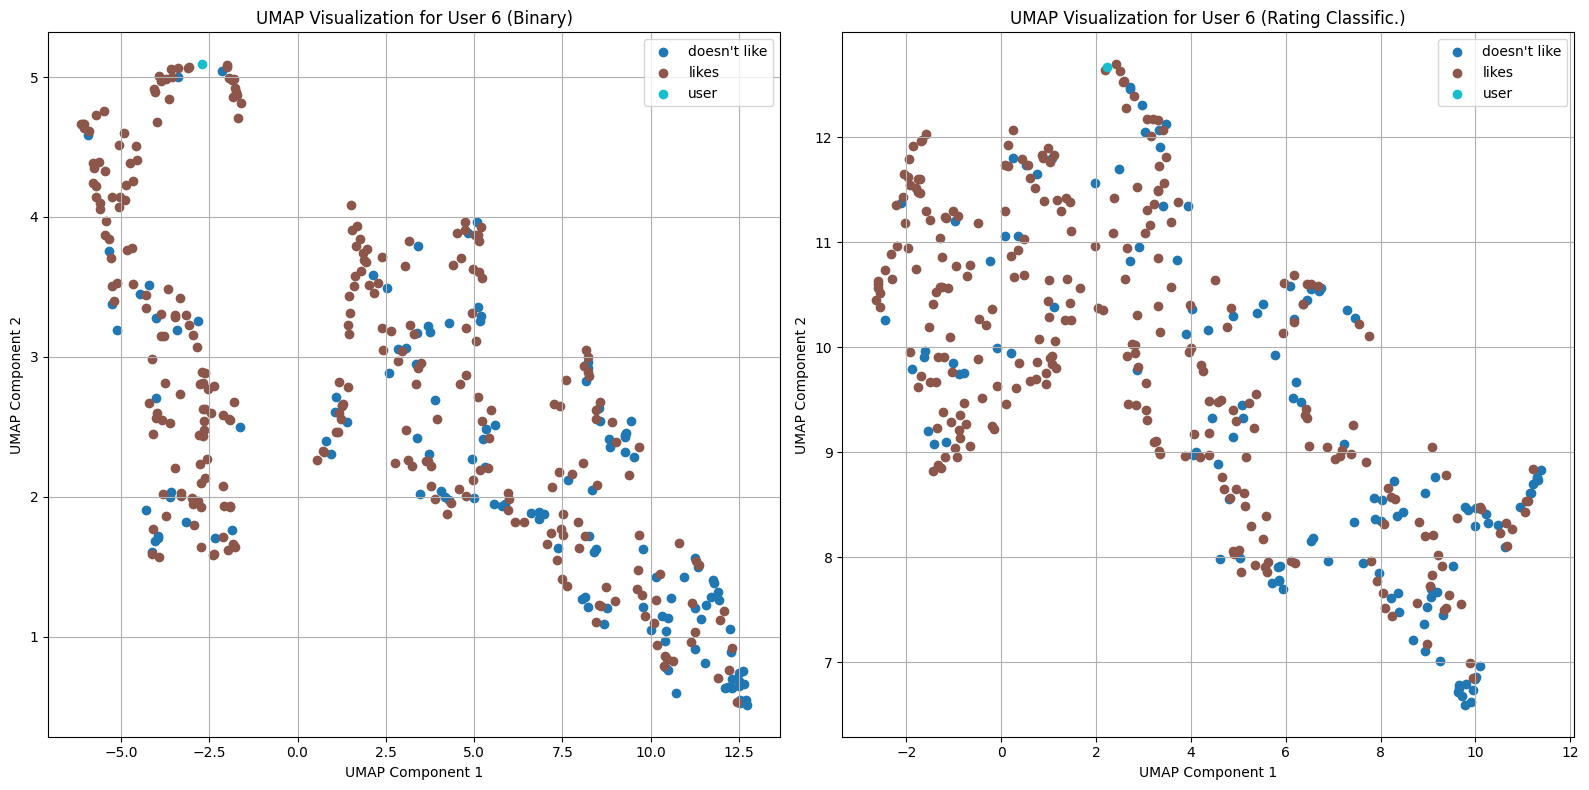

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


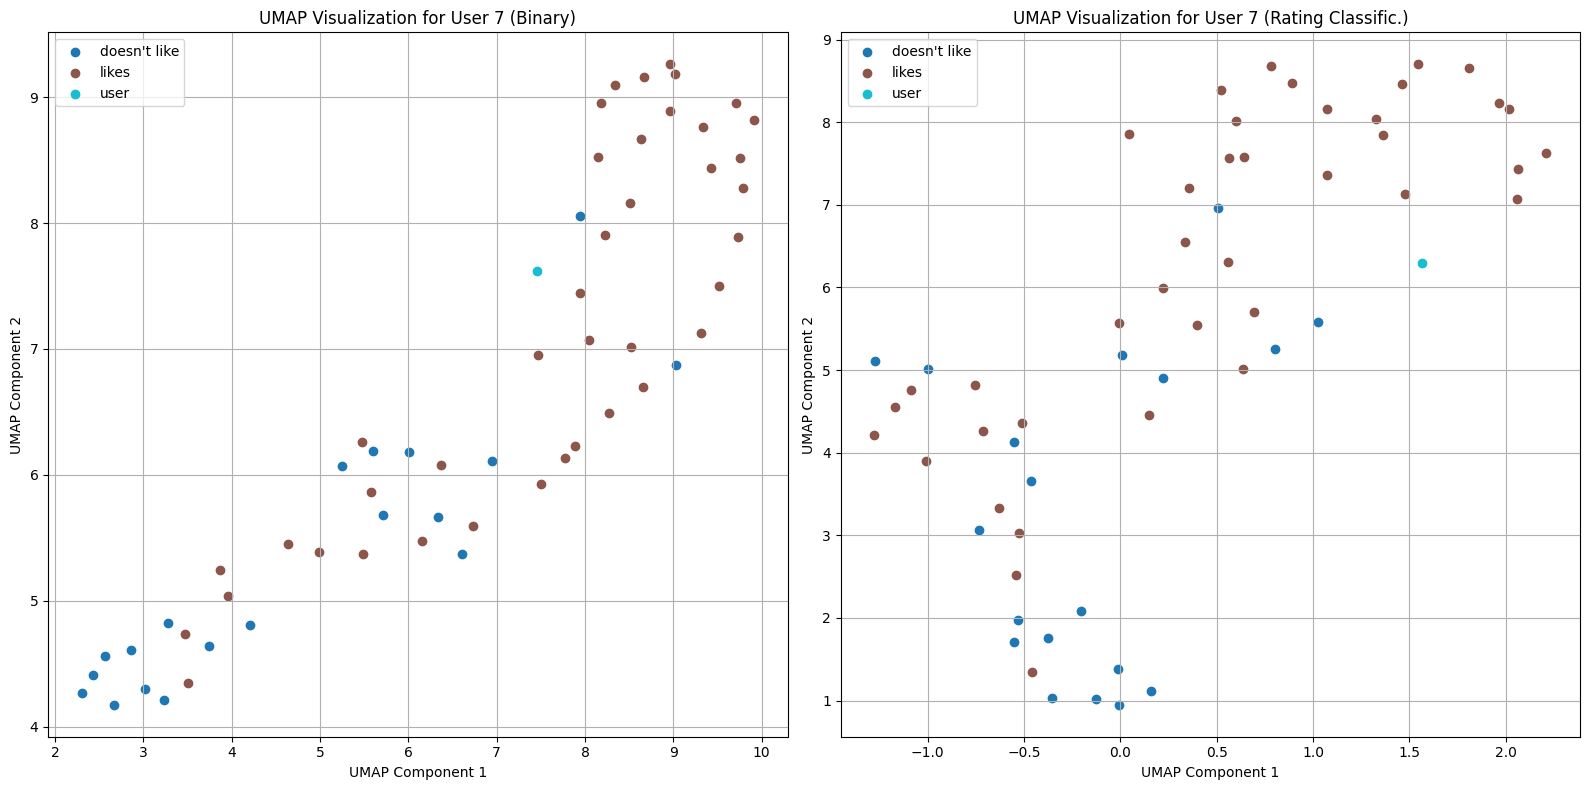

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


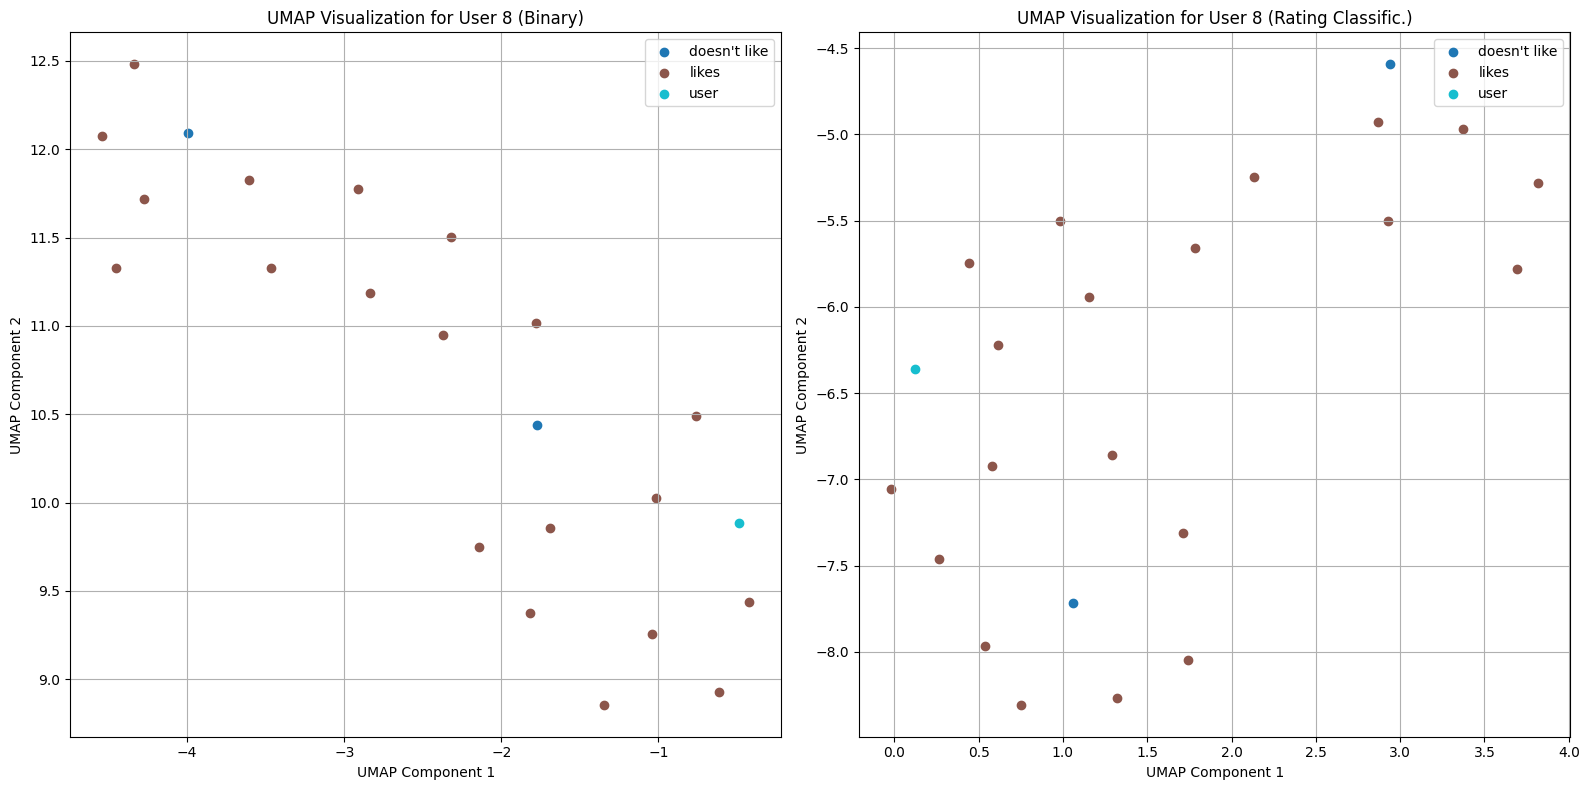

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


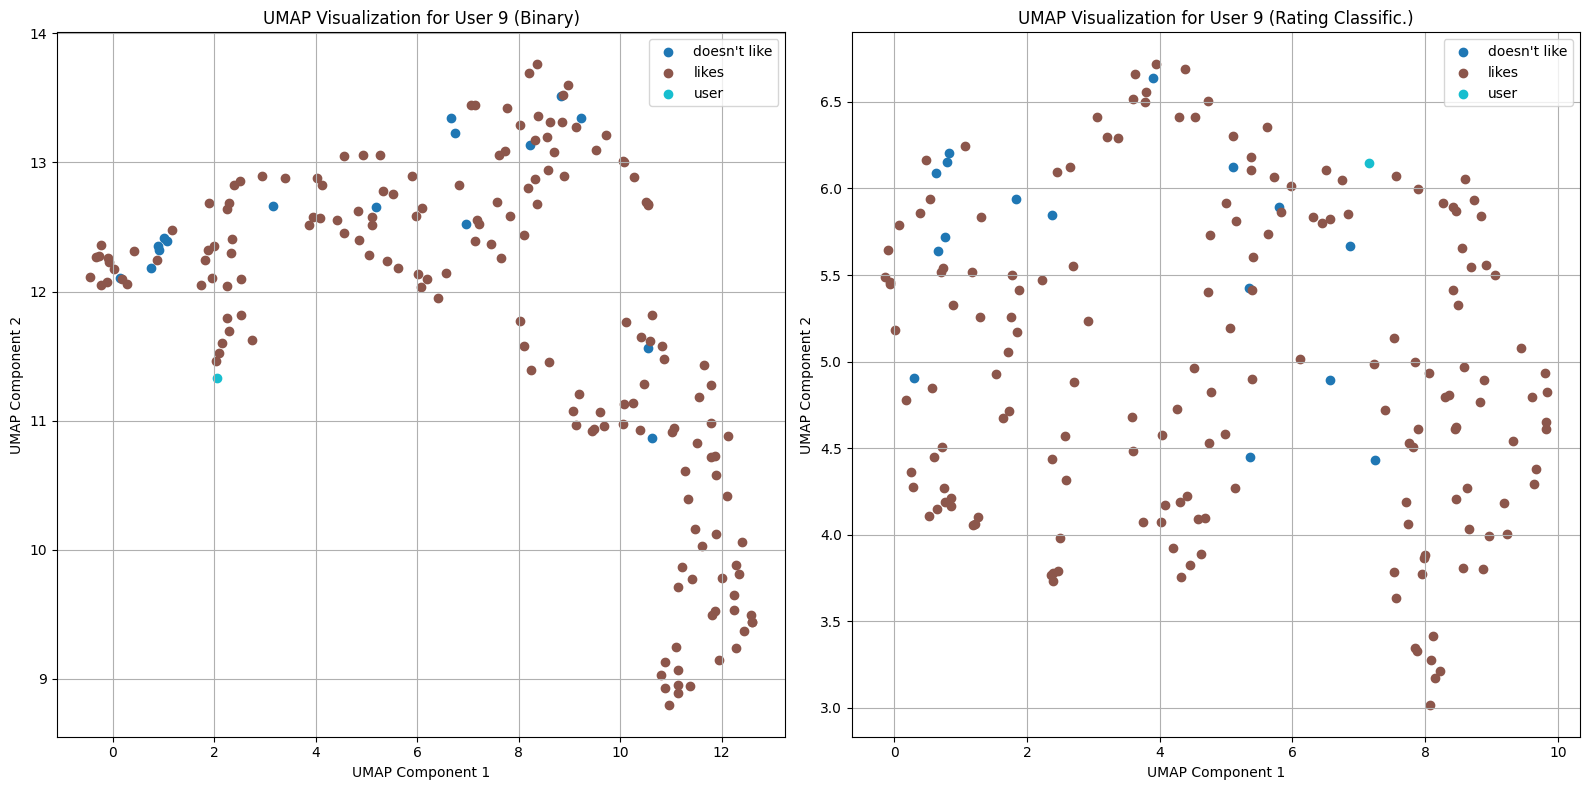

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


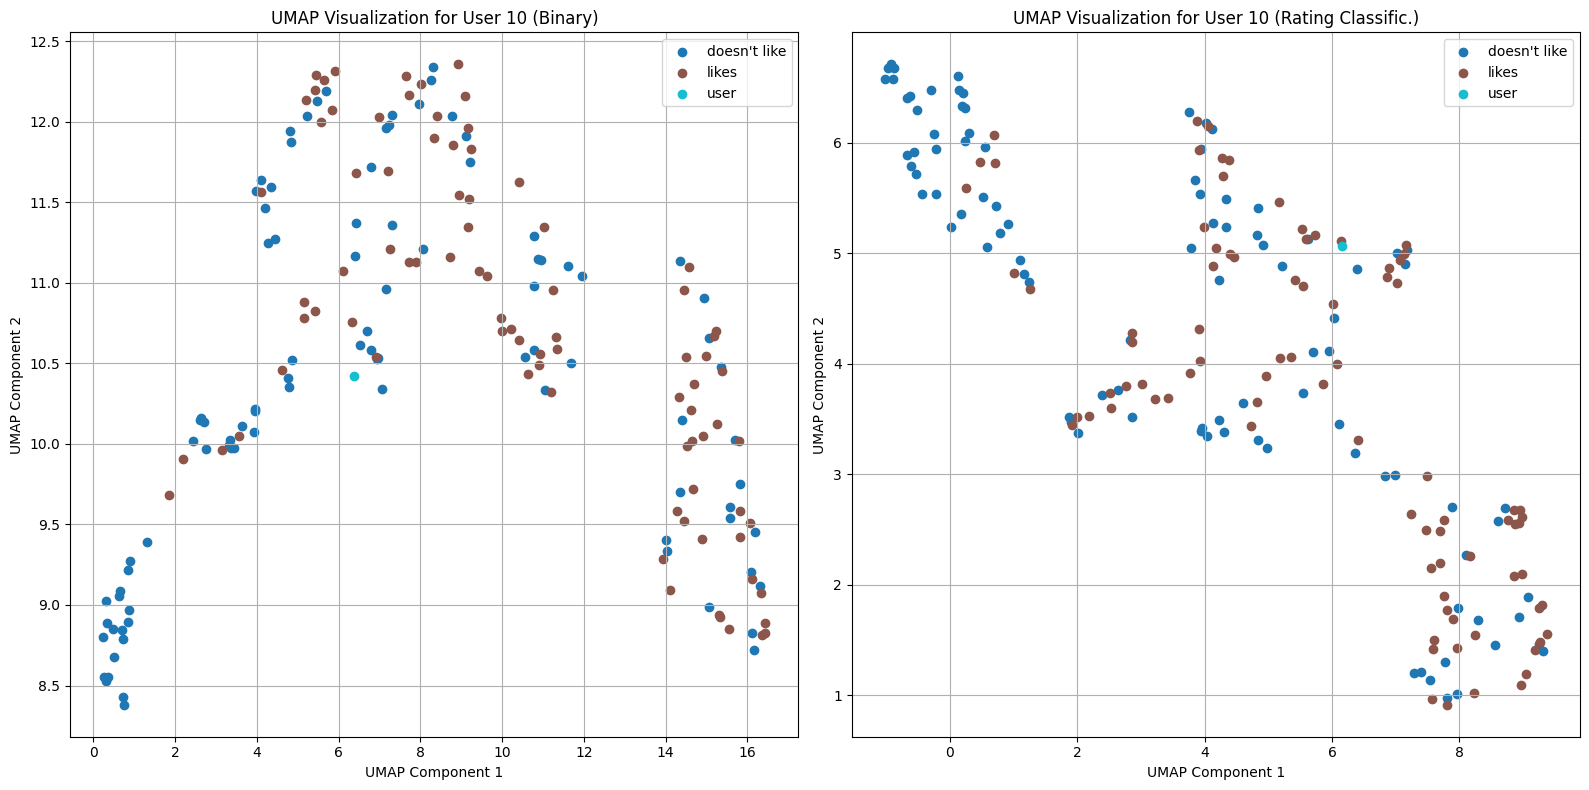

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


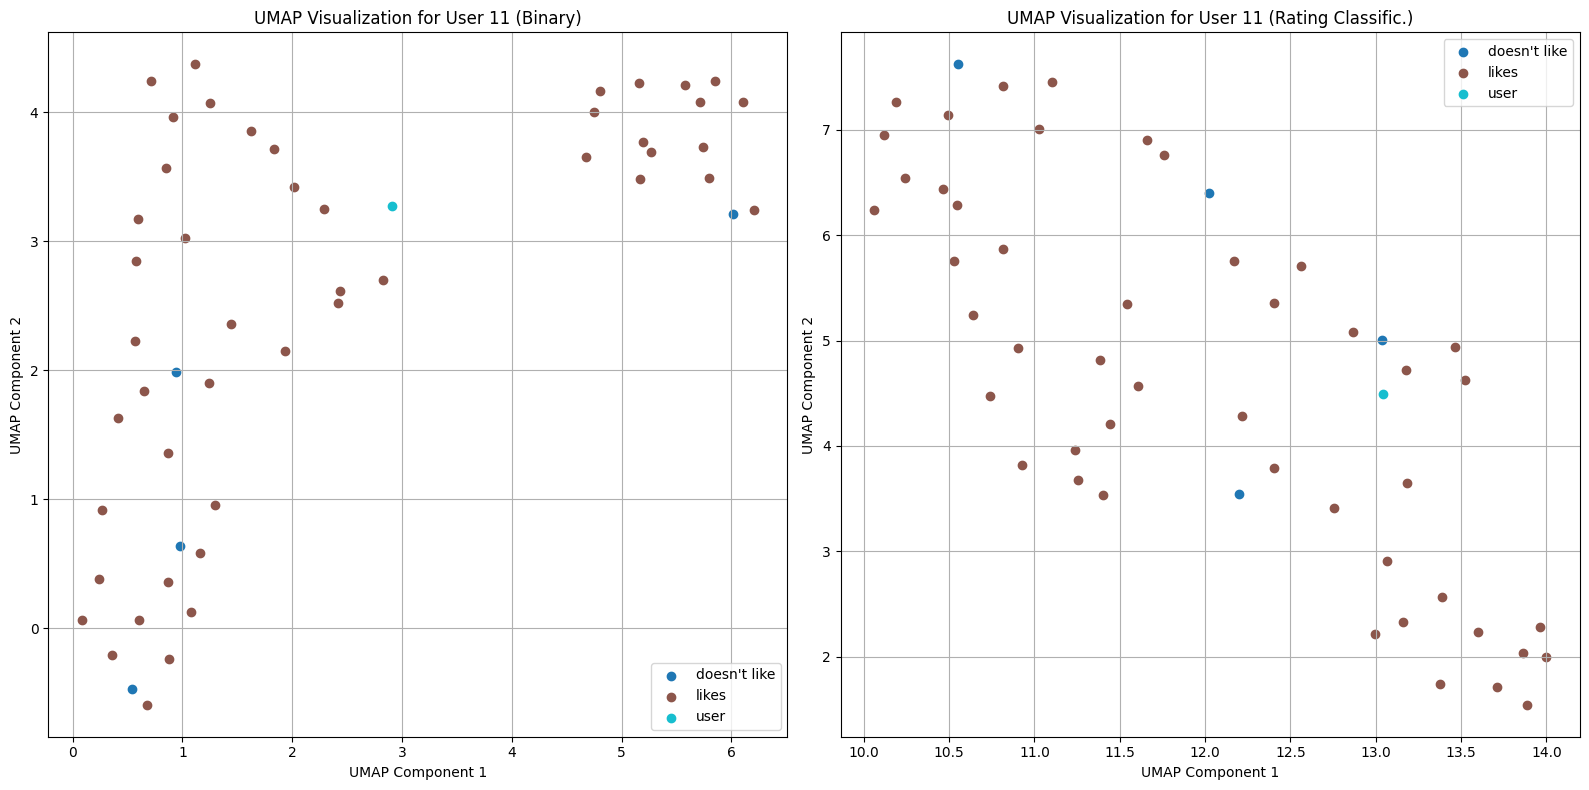

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


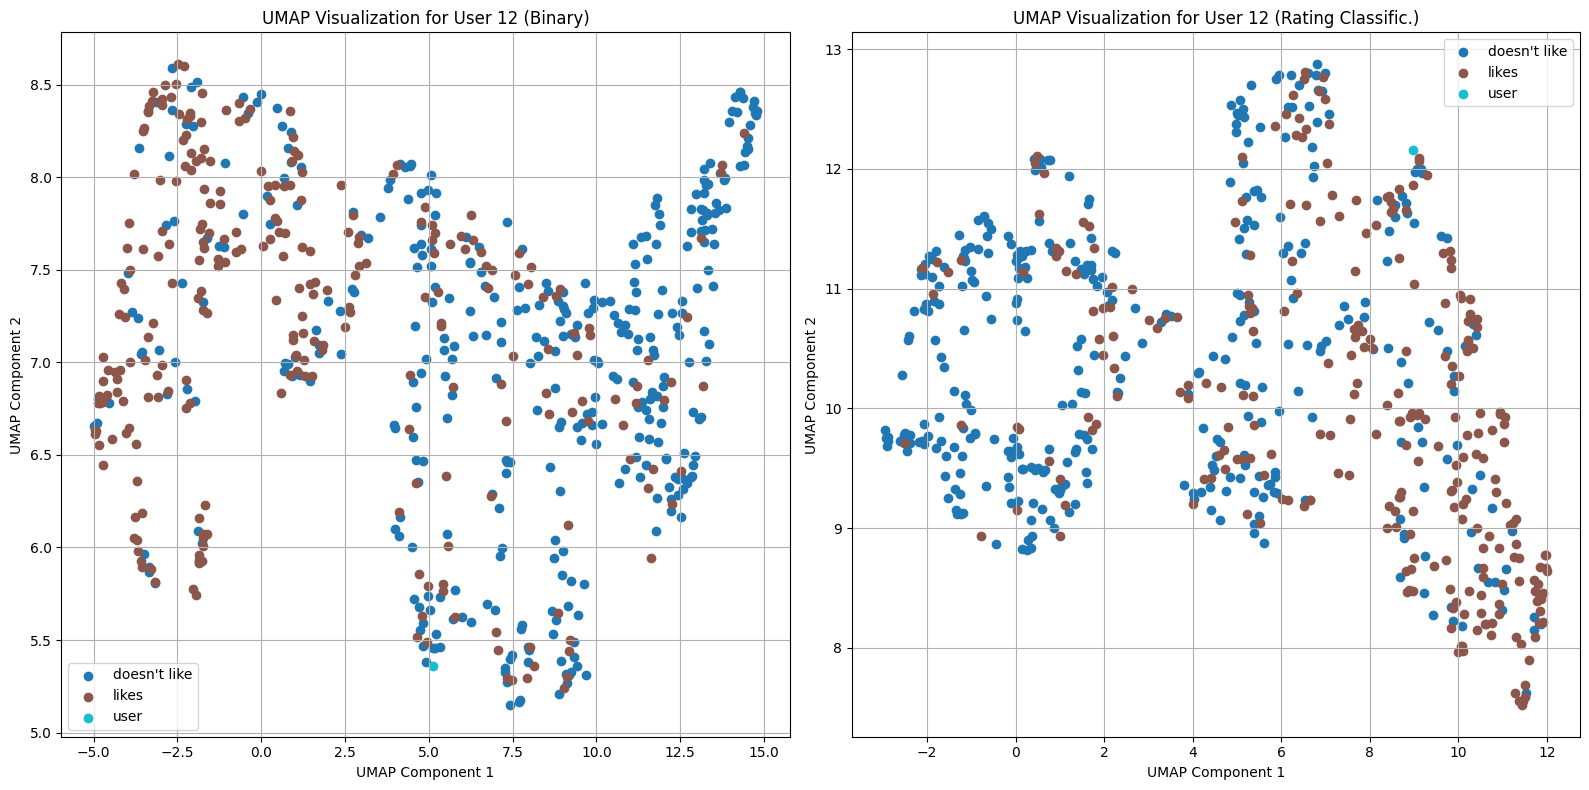

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


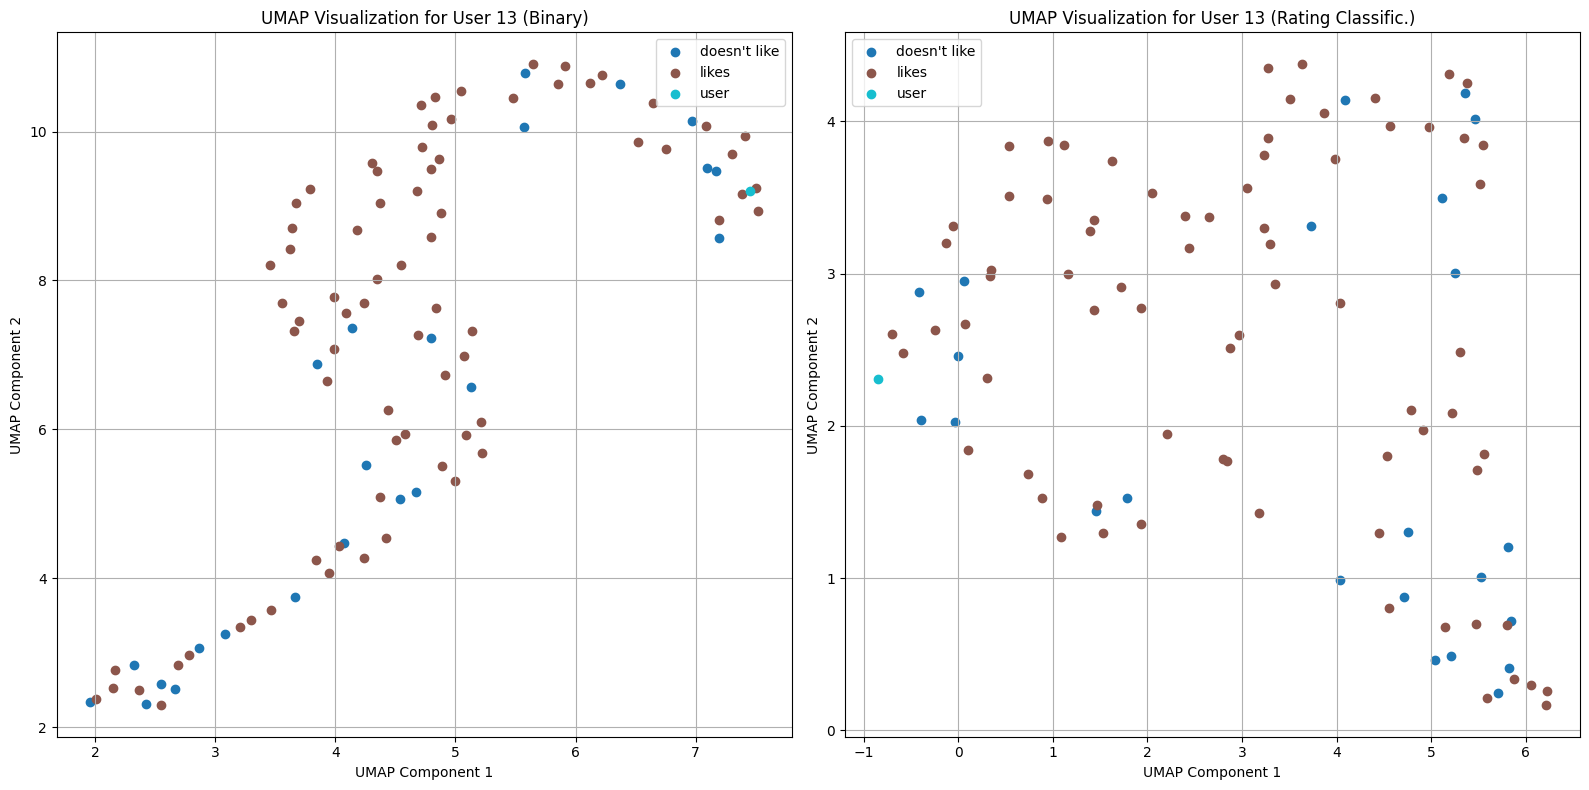

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


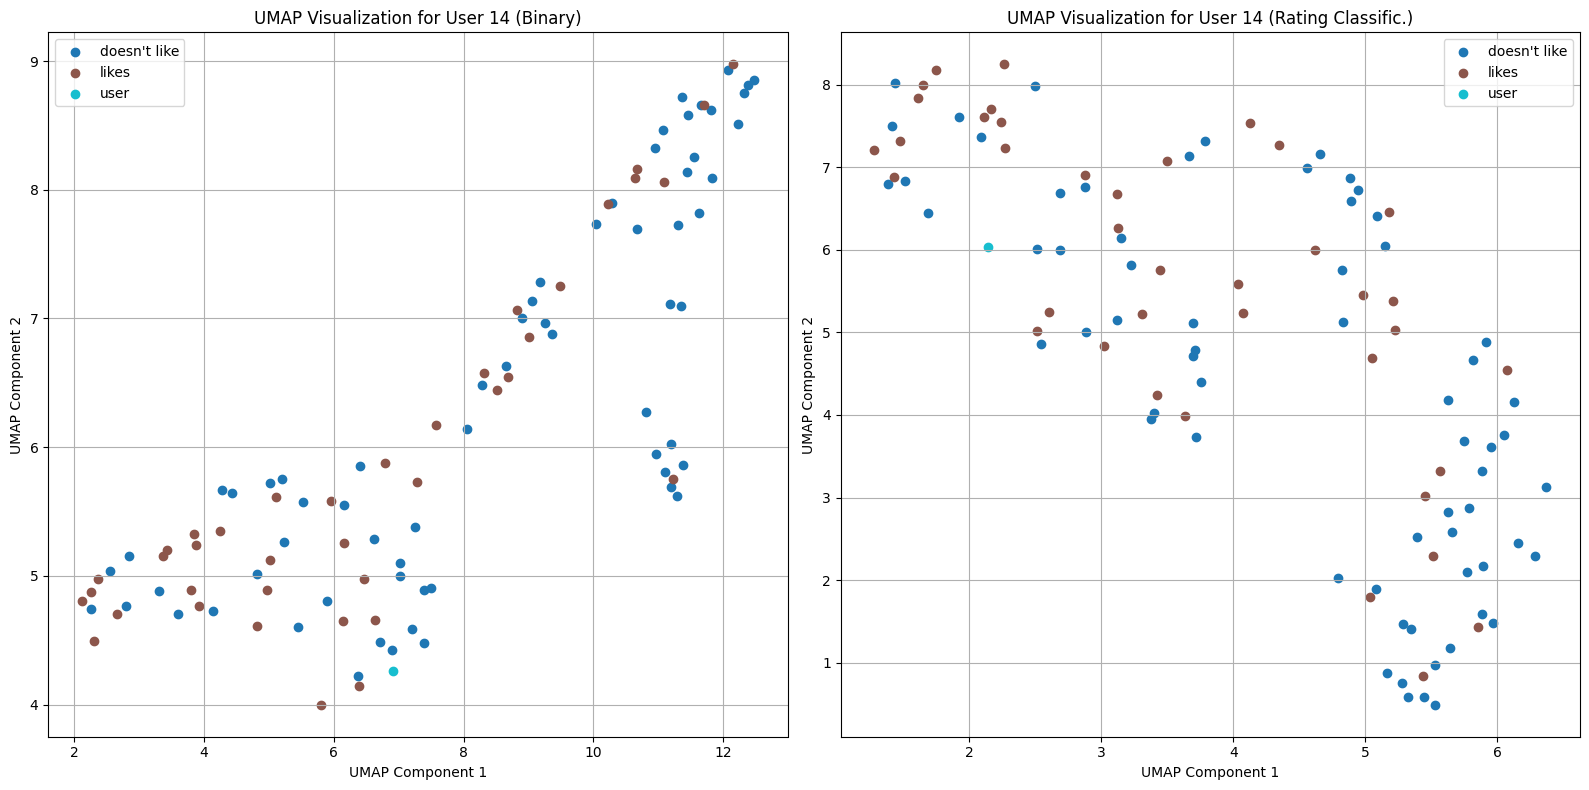

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


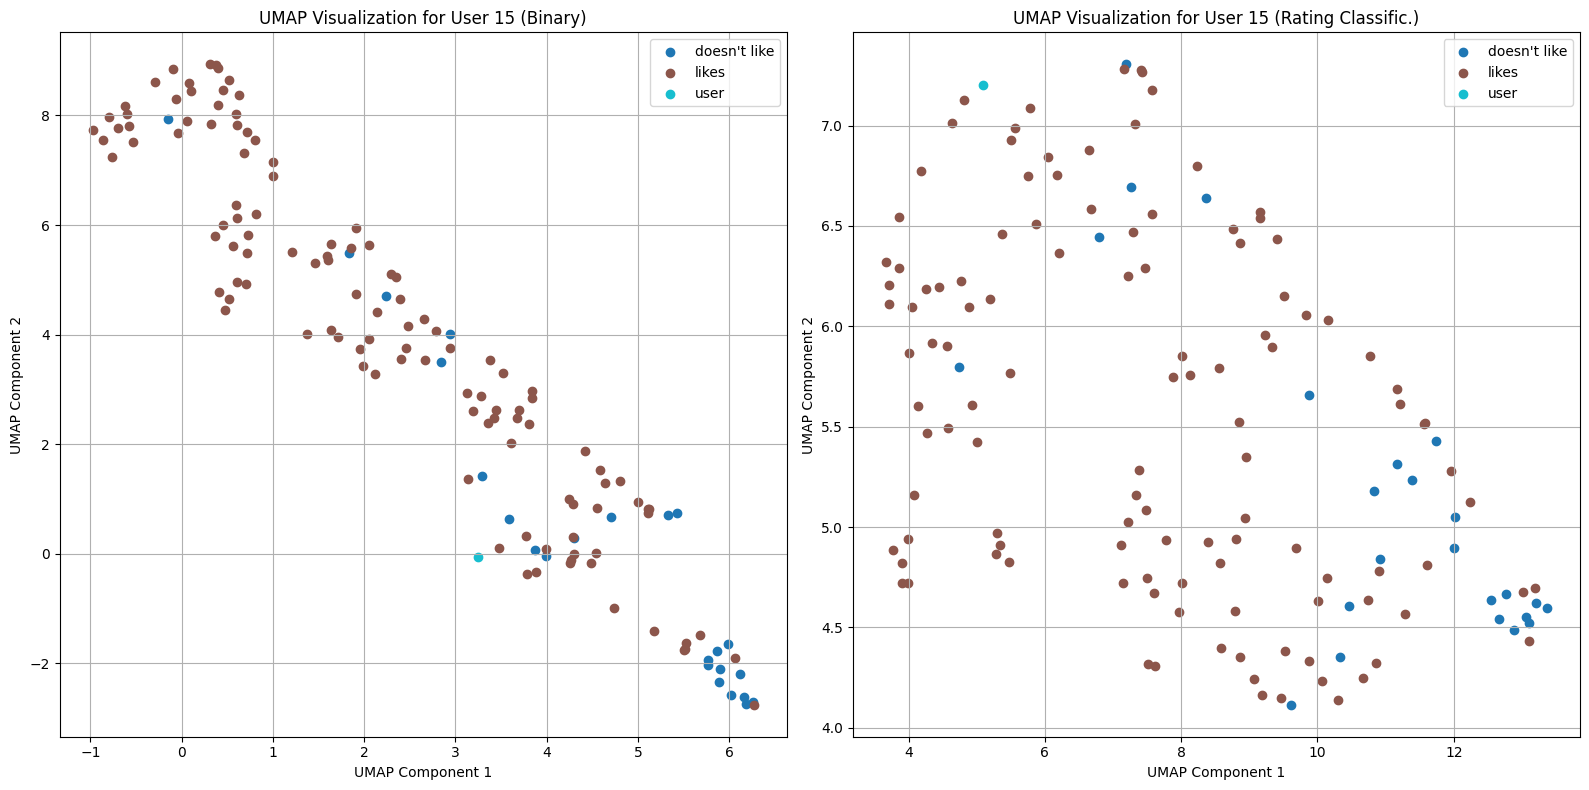

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


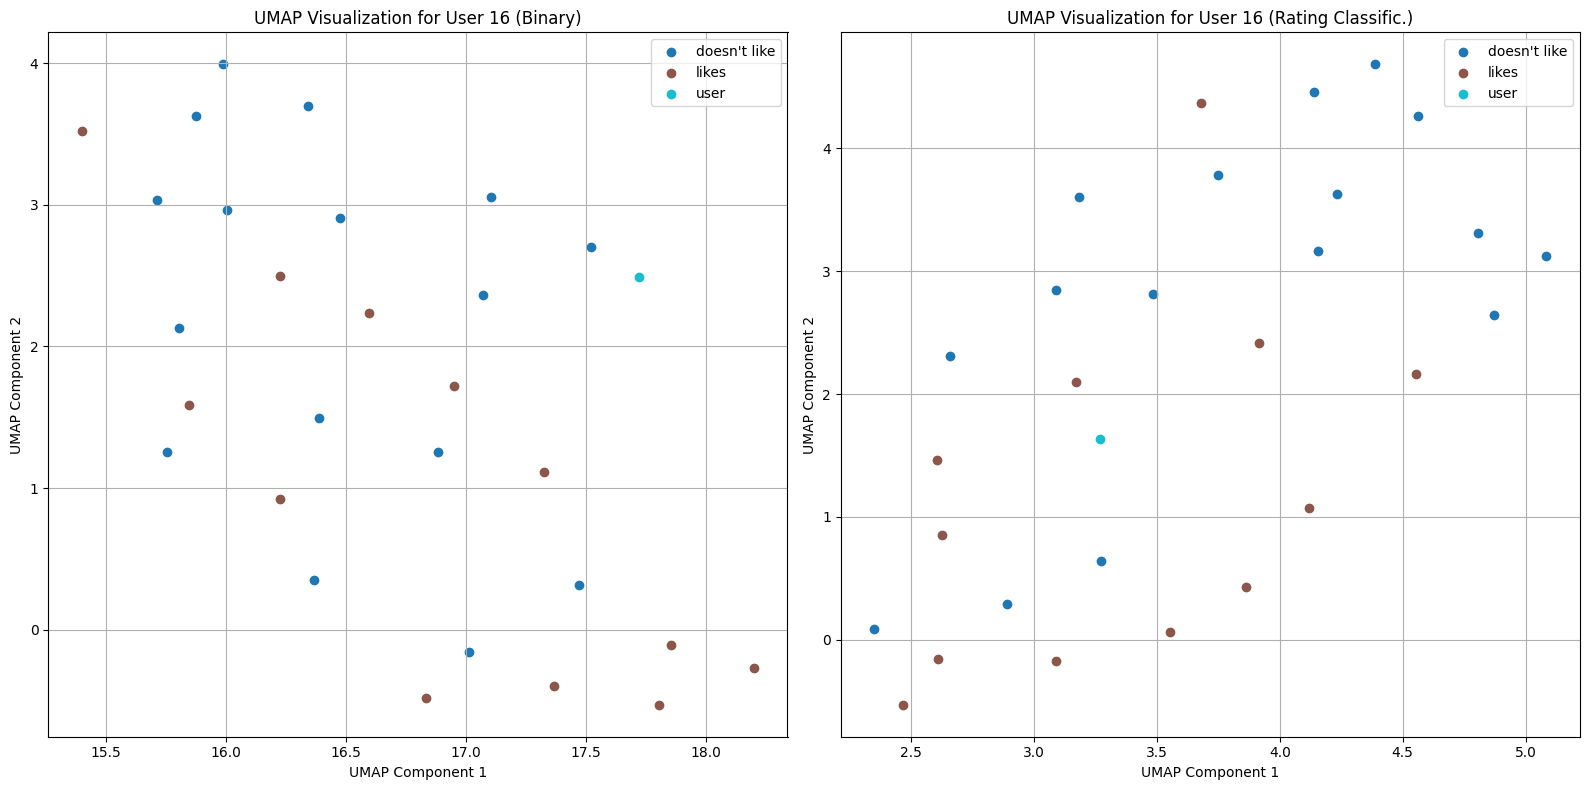

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


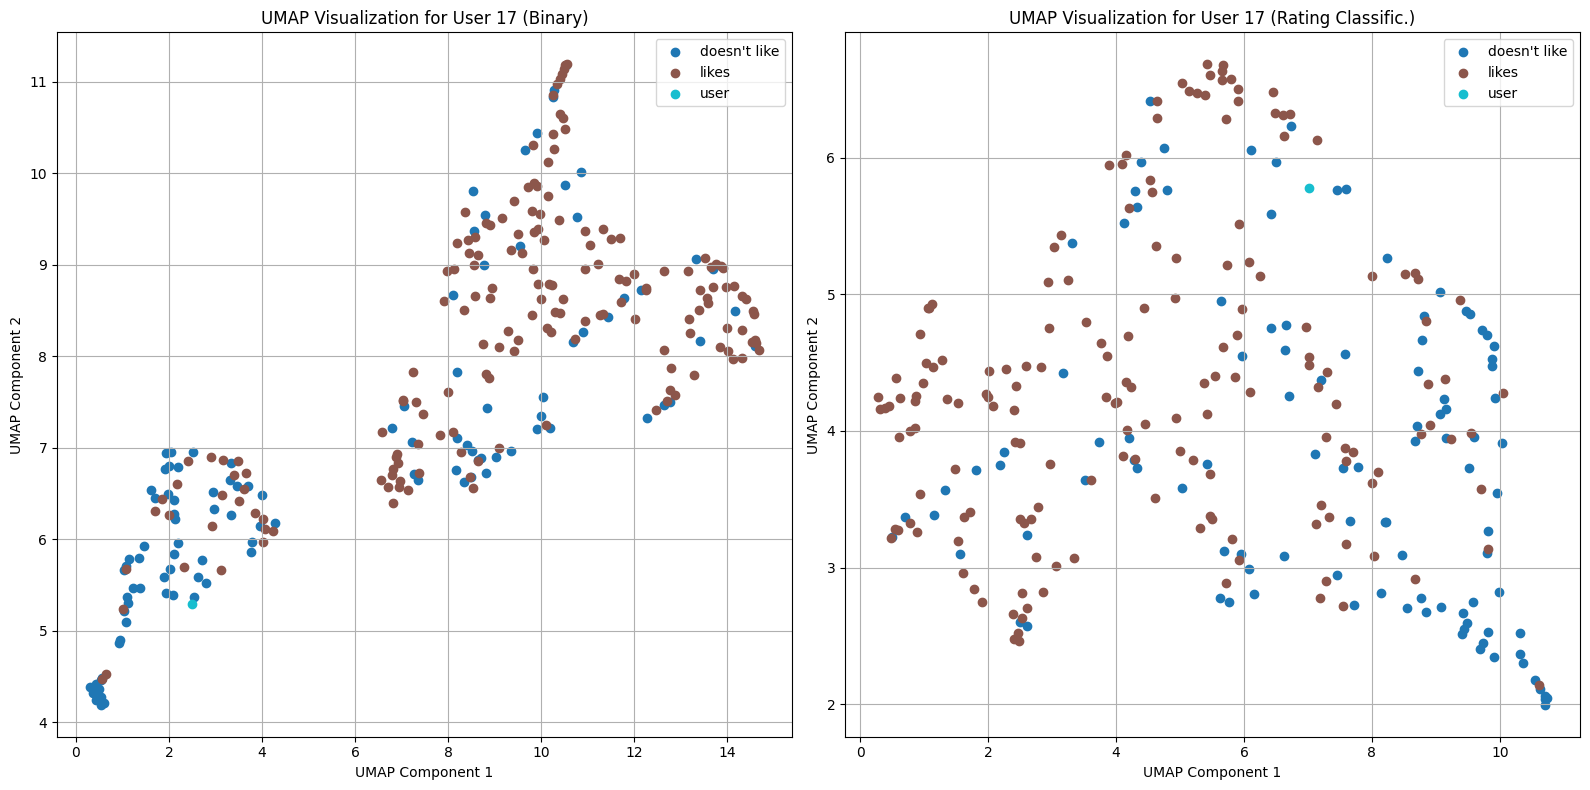

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


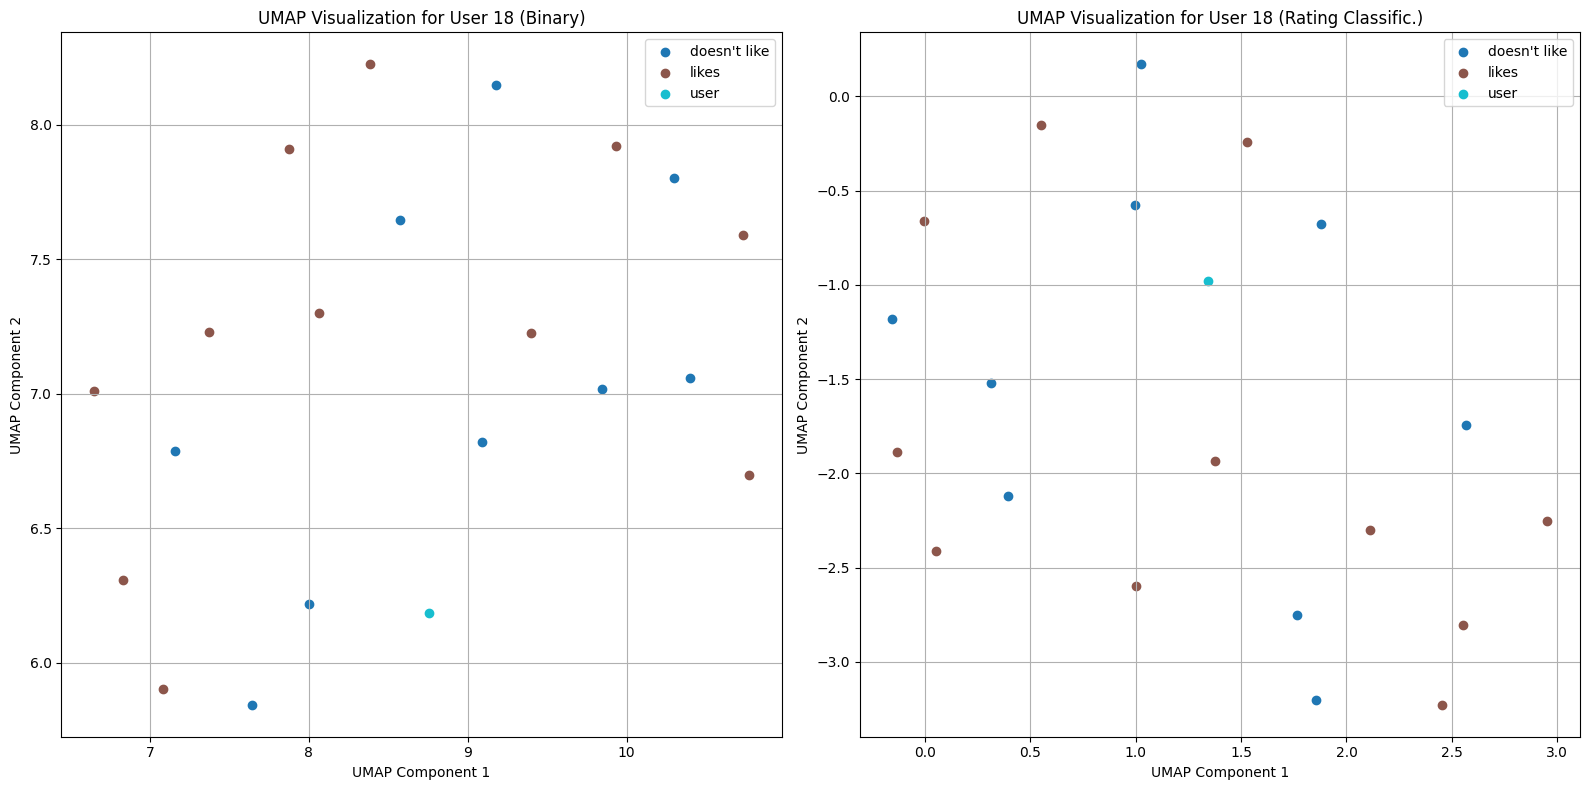

/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/sebastian/miniforge3/envs/kg-token/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


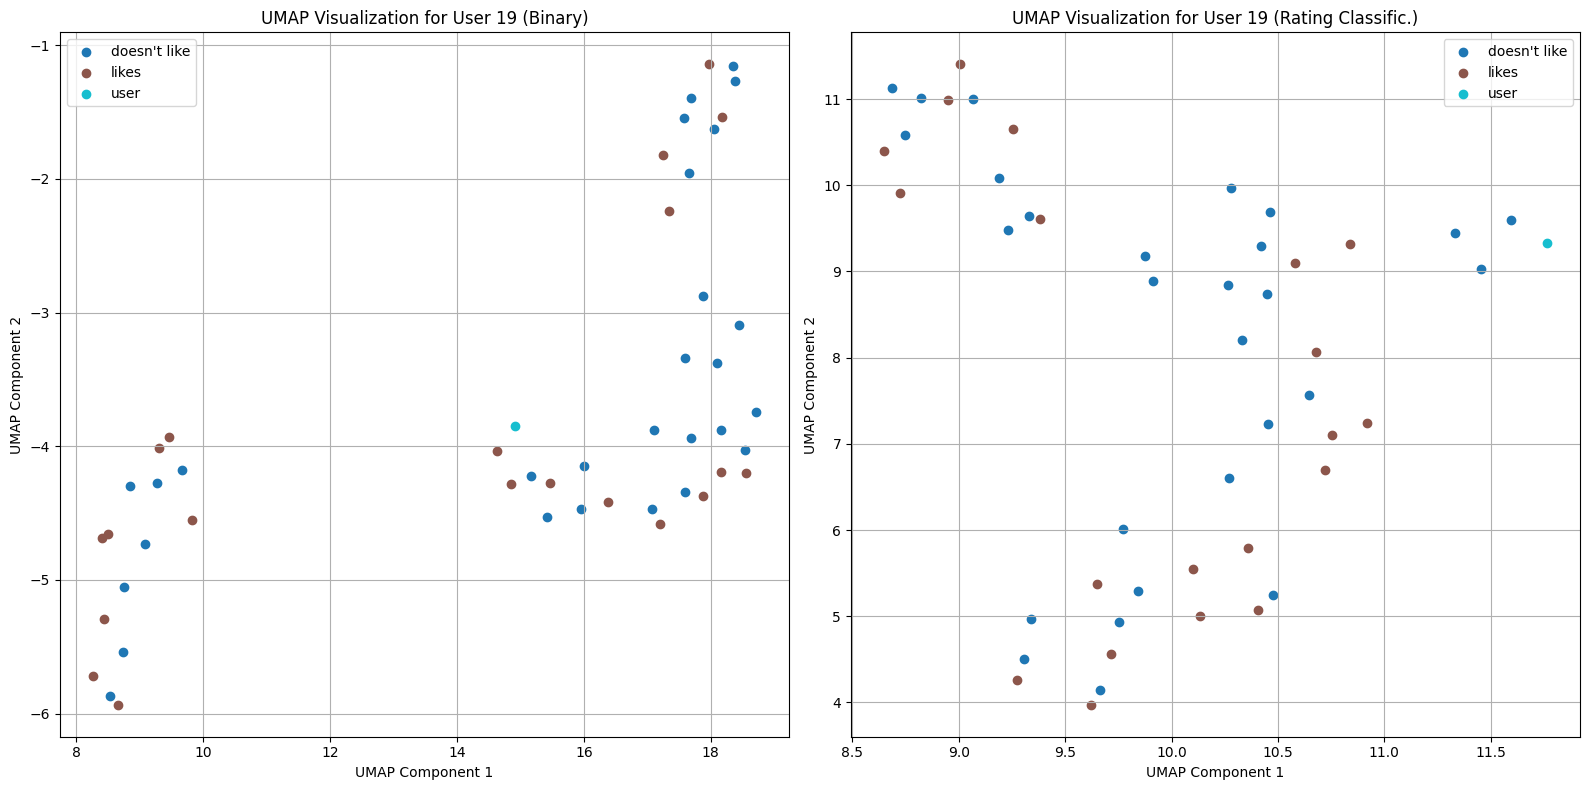

In [60]:
for i in range(20):
    visualize_user_movie_embeddings(i, user_embeds_fc1, movie_embeds_fc1, user_embeds_rating_fc1, movie_embeds_rating_fc1, aggregated_df)